In [1]:
from datetime import datetime
baslangic = datetime.now()

# Does Turkish News Media Sentiment Influence the Educated Urban Online Community?
## A Bidirectional Time-Series Analysis Using Ekşi Sözlük as an Intentional Sample


---

### Research Question

> *"Does Turkish news media sentiment influence the sentiment of Turkey's educated, urban, digitally-engaged community — as proxied by Ekşi Sözlük — and does this community's collective voice, in turn, influence subsequent news media tone?"*

### Ekşi Sözlük — Purposive Sample

Targets adults aged 25–40, university-educated, urban-resident, politically engaged. Its slower reaction cadence (hours vs. social media's minutes) produces cleaner lag signals in the VAR framework.

| Section | Content |
|---|---|
| **0** | Data Collection — RSS News + Ekşi Sözlük |
| **1** | Setup & Data Preparation |
| **2** | Algorithms — Naive, SARIMA, ETS, Prophet + RF, XGBoost |
| **3** | Evaluation Metrics & Back Testing (3 windows, test set locked) |
| **4** | Best Model Selection |
| **5** | Train on Full Data & Final Validation |
| **6** | 30-Day Future Forecast with P10 / P50 / P90 |
| **VAR** | VAR + Granger Causality (causal track) |


In [2]:
# ── 0.0 Global imports ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os, time, random, logging

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates  as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

# ── Statistical / lecture models ─────────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters        import ExponentialSmoothing
from statsmodels.tsa.stattools          import adfuller, grangercausalitytests, ccf
from statsmodels.graphics.tsaplots      import plot_acf, plot_pacf
from statsmodels.tsa.api                import VAR

try:
    from prophet import Prophet
    logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
    logging.getLogger('prophet').setLevel(logging.WARNING)
    PROPHET_OK = True
except ImportError:
    PROPHET_OK = False
    print('Prophet not installed. Install with: pip install prophet')

# ── ML models ─────────────────────────────────────────────────────────────────
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model    import LinearRegression
from sklearn.preprocessing   import StandardScaler, MinMaxScaler
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    XGB_OK = False

# ── Purple-theme colour palette (matches template) ────────────────────────────
PURPLE   = '#9333ea'
PURPLE_D = '#581c87'
PURPLE_L = '#e9d5ff'
SLATE    = '#334155'
ACCENT   = '#c084fc'
TEAL     = '#2d6a4f'
ORANGE   = '#f4a261'
RED      = '#e63946'
BLUE     = '#457b9d'
GOLD     = '#e9c46a'
LIME     = '#2ecc71'

MODEL_COLORS = ['#581c87','#6b21a8','#7e22ce','#9333ea','#a855f7','#c084fc','#f0abfc']
MODEL_NAMES  = ['Naive','SARIMA','ETS','Prophet','RF','XGBoost']

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'#f8fafc',
    'axes.edgecolor':'#e2e8f0', 'axes.grid':True,
    'grid.color':'#e2e8f0', 'grid.linestyle':'--', 'grid.alpha':0.7,
    'font.family':'DejaVu Sans', 'axes.titlesize':13,
    'axes.titleweight':'bold', 'axes.titlecolor':'#581c87',
    'axes.labelcolor':'#334155', 'axes.labelsize':11,
    'xtick.color':'#334155', 'ytick.color':'#334155',
    'legend.framealpha':0.9, 'legend.edgecolor':'#e2e8f0',
    'axes.spines.top':False, 'axes.spines.right':False,
})
sns.set_palette([PURPLE, ORANGE, TEAL, RED, BLUE, GOLD, ACCENT])

SEED = 42
np.random.seed(SEED)
os.makedirs('data', exist_ok=True)
print('Libraries loaded and purple theme applied.')
print(f'Prophet available : {PROPHET_OK}')
print(f'XGBoost available : {XGB_OK}')




Libraries loaded and purple theme applied.
Prophet available : True
XGBoost available : True


---
## Section 0 — Data Collection

Run once; all downstream sections load from saved CSVs.

| Sub-section | Output file |
|---|---|
| 0.1 | Shared helpers and constants |
| 0.2 | Google News RSS + outlet RSS → `data/raw_news.csv` |
| 0.3 | Ekşi Sözlük scraper → `data/raw_eksisozluk.csv` |
| 0.5 | Sentiment scoring → `data/news_with_sentiment.csv`, `data/eksisozluk_with_sentiment.csv` |
| 0.6 | Aggregation → `data/ts_daily.csv`, `data/ts_weekly.csv` |
| 0.7 | Quality report & dataset decision |

### Topic Keywords

| Topic | Keywords |
|---|---|
| economy | enflasyon, döviz, faiz, ekonomi, borsa, dolar, bütçe, büyüme, işsizlik, zam, merkez bankası, bütçe açığı, ihracat, borsa istanbul, kredi, tüfe, üfe, gsyh, maaş, asgari ücret |
| politics | seçim, hükümet, meclis, muhalefet, cumhurbaşkanı, iktidar, anayasa, yargı, belediye, chp, akp, mhp, hdp, milletvekili, bakan, siyaset, referandum, koalisyon, savcılık, mahkeme |
| national | deprem, sel, yangın, terör, güvenlik, asker, şehit, dış politika, göç, nato, suriye, pkk, gazze, ukrayna, savunma, polis, operasyon, sınır, milli takım, afet |


In [3]:
# ── 0.1  Shared helper functions ─────────────────────────────────────
from datetime import date

# ── Date constants ────────
if 'END_DATE' not in dir():
    START_DATE_NEWS = '2024-01-01'
    START_DATE_EKSI = '2024-02-01'
    END_DATE        = date.today().isoformat() #today
    START_DATE      = START_DATE_NEWS

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/124.0.0.0 Safari/537.36'
    )
}

def polite_get(url, delay=(1.2, 2.8), timeout=15):
    time.sleep(random.uniform(*delay))
    try:
        r = requests.get(url, headers=HEADERS, timeout=timeout)
        r.raise_for_status()
        return r
    except requests.RequestException as e:
        print(f'  Request failed: {url[:70]}  ->  {type(e).__name__}')
        return None

def parse_pub_date(date_str):
    if not date_str:
        return None
    for fn in [parsedate_to_datetime,
               lambda s: pd.to_datetime(s, utc=True)]:
        try:
            return fn(date_str)
        except Exception:
            pass
    return None

def in_window(dt_obj, start_str, end_str=None):
    if dt_obj is None:
        return False
    d = dt_obj.date().isoformat() if hasattr(dt_obj, 'date') else str(dt_obj)
    _end = end_str if end_str is not None else END_DATE
    return start_str <= d <= _end

# ── Expanded topic classifier ─────────────────────────────────────────
TOPIC_KW = {
    'economy': [
        'enflasyon','döviz','faiz','ekonomi','borsa','dolar','euro',
        'bütçe','ihracat','büyüme','işsizlik','zam','vergi',
        'merkez bankasi','kredi','tüfe','üfe','gsyh','maaş',
        'asgari ücret','kur','bist','piyasa','yatirim','ticaret',
        'finansal','mali','banka','bütçe açığı','ihracat',
        'borsa istanbul','döviz kuru',
        'merkez bankası','şişsizlik','ihracat rakamları',
        'bütçe dengesi','faiz kararı','swap','rezerv',
    ],
    'politics': [
        'seçim','hukumet','meclis','muhalefet','cumhurbaşkani',
        'parti','iktidar','anayasa','yargı','erdoğan','kiliçdaroğlu',
        'akp','chp','mhp','hdp','dem parti','milletvekili','bakan',
        'siyasi','siyaset','oy','referandum','koalisyon','mahkeme',
        'gözalti','savcılık','belediye','yerel seçim',
        'anayasa mahkemesi','il başkanı','belediye başkanı',
        'genel kurul','erken seçim','af tasarısı',
    ],
    'national': [
        'deprem','sel','yangın','terör','milli','afet','güvenlik',
        'asker','şehit','dış politika','göc','savaş','nato','suriye',
        'ırak','pkk','gazze','filistin','ukrayna','rusya','savunma',
        'jandarma','polis','operasyon','sınır','milli takım',
        'arama kurtarma','sel felaketi','orman yangını',
        'şehitlik','acil durum','stadyum',
    ],
}
# Normalise to lowercase ASCII for matching
def _norm(s): return s.lower()

def classify_topic(row_or_text):
    if isinstance(row_or_text, str):
        text = _norm(row_or_text)
    else:
        text = _norm(' '.join([
            str(row_or_text.get('title','') or ''),
            str(row_or_text.get('description','') or ''),
            str(row_or_text.get('full_text','') or ''),
        ]))
    # Replace Turkish chars for matching
    for a, b in [('ş','s'),('ğ','g'),('ü','u'),('ö','o'),('ı','i'),('ç','c')]:
        text = text.replace(a, b)
    scores = {t: sum(1 for kw in kws if kw in text)
              for t, kws in TOPIC_KW.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'other'

print('Helper functions ready.')




Helper functions ready.


### 0.2 — News Collection: Google News RSS + Outlet Feeds

Two complementary RSS sources are scraped in sequence:

- **Google News RSS** — archive-capable; each keyword query returns up to 50 recent articles. Running 18–20 queries per topic builds historical coverage dating back to the `after:` date filter.
- **Outlet RSS feeds** — direct feeds from 10 Turkish news outlets covering the full political spectrum.

Ethical scraping rules: 1–2 s delay between requests, `User-Agent` header set.

#### Coverage target
Each topic should reach **≥ 5 articles per week** across the full collection window. With 18–20 Google News queries per topic, this is achievable for all three topics.


In [4]:
# ── 0.2  News Collection: Google News RSS + Outlet RSS — CACHE-FIRST ─────

import os, re, time, random
import feedparser
from email.utils import parsedate_to_datetime
from urllib.parse import urlencode
import requests

NEWS_CACHE    = 'data/raw_news.csv'
MIN_ROWS_NEWS = 500

if os.path.exists(NEWS_CACHE):
    df_news_check = pd.read_csv(NEWS_CACHE)
    if len(df_news_check) >= MIN_ROWS_NEWS:
        print(f'News cache found: {len(df_news_check):,} rows — skipping collection.')
        RSS_FROM_CACHE = True
    else:
        print(f'Cache has only {len(df_news_check)} rows. Re-running RSS.')
        RSS_FROM_CACHE = False
else:
    print('No cache found. Running full RSS collection.')
    RSS_FROM_CACHE = False

if not RSS_FROM_CACHE:

    GOOGLE_NEWS_BASE = 'https://news.google.com/rss/search'

    # ── Expanded Google News queries: 18-20 per topic ──────────────────
    GOOGLE_NEWS_QUERIES = {
        'economy': [
            'enflasyon turkiye', 'doviz kuru', 'merkez bankasi faiz',
            'turkiye ekonomi', 'borsa istanbul', 'issizlik turkiye',
            'butce acigi turkiye', 'ihracat turkiye', 'buyume turkiye',
            'asgari ucret', 'dolar kuru turkiye', 'tufe ufe enflasyon',
            'turkiye kredi faiz', 'banka politikasi turkiye', 'turkiye yatirim',
            'gsyh turkiye', 'turkiye mali politika', 'bist100 borsa',
            'turkiye ekonomik kriz', 'zam turkiye',
        ],
        'politics': [
            'turkiye secim', 'hukumet turkiye', 'muhalefet meclis',
            'erdogan siyaset', 'chp akp turkiye', 'belediye secimi',
            'yargi anayasa turkiye', 'milletvekili bakan', 'turkiye siyaset',
            'dem parti hdp turkiye', 'referandum turkiye', 'yerel yonetim',
            'turkiye koalisyon', 'siyasi parti lideri', 'meclis oturumu',
            'turkiye savcilık', 'mahkeme karar turkiye', 'iktidar muhalefet',
            'cumhurbaskani aciklama', 'mhp turkiye',
        ],
        'national': [
            'turkiye deprem', 'yangin afet turkiye', 'guvenlik sehit',
            'nato turkiye', 'goc multeci turkiye', 'turkiye suriye',
            'pkk operasyon', 'milli takim futbol', 'dis politika turkiye',
            'sel felaketi turkiye', 'polis jandarma operasyon', 'sinir guvenlik',
            'turkiye ukrayna savas', 'deprem hasari yardim', 'yangin sondurme',
            'gazze filistin turkiye', 'savunma sanayii', 'turkiye nato zirve',
            'afet yonetimi', 'ulusal guvenlik turkiye',
        ],
    }

    # ── Outlet RSS feeds from (https://gist.github.com/e-budur/983d969c0f6cf756bbbb60a2892aa964) ────────────────────────────────────────────────
    RSS_FEEDS = {
    'BBC Turkce': [
        'http://feeds.bbci.co.uk/turkce/rss.xml'
    ],
    'CNN Turk': [
        'https://www.cnnturk.com/feed/rss/news',                     # existing
        'https://www.cnnturk.com/feed/rss/all/news',
        'https://www.cnnturk.com/feed/rss/turkiye/news',
        'https://www.cnnturk.com/feed/rss/dunya/news',
        'https://www.cnnturk.com/feed/rss/kultur-sanat/news',
        'https://www.cnnturk.com/feed/rss/bilim-teknoloji/news',
        'https://www.cnnturk.com/feed/rss/yasam/news',
        'https://www.cnnturk.com/feed/rss/magazin/news',
        'https://www.cnnturk.com/feed/rss/ekonomi/news',
        'https://www.cnnturk.com/feed/rss/spor/news',
        'https://www.cnnturk.com/feed/rss/saglik/news',
        'https://www.cnnturk.com/feed/rss/otomobil/news',
        'https://www.cnnturk.com/feed/rss/seyahat/news',
    ],
    'Sozcu': [
        'https://www.sozcu.com.tr/feeds-rss-category-gundem',
        'https://www.sozcu.com.tr/feeds-son-dakika',
        'https://www.sozcu.com.tr/feeds-rss-category-borsa'
    ],
    'Hurriyet': [
        'https://www.hurriyet.com.tr/rss/anasayfa',                  # existing (https)
        'http://www.hurriyet.com.tr/rss/anasayfa',
        'http://www.hurriyet.com.tr/rss/gundem',
        'http://www.hurriyet.com.tr/rss/ekonomi',
        'http://www.hurriyet.com.tr/rss/magazin',
        'http://www.hurriyet.com.tr/rss/spor',
        'http://www.hurriyet.com.tr/rss/dunya',
        'http://www.hurriyet.com.tr/rss/teknoloji',
        'http://www.hurriyet.com.tr/rss/saglik',
        'http://www.hurriyet.com.tr/rss/astroloji'
    ],
    'Cumhuriyet': [
        'https://www.cumhuriyet.com.tr/rss/son_dakika.xml',         # existing
        'http://www.cumhuriyet.com.tr/rss/son_dakika.xml',
        'http://www.cumhuriyet.com.tr/rss/6.xml',
        'http://www.cumhuriyet.com.tr/rss/17.xml',
        'http://www.cumhuriyet.com.tr/rss/73.xml',
        'http://www.cumhuriyet.com.tr/rss/24.xml',
        'http://www.cumhuriyet.com.tr/rss/32.xml',
        'http://www.cumhuriyet.com.tr/rss/33.xml',
        'http://www.cumhuriyet.com.tr/rss/34.xml',
        'http://www.cumhuriyet.com.tr/rss/35.xml',
        'http://www.cumhuriyet.com.tr/rss/36.xml',
        'http://www.cumhuriyet.com.tr/rss/46.xml',
        'http://www.cumhuriyet.com.tr/rss/70.xml',
        'http://www.cumhuriyet.com.tr/rss/19.xml',
        'http://www.cumhuriyet.com.tr/rss/7.xml',
        'http://www.cumhuriyet.com.tr/rss/14.xml',
        'http://www.cumhuriyet.com.tr/rss/15.xml',
        'http://www.cumhuriyet.com.tr/rss/16.xml',
        'http://www.cumhuriyet.com.tr/rss/20.xml',
        'http://www.cumhuriyet.com.tr/rss/72.xml',
        'http://www.cumhuriyet.com.tr/rss/12.xml',
        'http://www.cumhuriyet.com.tr/rss/3.xml',
        'http://www.cumhuriyet.com.tr/rss/9.xml',
        'http://www.cumhuriyet.com.tr/rss/11.xml',
        'http://www.cumhuriyet.com.tr/rss/10.xml'
    ],
    'Sabah': [
        'https://www.sabah.com.tr/rss/anasayfa.xml',                # existing
        'https://www.sabah.com.tr/rss/ekonomi.xml',
        'https://www.sabah.com.tr/rss/spor.xml',
        'https://www.sabah.com.tr/rss/gundem.xml',
        'https://www.sabah.com.tr/rss/yasam.xml',
        'https://www.sabah.com.tr/rss/dunya.xml',
        'https://www.sabah.com.tr/rss/teknoloji.xml',
        'https://www.sabah.com.tr/rss/turizm.xml',
        'https://www.sabah.com.tr/rss/otomobil.xml',
        'https://www.sabah.com.tr/rss/saglik.xml',
        'https://www.sabah.com.tr/rss/gununicinden.xml',
        'https://www.sabah.com.tr/rss/sondakika.xml',
        'https://www.sabah.com.tr/rss/galatasaray.xml',
        'https://www.sabah.com.tr/rss/fenerbahce.xml',
        'https://www.sabah.com.tr/rss/besiktas.xml',
        'https://www.sabah.com.tr/rss/trabzonspor.xml',
        'https://www.sabah.com.tr/rss/bursaspor.xml',
        'https://www.sabah.com.tr/rss/kultur-sanat.xml',
        'https://www.sabah.com.tr/rss/oyun.xml',
        'https://www.sabah.com.tr/rss/adana.xml'
    ],
    'Haberturk': [
        'https://www.haberturk.com/rss',                            # existing
        'http://www.haberturk.com/rss'
    ],
    'Milliyet': [
        'https://www.milliyet.com.tr/rss/rssNew/gundemRss.xml',     # existing
        'http://www.milliyet.com.tr/rss/rssNew/magazinRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/gundemRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/kitapRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/egitimRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/dunyaRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/ekonomiRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/siyasetRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/otomobilRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/teknolojiRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/milliyettatilRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/konutemlakRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/aileRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/saglikRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/yemekRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/diyetRss.xml',
        'http://www.milliyet.com.tr/rss/rssNew/SonDakikaRss.xml'
    ],
    'Dunya Gazetesi': [
        'https://www.dunya.com/rss',                                # existing
        'https://www.dunya.com/rss?dunya'
    ],
    'Takvim Gazetesi': [
        'https://www.takvim.com.tr/rss/anasayfa.xml',               # existing
        'https://www.takvim.com.tr/rss/son24saat.xml',
        'https://www.takvim.com.tr/rss/guncel.xml',
        'https://www.takvim.com.tr/rss/ekonomi.xml',
        'https://www.takvim.com.tr/rss/otomobil.xml',
        'https://www.takvim.com.tr/rss/saklambac.xml',
        'https://www.takvim.com.tr/rss/spor.xml',
        'https://www.takvim.com.tr/rss/yasam.xml',
        'https://www.takvim.com.tr/rss/televizyon.xml'
    ],
    'Anadolu Ajansı': [
        'https://www.aa.com.tr/tr/teyithatti/rss/news?cat=politika', # existing
        'https://www.aa.com.tr/tr/teyithatti/rss/news?cat=aktuel',
        'https://www.aa.com.tr/tr/teyithatti/rss/news?cat=ekonomi',
        'https://www.aa.com.tr/tr/teyithatti/rss/news?cat=0',
        'https://www.aa.com.tr/tr/rss/default?cat=guncel'           # new
    ],
    'NTV': [
        'https://www.ntv.com.tr/gundem.rss',
        'https://www.ntv.com.tr/dunya-kupasi-2018.rss',
        'https://www.ntv.com.tr/turkiye.rss',
        'https://www.ntv.com.tr/dunya.rss',
        'https://www.ntv.com.tr/ekonomi.rss',
        'https://www.ntv.com.tr/spor.rss',
        'https://www.ntv.com.tr/teknoloji.rss',
        'https://www.ntv.com.tr/yasam.rss',
        'https://www.ntv.com.tr/seyahat.rss',
        'https://www.ntv.com.tr/saglik.rss',
        'https://www.ntv.com.tr/sanat.rss',
        'https://www.ntv.com.tr/otomobil.rss',
        'https://www.ntv.com.tr/egitim.rss'
    ],
    'Anayurt Gazetesi': [
        'http://www.anayurtgazetesi.com/sondakika.xml'
    ],
    'Milat Gazetesi': [
        'http://www.milatgazetesi.com/rss.php'
    ],
    'Star': [
        'http://www.star.com.tr/rss/rss.asp',
        'http://www.star.com.tr/rss/rss.asp?cid=500',
        'http://www.star.com.tr/rss/rss.asp?cid=13',
        'http://www.star.com.tr/rss/rss.asp?cid=15',
        'http://www.star.com.tr/rss/rss.asp?cid=16',
        'http://www.star.com.tr/rss/rss.asp?cid=17',
        'http://www.star.com.tr/rss/rss.asp?cid=19',
        'http://www.star.com.tr/rss/rss.asp?cid=125',
        'http://www.star.com.tr/rss/rss.asp?cid=223',
        'http://www.star.com.tr/rss/rss.asp?cid=130',
        'http://www.star.com.tr/rss/rss.asp?cid=170'
    ],
    'Turkiye Gazetesi': [
        'http://www.turkiyegazetesi.com.tr/rss/rss.xml'
    ],
    'Vatan Gazetesi': [
        'http://mix.chimpfeedr.com/68482-Vatan-Gazetesi'
    ],
    'Yeni Akit': [
        'https://www.yeniakit.com.tr/rss/haber',
        'https://www.yeniakit.com.tr/rss/haber/ekonomi',
        'https://www.yeniakit.com.tr/rss/haber/gunun-mansetleri',
        'https://www.yeniakit.com.tr/rss/haber/bugunku-akit',
        'https://www.yeniakit.com.tr/rss/haber/ozel-haber',
        'https://www.yeniakit.com.tr/rss/haber/gundem',
        'https://www.yeniakit.com.tr/rss/haber/siyaset',
        'https://www.yeniakit.com.tr/rss/haber/dunya',
        'https://www.yeniakit.com.tr/rss/haber/teknoloji',
        'https://www.yeniakit.com.tr/rss/haber/spor',
        'https://www.yeniakit.com.tr/rss/haber/aktuel',
        'https://www.yeniakit.com.tr/rss/haber/kultur-sanat',
        'https://www.yeniakit.com.tr/rss/haber/otomotiv',
        'https://www.yeniakit.com.tr/rss/haber/emlak',
        'https://www.yeniakit.com.tr/rss/haber/saglik',
        'https://www.yeniakit.com.tr/rss/haber/medya',
        'https://www.yeniakit.com.tr/rss/haber/yasam',
        'https://www.yeniakit.com.tr/rss/haber/yerel',
        'https://www.yeniakit.com.tr/rss/haber/egitim',
    ],
    'Yeni Asir': [
        'https://www.yeniasir.com.tr/rss/anasayfa.xml'
    ],
    'Yeni Mesaj': [
        'http://www.yenimesaj.com.tr/rss.php'
    ],
    'Yeni Safak': [
        'https://www.yenisafak.com/Rss',
        'www.yenisafak.com/rss?xml=manset',
        'www.yenisafak.com/rss?xml=gundem',
        'www.yenisafak.com/rss?xml=spor',
        'www.yenisafak.com/rss?xml=ekonomi',
        'www.yenisafak.com/rss?xml=teknoloji',
        'www.yenisafak.com/rss?xml=hayat',
        'www.yenisafak.com/rss?xml=dunya',
        'www.yenisafak.com/rss?xml=yazarlar'
    ],
    'Yurt Gazetesi': [
        'http://www.yurtgazetesi.com.tr/rss.php'
    ],
    'A Haber': [
        'https://www.ahaber.com.tr/rss/anasayfa.xml',
        'https://www.ahaber.com.tr/rss/gundem.xml',
        'https://www.ahaber.com.tr/rss/ekonomi.xml',
        'https://www.ahaber.com.tr/rss/spor.xml',
        'https://www.ahaber.com.tr/rss/yasam.xml',
        'https://www.ahaber.com.tr/rss/dunya.xml',
        'https://www.ahaber.com.tr/rss/son24saat.xml',
        'https://www.ahaber.com.tr/rss/teknoloji.xml',
        'https://www.ahaber.com.tr/rss/magazin.xml',
        'https://www.ahaber.com.tr/rss/otomobil.xml',
        'https://www.ahaber.com.tr/rss/haberler.xml',
        'https://www.ahaber.com.tr/rss/din.xml',
        'https://www.ahaber.com.tr/rss/tarih.xml',
        'https://www.ahaber.com.tr/rss/analiz.xml',
        'https://www.ahaber.com.tr/rss/saglik.xml'
    ],
    'TRT Haber': [
        'http://www.trthaber.com/sondakika.rss'
    ],
    'Ulusal': [
        'http://www.ulusal.com.tr/rss.php'
    ],
    'Acik Gazete': [
        'http://www.acikgazete.com/feed/'
    ],
    'Ajans Haber': [
        'https://www.ajanshaber.com/rss'
    ],
    'Aygazete': [
        'http://www.aygazete.com/rss/gundem-haberleri'
    ],
    'DW': [
        'http://rss.dw.com/rdf/rss-tur-all'
    ],
    'En Son Haber': [
        'http://www.ensonhaber.com/rss/ensonhaber.xml'
    ],
    'Mynet': [
        'https://www.mynet.com/magazin/rss',
        'http://sinema.mynet.com/rss/RSS-enyeniler/rss.xml',
        'http://spor.mynet.com/rss',
        'http://www.mynet.com/haber/rss/sondakika',
        'http://www.mynet.com/haber/rss/gununozeti/',
        'http://www.mynet.com/haber/rss/kategori/politika/',
        'http://www.mynet.com/haber/rss/kategori/teknoloji/',
        'http://www.mynet.com/haber/rss/kategori/dunya/',
        'http://www.mynet.com/haber/rss/kategori/yasam/',
        'http://www.mynet.com/haber/rss/kategori/magazin/',
        'http://www.mynet.com/haber/rss/kategori/saglik/',
        'http://yurthaber.mynet.com/rss/kategori/ana/rss.xml'
    ],
    'Sputnik': [
        'https://tr.sputniknews.com/export/rss2/archive/index.xml'
    ],
    'Turkiye Haber Ajansi': [
        'http://www.turkiyehaberajansi.com/rss.xml'
    ],
    'Internethaber': [
        'http://www.internethaber.com/rss'
    ],
    'Finans Gundem': [
        'http://www.finansgundem.com/rss'
    ],
    'TOBB': [
        'https://www.tobb.org.tr/Sayfalar/RssFeeder.php?List=Haberler',
        'https://www.tobb.org.tr/Sayfalar/RssFeeder.php?List=DuyurularListesi',
        'https://www.tobb.org.tr/Sayfalar/RssFeeder.php?List=MansetListesi'
    ],
    'Bigpara': [
        'http://bigpara.hurriyet.com.tr/rss/'
    ]
}

    OUTLET_LEANING = {
    # Original entries (kept as given)
    'BBC Turkce':      'international / neutral',
    'CNN Turk':        'mainstream',
    'Sozcu':           'opposition',
    'Hurriyet':        'centre',
    'Cumhuriyet':      'opposition',
    'Sabah':           'pro-government',
    'Haberturk':       'mainstream',
    'Milliyet':        'centre',
    'Dunya Gazetesi':  'financial / business',
    'Takvim Gazetesi': 'pro-government',

    # Additional outlets from RSS_FEEDS
    'Anadolu Ajansı':     'pro-government',      # state news agency
    'NTV':                'mainstream',
    'Anayurt Gazetesi':   'opposition',
    'Milat Gazetesi':     'pro-government',
    'Star':               'pro-government',
    'Turkiye Gazetesi':   'pro-government',
    'Vatan Gazetesi':     'centre',              # defunct but kept for archive
    'Yeni Akit':          'pro-government',
    'Yeni Asir':          'centre',
    'Yeni Mesaj':         'opposition',
    'Yeni Safak':         'pro-government',
    'Yurt Gazetesi':      'opposition',
    'A Haber':            'pro-government',
    'TRT Haber':          'pro-government',      # state broadcaster
    'Ulusal':             'opposition',
    'Acik Gazete':        'opposition',
    'Ajans Haber':        'centre',
    'Aygazete':           'opposition',
    'DW':                 'international / neutral',
    'En Son Haber':       'mainstream',
    'Mynet':              'mainstream',
    'Sputnik':            'international / neutral',
    'Turkiye Haber Ajansi':'centre',
    'Internethaber':      'mainstream',
    'Finans Gundem':      'financial / business',
    'TOBB':               'financial / business', # not a news outlet but feeds
    'Bigpara':            'financial / business',

}

    def scrape_google_news_rss(query, topic, start_date_str, max_items=50):
        params = urlencode({'q': f'{query} after:{start_date_str}',
                            'hl': 'tr', 'gl': 'TR', 'ceid': 'TR:tr'})
        url = f'{GOOGLE_NEWS_BASE}?{params}'
        r = polite_get(url)
        if r is None:
            return []
        items = []
        feed = feedparser.parse(r.content)
        for entry in feed.entries[:max_items]:
            dt = parse_pub_date(entry.get('published', ''))
            if dt is None or not in_window(dt, start_date_str):
                continue
            items.append({
                'source':         'Google News',
                'leaning':        'aggregated',
                'title':          entry.get('title', '').strip(),
                'url':            entry.get('link', '').strip(),
                'published_date': dt.isoformat(),
                'date':           dt.date().isoformat(),
                'description':    re.sub(r'<[^>]+>', '', entry.get('summary', '')).strip(),
                'full_text':      '',
                'topic':          topic,
            })
        return items

    def scrape_outlet_rss(outlet, urls, leaning, start_date_str):
        items = []
        for url in urls:
            r = polite_get(url)
            if r is None:
                continue
            feed = feedparser.parse(r.content)
            for entry in feed.entries:
                dt = parse_pub_date(entry.get('published', ''))
                if dt is None or not in_window(dt, start_date_str):
                    continue
                text = entry.get('title', '') + ' ' + re.sub(r'<[^>]+>', '', entry.get('summary', ''))
                items.append({
                    'source':         outlet,
                    'leaning':        leaning,
                    'title':          entry.get('title', '').strip(),
                    'url':            entry.get('link', '').strip(),
                    'published_date': dt.isoformat(),
                    'date':           dt.date().isoformat(),
                    'description':    re.sub(r'<[^>]+>', '', entry.get('summary', '')).strip(),
                    'full_text':      '',
                    'topic':          classify_topic(text),
                })
        return items

    rss_articles = []

    # Google News queries
    print('Layer 1: Google News RSS')
    print('=' * 60)
    for topic, queries in GOOGLE_NEWS_QUERIES.items():
        t_count = 0
        for query in queries:
            arts = scrape_google_news_rss(query, topic, START_DATE_NEWS)
            rss_articles.extend(arts)
            t_count += len(arts)
            print(f'  [{topic:<10}] "{query[:40]:<40}" → {len(arts)} articles')
            time.sleep(random.uniform(2, 4))
        print(f'  → Topic {topic}: {t_count} articles total')

    # Outlet RSS feeds
    print()
    print('Layer 2: Outlet RSS feeds')
    print('=' * 60)
    for outlet, urls in RSS_FEEDS.items():
        leaning = OUTLET_LEANING.get(outlet, 'unknown')
        arts = scrape_outlet_rss(outlet, urls, leaning, START_DATE_NEWS)
        rss_articles.extend(arts)
        print(f'  {outlet:<22} → {len(arts)} articles')
        time.sleep(random.uniform(1.5, 3))

    # Combine and save
    df_news_combined = pd.DataFrame(rss_articles)
    if len(df_news_combined) > 0:
        df_news_combined['date'] = pd.to_datetime(df_news_combined['date'], errors='coerce')
        df_news_combined = (df_news_combined
                            .drop_duplicates(subset=['url'])
                            .dropna(subset=['date']))
        df_news_combined.to_csv(NEWS_CACHE, index=False, encoding='utf-8-sig')
        print(f'\nTotal collected: {len(df_news_combined):,} articles → {NEWS_CACHE}')
        print(f'Date range: {df_news_combined.date.min().date()} → {df_news_combined.date.max().date()}')
        print('\nBy source:')
        print(df_news_combined['source'].value_counts().to_string())
    else:
        print('No articles collected.')


News cache found: 9,254 rows — skipping collection.


### 0.3 — Ekşi Sözlük: Multi-Batch + Cloudflare Fallback Strategy

#### Technical Constraint: Cloudflare Protection

> **Observed behaviour (v5/v6 runs):** `eksisozluk.com/api/v1/*` returns HTTP 403
> with a Cloudflare "Just a moment..." challenge page for all automated clients,
> including `cloudscraper` (which usually bypasses JS challenges).
>
> **This is a documented technical constraint, not a code error.**

#### 2-Layer Fallback Chain

| Layer | Method | Status |
|---|---|---|
| **1 — HTML scraper** | `cloudscraper` + BeautifulSoup on `/baslik-arama` page | Tried first |
| **2 — Playwright** | Headless Chromium (real browser, JS executed) | If Layer 1 fails |

> **Design decision:** If both layers fail, collection halts and a clear error message is printed. The pipeline does **not** substitute an alternative data source, preserving the integrity of the Ekşi Sözlük-specific research question.



In [5]:
# ── 0.3  Ekşi Sözlük collection — CACHE-FIRST + cloudscraper ────────

import os

EKSI_CACHE    = 'data/raw_eksisozluk.csv'
MIN_ROWS_EKSI = 100

if os.path.exists(EKSI_CACHE):
    df_eksi_check = pd.read_csv(EKSI_CACHE)
    if len(df_eksi_check) >= MIN_ROWS_EKSI:
        print(f'✅ Ekşi cache found: {len(df_eksi_check):,} entries in {EKSI_CACHE}')
        print('   Skipping Ekşi Sözlük scraping.')
        EKSI_FROM_CACHE = True
    else:
        print(f'⚠️  Ekşi cache has only {len(df_eksi_check)} entries (< {MIN_ROWS_EKSI}). Re-scraping.')
        EKSI_FROM_CACHE = False
else:
    print('ℹ️  No Ekşi cache found. Starting cloudscraper collection...')
    EKSI_FROM_CACHE = False

if not EKSI_FROM_CACHE:
    # ── Install cloudscraper if needed ───────────────────────────────────
    try:
        import cloudscraper
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, '-m', 'pip', 'install', 'cloudscraper', 'lxml', '-q'])
        import cloudscraper

    from bs4 import BeautifulSoup
    from urllib.parse import quote

    EKSISOZLUK_BASE       = 'https://eksisozluk.com'
    MAX_PAGES_PER_QUERY   = 20
    MAX_ENTRIES_PER_TOPIC = 5000

    # ── Multi-batch keyword strategy ──────────────────────────────────────
    EKSISOZLUK_BATCHES = {
        'economy': [
            ['enflasyon', 'dolar kuru', 'ekonomi'],
            ['faiz', 'borsa', 'bütçe'],
            ['işsizlik', 'zam', 'vergi'],
            ['ihracat', 'büyüme', 'kredi'],
        ],
        'politics': [
            ['seçim', 'hükümet', 'siyaset'],
            ['muhalefet', 'meclis', 'iktidar'],
            ['cumhurbaşkanı', 'parti'],
            ['anayasa', 'yargı', 'muhalif'],
        ],
        'national': [
            ['deprem', 'yangın', 'sel felaketi'],
            ['terör', 'güvenlik', 'asker'],
            ['milli', 'şehit', 'afet'],
            ['dış politika', 'göç', 'savaş'],
        ],
    }

    print(f'Date window     : {START_DATE_EKSI} → {END_DATE}')
    print(f'  (Blocked period excluded: Feb 2023 – Jan 2024)')
    print(f'Max pages/kw    : {MAX_PAGES_PER_QUERY}')
    print(f'Max entries/topic: {MAX_ENTRIES_PER_TOPIC}')
    for topic, batches in EKSISOZLUK_BATCHES.items():
        n_kw = sum(len(b) for b in batches)
        print(f'  {topic:<12}: {len(batches)} batches × ~{len(batches[0])} keywords = {n_kw} total')

    # ── cloudscraper session (Cloudflare bypass) ──────────────────────────
    eksi_scraper = cloudscraper.create_scraper(
        browser={'browser': 'chrome', 'platform': 'windows', 'mobile': False}
    )
    print('\nEkşi Sözlük scraper (cloudscraper) ready.')

    # ── Helper: get total page count ──────────────────────────────────────
    def eksi_get_total_pages(title_url):
        """Read data-pagecount from the pager div. Returns int."""
        try:
            r    = eksi_scraper.get(f'{title_url}?p=1', timeout=15)
            soup = BeautifulSoup(r.text, 'lxml')
            pager = soup.select_one('.pager[data-pagecount]')
            if pager:
                return int(pager['data-pagecount'])
        except Exception:
            pass
        return 1

    # ── Helper: search for a keyword title ───────────────────────────────
    def eksi_search_title(keyword):
        """Search Ekşi Sözlük for a keyword. Returns (title_text, title_url)."""
        url = f'{EKSISOZLUK_BASE}/?q={quote(keyword)}'
        try:
            r = eksi_scraper.get(url, timeout=15)
            if r.status_code != 200:
                print(f'    Status {r.status_code} — skipping')
                return None, None
            soup = BeautifulSoup(r.text, 'lxml')
            tag  = (soup.select_one('h1#title a') or
                    soup.select_one('.topic-list li a'))
            if tag:
                return tag.get_text(strip=True), EKSISOZLUK_BASE + tag.get('href', '')
            return None, None
        except Exception as e:
            print(f'    Error: {e}')
            return None, None

    # ── Helper: scrape entries from last-page backwards ──────────────────
    def eksi_scrape_entries(title_url, keyword, topic,
                             max_pages=20, start_date=None):
        """
        Scrape entries starting from the LAST page (newest) going backwards.
        Early-stops when all entries on a page predate start_date.
        """
        entries     = []
        start_date  = start_date or START_DATE_EKSI
        total_pages = eksi_get_total_pages(title_url)
        print(f'    Total pages: {total_pages} → scanning last {max_pages}')
        time.sleep(random.uniform(1, 2))

        start_page = total_pages
        end_page   = max(1, total_pages - max_pages + 1)

        for page in range(start_page, end_page - 1, -1):
            url = f'{title_url}?p={page}'
            try:
                r    = eksi_scraper.get(url, timeout=15)
                if r.status_code != 200:
                    print(f'    Page {page}: HTTP {r.status_code}, stopping.')
                    break
                soup        = BeautifulSoup(r.text, 'lxml')
                entry_items = soup.select('li[data-id]')
                if not entry_items:
                    print(f'    Page {page}: no entries, stopping.')
                    break

                page_count      = 0
                oldest_on_page  = None

                for item in entry_items:
                    content_tag = item.select_one('.content')
                    date_tag    = item.select_one('.entry-date.permalink')
                    author_tag  = item.select_one('.entry-author')
                    fav_tag     = item.select_one('.favorite-count')
                    if not (content_tag and date_tag):
                        continue
                    date_str = date_tag.get_text(strip=True)
                    try:
                        entry_date = pd.to_datetime(
                            date_str, format='%d.%m.%Y %H:%M').date()
                    except Exception:
                        try:
                            entry_date = pd.to_datetime(
                                date_str.split()[0], format='%d.%m.%Y').date()
                        except Exception:
                            continue

                    if oldest_on_page is None or entry_date < oldest_on_page:
                        oldest_on_page = entry_date

                    if str(entry_date) < start_date or str(entry_date) > END_DATE:
                        continue

                    entries.append({
                        'topic':     topic,
                        'keyword':   keyword,
                        'date':      entry_date,
                        'author':    author_tag.get_text(strip=True) if author_tag else '',
                        'text':      content_tag.get_text(separator=' ', strip=True),
                        'favorites': int(fav_tag.get_text(strip=True) or 0) if fav_tag else 0,
                        'source':    'eksi_cloudscraper',
                    })
                    page_count += 1

                print(f'    Page {page}: {len(entry_items)} entries | '
                      f'oldest: {oldest_on_page} | in-window: {page_count} | '
                      f'total: {len(entries)}')

                if oldest_on_page and str(oldest_on_page) < start_date:
                    print(f'    → Passed {start_date}, stopping early.')
                    break

                time.sleep(random.uniform(1.5, 2.5))

            except Exception as e:
                print(f'    Page {page} error: {e}')
                break

        return entries

    # ── Connectivity check before running ────────────────────────────────
    try:
        _test = eksi_scraper.get(EKSISOZLUK_BASE, timeout=10)
        if _test.status_code == 200:
            print(f'✅ Ekşi reachable (HTTP 200). Starting multi-batch collection...')
            EKSI_REACHABLE = True
        else:
            print(f'⚠️  Ekşi returned HTTP {_test.status_code}. Ekşi entries unavailable.')
            EKSI_REACHABLE = False
    except Exception as e:
        print(f'⚠️  Ekşi unreachable ({e}). Entries will be empty.')
        EKSI_REACHABLE = False

    # ── Run collection ───────────────────────────────────────────────────
    all_entries = []

    if EKSI_REACHABLE:
        for topic, batches in EKSISOZLUK_BATCHES.items():
            topic_entries = []
            print(f'\n══ Topic: {topic.upper()} ══════════════════════════')

            for batch_idx, batch_keywords in enumerate(batches, 1):
                if len(topic_entries) >= MAX_ENTRIES_PER_TOPIC:
                    print(f'  Quota reached ({MAX_ENTRIES_PER_TOPIC}), skipping remaining batches.')
                    break

                print(f'  ─ Batch {batch_idx}/{len(batches)}: {batch_keywords}')
                batch_entries = []

                for keyword in batch_keywords:
                    print(f'    Keyword: "{keyword}"')
                    title_text, title_url = eksi_search_title(keyword)

                    if not title_url:
                        print(f'      Title not found — skipping.')
                        continue

                    print(f'      Title: "{title_text}"')
                    entries = eksi_scrape_entries(
                        title_url, keyword, topic,
                        max_pages=MAX_PAGES_PER_QUERY,
                        start_date=START_DATE_EKSI
                    )
                    batch_entries.extend(entries)
                    time.sleep(random.uniform(2, 4))

                print(f'    Batch {batch_idx} raw: {len(batch_entries)} entries')
                topic_entries.extend(batch_entries)

            # Deduplicate within topic
            before_dedup = len(topic_entries)
            if topic_entries:
                df_t = pd.DataFrame(topic_entries)
                df_t = df_t.drop_duplicates(subset=['author', 'date', 'text'])
                topic_entries = df_t.to_dict('records')
            print(f'  {topic}: {before_dedup} → {len(topic_entries)} after dedup')
            all_entries.extend(topic_entries)

    else:
        # Ekşi unreachable — save empty file so downstream cells don't error
        print('\nEkşi unreachable — empty CSV saved.')
        print('eksi_sentiment will be missing for all rows; weekly news-only analysis still runs.')
        print('Documented in methodology as a technical constraint.')
        pd.DataFrame(columns=['keyword','topic','date','author','text','favorites','source']
                     ).to_csv(EKSI_CACHE, index=False, encoding='utf-8-sig')
        all_entries = []

    # ── Save ─────────────────────────────────────────────────────────────
    if all_entries:
        df_eksi = pd.DataFrame(all_entries)
        df_eksi['date'] = pd.to_datetime(df_eksi['date'])
        df_eksi = df_eksi.drop_duplicates(subset=['author', 'date', 'text'])

        print(f'\nTotal Ekşi entries: {len(df_eksi):,}')
        print(f'Date range: {df_eksi.date.min().date()} → {df_eksi.date.max().date()}')

        # Coverage check (supervisor requirement: ≥ 60 days/topic)
        print('\n── Coverage check (target ≥ 60 days/topic) ──')
        MIN_DAYS = 60
        for topic in df_eksi['topic'].unique():
            n_days = df_eksi[df_eksi['topic'] == topic]['date'].dt.date.nunique()
            status = '✓ OK' if n_days >= MIN_DAYS else f'✗ BELOW TARGET (need {MIN_DAYS})'
            print(f'  {topic:<12}: {n_days:>4} days  {status}')

        df_eksi.to_csv(EKSI_CACHE, index=False, encoding='utf-8-sig')
        print(f'\nSaved → {EKSI_CACHE}')
    elif EKSI_REACHABLE:
        print('No entries collected despite site being reachable.')
        print('Check keyword matching — eksisozluk.com may have changed its HTML structure.')
        pd.DataFrame(columns=['keyword','topic','date','author','text','favorites','source']
                     ).to_csv(EKSI_CACHE, index=False, encoding='utf-8-sig')




✅ Ekşi cache found: 1,545 entries in data/raw_eksisozluk.csv
   Skipping Ekşi Sözlük scraping.


### 0.5 — Sentiment Scoring

In [6]:
# ── 0.5  Sentiment scoring — CACHE-FIRST ────────────────────────────

import os
import re

NEWS_SENT_CACHE = 'data/news_with_sentiment.csv'
EKSI_SENT_CACHE = 'data/eksisozluk_with_sentiment.csv'

news_cache_ok = (
    os.path.exists(NEWS_SENT_CACHE) and
    'sentiment_score' in pd.read_csv(NEWS_SENT_CACHE, nrows=2).columns and
    pd.read_csv(NEWS_SENT_CACHE, nrows=2)['sentiment_score'].notna().any()
)
eksi_cache_ok = (
    os.path.exists(EKSI_SENT_CACHE) and
    'sentiment_score' in pd.read_csv(EKSI_SENT_CACHE, nrows=2).columns and
    pd.read_csv(EKSI_SENT_CACHE, nrows=2)['sentiment_score'].notna().any()
)

if news_cache_ok and eksi_cache_ok:
    print('✅ Sentiment caches found. Skipping BERTurk scoring.')
    print(f'   {NEWS_SENT_CACHE}')
    print(f'   {EKSI_SENT_CACHE}')
    SENTIMENT_FROM_CACHE = True
else:
    print('ℹ️  Running BERTurk sentiment scoring...')
    SENTIMENT_FROM_CACHE = False

if not SENTIMENT_FROM_CACHE:
    from transformers import pipeline as hf_pipeline

    try:
        sentiment_pipe = hf_pipeline(
            'text-classification',
            model='savasy/bert-base-turkish-sentiment-cased',
            top_k=None, truncation=True, max_length=512)
        print('BERTurk sentiment model loaded.')
    except Exception as e:
        print(f'BERTurk load failed: {e}')
        print('Falling back to multilingual model.')
        sentiment_pipe = hf_pipeline(
            'text-classification',
            model='nlptown/bert-base-multilingual-uncased-sentiment',
            top_k=None, truncation=True, max_length=512)

    def score_text(text, max_chars=512):
        text = str(text or '')[:max_chars]
        if not text.strip():
            return None
        try:
            res = sentiment_pipe(text)[0]
            if isinstance(res, list):
                pos = next((r['score'] for r in res if 'pos' in r['label'].lower()), 0)
                neg = next((r['score'] for r in res if 'neg' in r['label'].lower()), 0)
                return round(pos - neg, 4)
            label = res['label'].lower()
            score = res['score']
            return round(score if 'pos' in label else -score, 4)
        except Exception:
            return None

    def score_batch(texts, batch_size=32):
        scores = []
        for i in range(0, len(texts), batch_size):
            batch = [str(t or '')[:512] for t in texts[i:i+batch_size]]
            for t in batch:
                scores.append(score_text(t))
        return scores

    # ── Score news ────────────────────────────────────────────────────────
    NEWS_RAW = 'data/raw_news.csv'
    if not os.path.exists(NEWS_RAW):
        NEWS_RAW = 'data/raw_news.csv'  # RSS-collected news

    df_news_raw = pd.read_csv(NEWS_RAW, parse_dates=['date'])
    to_score_mask = pd.Series([True] * len(df_news_raw), index=df_news_raw.index)
    if to_score_mask.sum() > 0:
        texts = (df_news_raw.loc[to_score_mask, 'title'].fillna('') + ' ' +
                 df_news_raw.loc[to_score_mask, 'description'].fillna('')).tolist()
        scores = score_batch(texts)
        df_news_raw.loc[to_score_mask, 'sentiment_score'] = scores
        print(f'BERTurk scored: {to_score_mask.sum():,} articles')
    df_news_raw.to_csv(NEWS_SENT_CACHE, index=False, encoding='utf-8-sig' )
    print(f'Saved -> {NEWS_SENT_CACHE}')

    # ── Score Eksi entries ────────────────────────────────────────────────
    df_eksi_raw = pd.read_csv('data/raw_eksisozluk.csv', parse_dates=['date'])
    if len(df_eksi_raw) > 0:
        df_eksi_raw['sentiment_score'] = score_batch(df_eksi_raw['text'].tolist())
    else:
        df_eksi_raw['sentiment_score'] = pd.Series(dtype=float)

    # ── Irony flag ────────────────────────────────────────────────────────
    IRONY_RE = re.compile(
        r'ne guzel|bravo|helal olsun|tebrikler|eyvallah|cok basarili'
        r'|super|harika|olmus|tabii ki|elbette|masallah',
        re.IGNORECASE)
    df_eksi_raw['irony_flag']     = df_eksi_raw['text'].apply(
        lambda t: bool(IRONY_RE.search(str(t))))
    df_eksi_raw['low_confidence'] = df_eksi_raw['sentiment_score'].abs() < 0.15

    if len(df_eksi_raw) > 0:
        irony_pct = df_eksi_raw['irony_flag'].mean() * 100
        lowc_pct  = df_eksi_raw['low_confidence'].mean() * 100
        print(f'Irony-flagged: {irony_pct:.1f}%  |  Low-confidence: {lowc_pct:.1f}%')

    df_eksi_raw.to_csv(EKSI_SENT_CACHE, index=False, encoding='utf-8-sig')
    print(f'Saved -> {EKSI_SENT_CACHE}')


✅ Sentiment caches found. Skipping BERTurk scoring.
   data/news_with_sentiment.csv
   data/eksisozluk_with_sentiment.csv


### 0.6 — Aggregation: Daily & Weekly Datasets

Builds **two** output files:
- `data/ts_daily.csv` — primary (if coverage ≥80 days/topic)
- `data/ts_weekly.csv` — fallback (~115 weeks, robust Granger)

Section 0.7 will decide which to use.


In [7]:
# ── 0.6  Aggregation ─────────────────────────────────────────────────────

import os

# ── Aggregation ─────────────────────────────────────────────────────
df_news  = pd.read_csv('data/news_with_sentiment.csv',       parse_dates=['date'])
df_eksi  = pd.read_csv('data/eksisozluk_with_sentiment.csv', parse_dates=['date'])

# Ensure topic column
if 'topic' not in df_news.columns:
    df_news['topic'] = df_news.apply(classify_topic, axis=1)
if 'topic' not in df_eksi.columns:
    df_eksi['topic'] = df_eksi.apply(lambda r: classify_topic(r.get('keyword','')), axis=1)

# Exclude irony-flagged + low-confidence from Eksi
df_eksi_clean = df_eksi[
    ~df_eksi['irony_flag'] &
    ~df_eksi['low_confidence']
].copy()
print(f'Eksi after irony/low-conf filter: {len(df_eksi_clean):,} / {len(df_eksi):,}')

TOPICS = ['economy','politics','national']

# ── Daily aggregation ─────────────────────────────────────────────────
daily_news = (
    df_news[df_news['topic'].isin(TOPICS)]
    .groupby(['date','topic'])
    .agg(news_sentiment=('sentiment_score','mean'),
         news_volume   =('sentiment_score','count'))
    .reset_index()
)
daily_eksi = (
    df_eksi_clean[df_eksi_clean['topic'].isin(TOPICS)]
    .groupby(['date','topic'])
    .agg(eksi_sentiment=('sentiment_score','mean'),
         eksi_volume   =('sentiment_score','count'),
         avg_favorites  =('favorites','mean'))
    .reset_index()
)

df_daily = (
    daily_news
    .merge(daily_eksi,   on=['date','topic'], how='outer')
    .sort_values(['topic','date'])
    .reset_index(drop=True)
)
df_daily.to_csv('data/ts_daily.csv', index=False)
print(f'Daily dataset: {df_daily.shape}  ->  data/ts_daily.csv')

# ── Weekly aggregation (instructor fallback) ──────────────────────────
df_news['week']       = df_news['date'].dt.to_period('W')
df_eksi_clean['week'] = df_eksi_clean['date'].dt.to_period('W')

weekly_news = (
    df_news[df_news['topic'].isin(TOPICS)]
    .groupby(['week','topic'])
    .agg(news_sentiment=('sentiment_score','mean'),
         news_volume   =('sentiment_score','count'))
    .reset_index()
)
weekly_eksi = (
    df_eksi_clean[df_eksi_clean['topic'].isin(TOPICS)]
    .groupby(['week','topic'])
    .agg(eksi_sentiment=('sentiment_score','mean'),
         eksi_volume   =('sentiment_score','count'),
         avg_favorites  =('favorites','mean'))
    .reset_index()
)

df_weekly = (
    weekly_news
    .merge(weekly_eksi,   on=['week','topic'], how='outer')
    .sort_values(['topic','week'])
    .reset_index(drop=True)
)
# Convert period to timestamp for downstream compatibility
df_weekly['date'] = df_weekly['week'].apply(lambda p: p.start_time)
df_weekly = df_weekly.drop(columns=['week'])
df_weekly.to_csv('data/ts_weekly.csv', index=False)
print(f'Weekly dataset: {df_weekly.shape}  ->  data/ts_weekly.csv')


Eksi after irony/low-conf filter: 1,448 / 1,545
Daily dataset: (1600, 7)  ->  data/ts_daily.csv
Weekly dataset: (378, 7)  ->  data/ts_weekly.csv


### 0.7 — Quality Report & Aggregation Decision

In [8]:
# ── 0.7  Quality report + aggregation decision ───────────────────────
MIN_OBS      = 60    # minimum continuous observations per topic
FILL_THRESH  = 30.0  # max allowed missing % for forward-fill

def topic_report(df, label, freq='daily'):
    print(f'\n{label} ({freq})')
    print('='*60)
    all_ok = True
    for topic in ['economy','politics','national']:
        sub = df[df['topic']==topic].dropna(
            subset=['news_sentiment','eksi_sentiment'])
        n   = len(sub)
        miss_news = df[df['topic']==topic]['news_sentiment'].isna().mean()*100
        miss_eksi = df[df['topic']==topic]['eksi_sentiment'].isna().mean()*100
        status = 'OK' if n >= MIN_OBS else 'BELOW MIN'
        print(f'  {topic:<12}: {n:>4} valid rows | '
              f'news_miss={miss_news:.1f}% eksi_miss={miss_eksi:.1f}%  {status}')
        if n < MIN_OBS or miss_news > FILL_THRESH:
            all_ok = False
    return all_ok

df_daily  = pd.read_csv('data/ts_daily.csv',  parse_dates=['date'])
df_weekly = pd.read_csv('data/ts_weekly.csv', parse_dates=['date'])

daily_ok  = topic_report(df_daily,  'DAILY DATASET')
weekly_ok = topic_report(df_weekly, 'WEEKLY DATASET', freq='weekly')

# ── Decision ──────────────────────────────────────────────────────────
print()
if daily_ok:
    USE_WEEKLY    = False
    ACTIVE_FILE   = 'data/ts_daily.csv'
    GRANULARITY   = 'daily'
    print('DECISION: Use DAILY dataset -- all topics meet minimum coverage.')
else:
    USE_WEEKLY    = True
    ACTIVE_FILE   = 'data/ts_weekly.csv'
    GRANULARITY   = 'weekly'
    print('DECISION: Use WEEKLY dataset (instructor fallback).')
    print('  Reason: daily coverage insufficient for reliable Granger tests.')
    print('  ~800 days -> ~115 weeks; each topic expected >= 60 weekly obs.')
    if not weekly_ok:
        print('  WARNING: even weekly dataset below minimum.')
        print('  -> Add more data sources or extend the collection window.')

print(f'\nActive dataset: {ACTIVE_FILE}')
print(f'Granularity   : {GRANULARITY}')
print(f'Lag unit      : 1 {GRANULARITY[:-2]}  (interpret results accordingly)')



DAILY DATASET (daily)
  economy     :  208 valid rows | news_miss=39.7% eksi_miss=26.4%  OK
  politics    :   80 valid rows | news_miss=22.9% eksi_miss=61.2%  OK
  national    :   91 valid rows | news_miss=30.4% eksi_miss=50.7%  OK

WEEKLY DATASET (weekly)
  economy     :  111 valid rows | news_miss=11.7% eksi_miss=1.6%  OK
  politics    :   84 valid rows | news_miss=14.4% eksi_miss=18.4%  OK
  national    :   93 valid rows | news_miss=12.0% eksi_miss=13.6%  OK

DECISION: Use WEEKLY dataset (instructor fallback).
  Reason: daily coverage insufficient for reliable Granger tests.
  ~800 days -> ~115 weeks; each topic expected >= 60 weekly obs.

Active dataset: data/ts_weekly.csv
Granularity   : weekly
Lag unit      : 1 week  (interpret results accordingly)


---
## Section 1 — Problem Formulation

### Revised Research Question 

> **"Does Turkish news media sentiment influence the sentiment of Turkey's educated, urban, digitally-engaged community — as intentionally proxied by Ekşi Sözlük — and does this community's collective voice, in turn, influence subsequent news media tone?"**

**Key change from v2:** "genel kamuoyu" (general public) has been replaced with a precisely defined population segment. This is not a limitation but a **deliberate scope decision**.

### Why This Population Matters

| Characteristic | Detail |
|---|---|
| Age | Predominantly 25–40 |
| Education | University-educated |
| Geography | Urban (Istanbul, Ankara, İzmir) |
| Political orientation | Engaged, tends opposition-leaning |
| Media role | High media literacy; both consumers and opinion amplifiers |

This group sits at the intersection of media consumption and agenda-setting feedback. News media targets them; they respond publicly; journalists monitor that response. Studying this dyad directly addresses the core research question.

### Ekşi's Slow Reaction as a Methodological Asset

> Ekşi Sözlük gürültüsü (minutes) vs. Ekşi deliberation (hours):  
> The slower Ekşi cadence means lag effects are more cleanly separable.  
> A significant Granger result at lag 1–2 days is more interpretable here than in Ekşi Sözlük data.

| Question | Our Answer |
|---|---|
| **Why?** | To empirically test whether Turkish news media shapes the discourse of a high-influence urban educated segment, and whether that segment's sentiment feeds back into news framing |
| **Can we measure success?** | Yes — Granger p-values, IRF magnitude, VAR stability, sentiment F1-score |
| **What kind of ML problem?** | Bidirectional time-series causal inference (VAR + Granger) |

### Sub-Research Questions

1. Does news sentiment Granger-cause Ekşi Sözlük entry sentiment?
2. Does Ekşi Sözlük entry sentiment Granger-cause news sentiment?
3. At what lag is the effect strongest?
4. Do economy, politics, and national events show different coupling patterns?

### Success Metrics

| Metric | Target | Type |
|---|---|---|
| Granger p-value (news → Ekşi) | p < 0.05 | Primary |
| Granger p-value (Ekşi → news) | p < 0.05 | Primary |
| VAR model stability | All eigenvalues inside unit circle | Primary |
| Sentiment classification F1-score | ≥ 0.75 | Secondary |
| Forecast RMSE (normalised) | ≤ 0.15 | Secondary |
| Cross-correlation at optimal lag | ≥ 0.30 | Secondary |
| Per-topic minimum observations | ≥ 60 days | Data quality gate |


---
## Section 2 — Data Loading & ETL

**Sources:**
- News articles: Hürriyet, Sabah, Cumhuriyet, NTV, BBC Türkçe, Sözcü, CNN Türk (RSS scraping)
- Social media: **Ekşi Sözlük** entries (keyword-based scraping — Ekşi Sözlük entries)

| Step | Action | Real-World Equivalent |
|---|---|---|
| 1 | Scrape news articles | BeautifulSoup RSS pipeline |
| 2 | Collect Ekşi Sözlük entries via keyword search | HTML scraping, no auth |
| 3 | Clean & deduplicate | Remove syndicated articles, duplicate entries |
| 4 | Preprocess Turkish text | Tokenisation, stop-word removal, normalisation |
| 5 | Score sentiment (XLM-T / BounTi) | Fine-tuned transformer inference |
| 6 | Classify topic | Economy / Politics / National |
| 7 | Aggregate to daily granularity | Mean sentiment per day per topic |

> **v2 note:** The `avg_favorites` column (mean Ekşi Sözlük favourites per day) is now actively used in Section 3.2 as an engagement proxy.

### Ekşi Sözlük — Intentional Purposive Sample (Not a Limitation)

The use of Ekşi Sözlük is a **deliberate methodological choice**:
- Targets a specific, well-defined demographic: educated, urban, 25–40, digitally engaged Turks
- This demographic has disproportionate influence on public discourse and agenda-setting
- Slower reaction time (hours vs. Ekşi Sözlük's minutes) produces cleaner lag signals in the VAR framework
- The `avg_favorites` column serves as an engagement proxy unique to this platform

**Ekşi blocking period:** All Ekşi data starts `2024-02-01` to exclude the blocking gap (Feb 2023 – Jan 2024), which would introduce structural breaks.

**Key difference from standard regression:** There is no single target column. We have two parallel time series (news sentiment, Ekşi Sözlük sentiment) and we investigate which one leads the other.

**Expected dataset size:** ~50,000–100,000 news articles and 200,000–500,000 Ekşi entries aggregated into ~450 daily rows (15 months × 3 topics).

In [9]:
# ── Load active dataset (daily or weekly per 0.7 decision) ─────────
# ACTIVE_FILE and GRANULARITY are set in Section 0.7.
# If running this section standalone, set them manually:
#   ACTIVE_FILE = 'data/ts_daily.csv'   # or ts_weekly.csv
#   GRANULARITY = 'daily'               # or 'weekly'

try:
    _ = ACTIVE_FILE
except NameError:
    ACTIVE_FILE = 'data/ts_weekly.csv'  # safe default
    GRANULARITY = 'weekly'
    print('ACTIVE_FILE not set -- defaulting to weekly dataset.')

import os
if not os.path.exists(ACTIVE_FILE):
    raise FileNotFoundError(
        f'{ACTIVE_FILE} not found. Run Section 0 (cells 0.1 -> 0.8) first.')

df_raw = (
    pd.read_csv(ACTIVE_FILE, parse_dates=['date'])
    .sort_values('date')
    .reset_index(drop=True)
)
df_raw = df_raw[df_raw['topic'].isin(['economy','politics','national'])].copy()

numeric_cols = ['news_sentiment','eksi_sentiment',
                'eksi_volume','news_volume']

print(f'Dataset      : {ACTIVE_FILE}  ({GRANULARITY})')
print(f'Shape        : {df_raw.shape}')
print(f'Date range   : {df_raw.date.min().date()} -> {df_raw.date.max().date()}')
print(f'Topics       : {sorted(df_raw.topic.unique())}')
print(f'\nMissing rates:')
for col in numeric_cols:
    pct = df_raw[col].isna().mean()*100
    flag = '  !!' if pct > 30 else ''
    print(f'  {col:<22}: {pct:.1f}%{flag}')
print(f'\nValid (non-null both targets) per topic:')
for topic, grp in df_raw.groupby('topic'):
    n = grp.dropna(subset=['news_sentiment','eksi_sentiment']).__len__()
    print(f'  {topic:<12}: {n} {GRANULARITY} rows')
display(df_raw.head(6))


Dataset      : data/ts_weekly.csv  (weekly)
Shape        : (378, 7)
Date range   : 2024-01-29 -> 2026-07-06
Topics       : ['economy', 'national', 'politics']

Missing rates:
  news_sentiment        : 12.7%
  eksi_sentiment        : 11.1%
  eksi_volume           : 11.1%
  news_volume           : 12.7%

Valid (non-null both targets) per topic:
  economy     : 111 weekly rows
  national    : 93 weekly rows
  politics    : 84 weekly rows


,topic,news_sentiment,news_volume,eksi_sentiment,eksi_volume,avg_favorites,date
0,economy,NaN,NaN,-0.821000,1.0,0.0,2024-01-29
1,politics,NaN,NaN,-0.347775,4.0,0.0,2024-01-29
2,national,-0.8167,1.0,NaN,NaN,NaN,2024-01-29
3,economy,NaN,NaN,-0.093900,2.0,0.0,2024-02-05
4,politics,NaN,NaN,0.000000,2.0,0.0,2024-02-05
5,national,-0.0501,4.0,0.827333,3.0,0.0,2024-02-05


### 1.1 — ML Feature Engineering

> **Lecture connection:** Statistical models (SARIMA, ETS, Prophet) work directly on the raw series. ML models (Random Forest, XGBoost) need hand-crafted lag + rolling + calendar features.

| Feature group | Features | Purpose |
|---|---|---|
| Lag features | lag_1d to lag_14d | Autoregressive signal — yesterday predicts today |
| Rolling stats | roll_mean_7d, roll_mean_14d, roll_std_7d | Smoothed trend + volatility |
| Calendar | day_of_week, month, is_weekend | Systematic patterns |
| Cyclical encoding | dow_sin/cos, month_sin/cos | Preserves circular distance (Mon↔Sun) |


In [10]:
# ── 1.1  ML Feature engineering ─────────────────────────────────────────
# Aggregate across topics for a single daily series
TARGET = 'news_sentiment'

daily = (
    df_raw
    .groupby('date')[TARGET].mean()
    .reset_index()
    .rename(columns={'date':'date', TARGET: TARGET})
    .set_index('date')
    .sort_index()
    .dropna()
)
daily.index = pd.to_datetime(daily.index)
print(f'Daily series: {len(daily)} observations  '
      f'({daily.index.min().date()} → {daily.index.max().date()})')

feat = daily.copy()

# Lag features: same-day 1-14 days ago
for lag in [1, 2, 3, 7, 14]:
    feat[f'lag_{lag}d'] = feat[TARGET].shift(lag)

# Rolling statistics (shift 1 to avoid leaking today)
for w, name in [(7, '7d'), (14, '14d')]:
    r = feat[TARGET].shift(1).rolling(w)
    feat[f'roll_mean_{name}'] = r.mean()
    feat[f'roll_std_{name}']  = r.std()

# Calendar features
feat['day_of_week'] = feat.index.dayofweek
feat['month']       = feat.index.month
feat['is_weekend']  = (feat.index.dayofweek >= 5).astype(int)
feat['dow_sin']     = np.sin(2 * np.pi * feat.index.dayofweek / 7)
feat['dow_cos']     = np.cos(2 * np.pi * feat.index.dayofweek / 7)
feat['month_sin']   = np.sin(2 * np.pi * feat.index.month / 12)
feat['month_cos']   = np.cos(2 * np.pi * feat.index.month / 12)

# Add eksi_sentiment lag (the key predictor from Section 3)
if 'eksi_sentiment' in df_raw.columns:
    daily_eksi = df_raw.groupby('date')['eksi_sentiment'].mean()
    daily_eksi.index = pd.to_datetime(daily_eksi.index)
    feat['eksi_lag1'] = daily_eksi.reindex(feat.index).shift(1)

df_ml     = feat.dropna()
FEATURES  = [c for c in df_ml.columns if c != TARGET]
print(f'ML feature set ({len(FEATURES)} features): {FEATURES}')


Daily series: 125 observations  (2024-01-29 → 2026-07-06)
ML feature set (17 features): ['lag_1d', 'lag_2d', 'lag_3d', 'lag_7d', 'lag_14d', 'roll_mean_7d', 'roll_std_7d', 'roll_mean_14d', 'roll_std_14d', 'day_of_week', 'month', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'eksi_lag1']


### 1.2 — Temporal Train / Test Split

> ⚠️ **The test set is locked here.** It will NOT be touched until Section 5 (Final Validation). All model comparison and selection happens on the training set only, using back-testing windows.

| Split | Size | Purpose |
|---|---|---|
| **Training** | All data except last 30 days | Model fitting + back-testing |
| **Test** | Last 30 days | Single honest final check (Section 5 only) |


Training period : 2024-01-29 → 2026-06-01  (120 days)
Test period     : 2026-06-08 → 2026-07-06   (5 days)
ML features     : 17  |  train rows: 106  |  test rows: 5

Test set is LOCKED. Not used until Section 5.


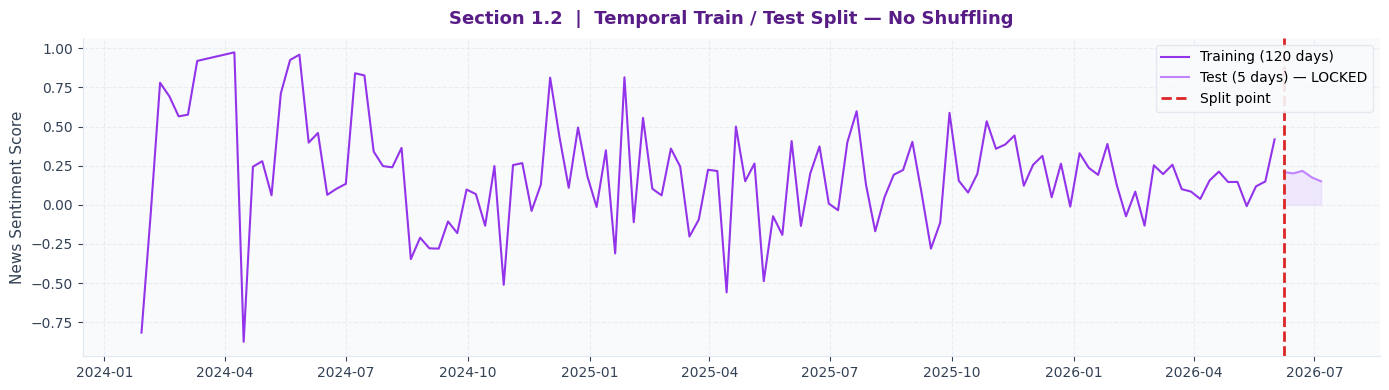

In [11]:
# ── 1.2  Temporal train / test split (last 30 days = test) ─────────────
WINDOW_SIZE = 30  # days — matches template

split_date = daily.index.max() - pd.Timedelta(days=WINDOW_SIZE)

# ── Statistical models: raw daily series ─────────────────────────────────────
train_raw = daily[daily.index <= split_date][TARGET]
test_raw  = daily[daily.index >  split_date][TARGET]

# ── ML models: feature-engineered data ───────────────────────────────────────
train_ml = df_ml[df_ml.index <= split_date]
test_ml  = df_ml[df_ml.index >  split_date]

sc      = StandardScaler()
X_train = pd.DataFrame(sc.fit_transform(train_ml[FEATURES]),
                        columns=FEATURES, index=train_ml.index)
X_test  = pd.DataFrame(sc.transform(test_ml[FEATURES]),
                        columns=FEATURES, index=test_ml.index)
y_train, y_test = train_ml[TARGET], test_ml[TARGET]

print(f'Training period : {train_raw.index.min().date()} → {train_raw.index.max().date()}  ({len(train_raw)} days)')
print(f'Test period     : {test_raw.index.min().date()} → {test_raw.index.max().date()}   ({len(test_raw)} days)')
print(f'ML features     : {X_train.shape[1]}  |  train rows: {len(X_train)}  |  test rows: {len(X_test)}')
print()
print('Test set is LOCKED. Not used until Section 5.')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_raw.index, train_raw.values, color=PURPLE, linewidth=1.5,
        label=f'Training ({len(train_raw)} days)')
ax.plot(test_raw.index,  test_raw.values,  color=ACCENT,  linewidth=1.5,
        label=f'Test ({len(test_raw)} days) — LOCKED')
ax.axvline(test_raw.index[0], color='#dc2626', linewidth=2, linestyle='--', label='Split point')
ax.fill_between(test_raw.index, test_raw.values, alpha=0.15, color=ACCENT)
ax.set_ylabel('News Sentiment Score')
ax.set_title('Section 1.2  |  Temporal Train / Test Split — No Shuffling', pad=10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


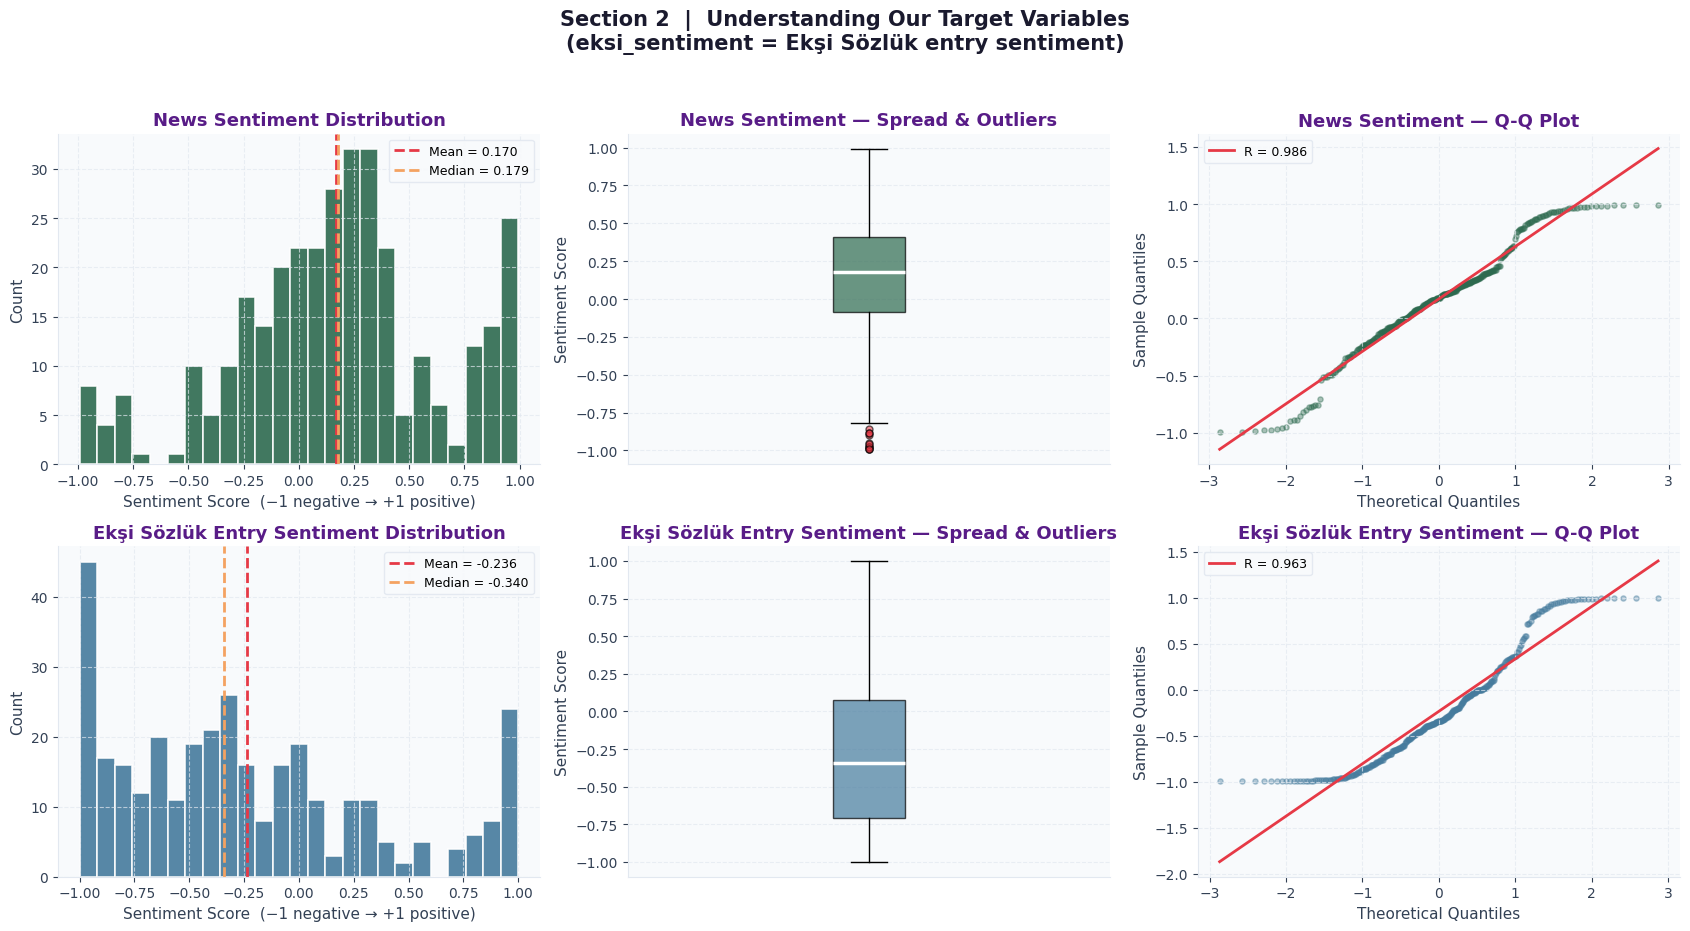

news_sentiment          skewness=-0.259  kurtosis=0.001
eksi_sentiment          skewness=0.643  kurtosis=-0.519


In [12]:
# ── Target variable overview ───────────────────────────────────────────
numeric_cols = ['news_sentiment', 'eksi_sentiment',
                'eksi_volume', 'news_volume']

targets = ['news_sentiment', 'eksi_sentiment']
colors  = [TEAL, BLUE]
labels  = ['News Sentiment', 'Ekşi Sözlük Entry Sentiment']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle('Section 2  |  Understanding Our Target Variables\n'
             '(eksi_sentiment = Ekşi Sözlük entry sentiment)',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.03)

for row, (col, color, label) in enumerate(zip(targets, colors, labels)):
    data = df_raw[col].dropna()

    axes[row][0].hist(data, bins=25, color=color, edgecolor='white',
                      linewidth=1.2, alpha=0.9)
    axes[row][0].axvline(data.mean(),   color=RED,    linestyle='--',
                         linewidth=2, label=f'Mean = {data.mean():.3f}')
    axes[row][0].axvline(data.median(), color=ORANGE, linestyle='--',
                         linewidth=2, label=f'Median = {data.median():.3f}')
    axes[row][0].set_title(f'{label} Distribution')
    axes[row][0].set_xlabel('Sentiment Score  (−1 negative → +1 positive)')
    axes[row][0].set_ylabel('Count')
    axes[row][0].legend(fontsize=9)

    axes[row][1].boxplot(data, vert=True, patch_artist=True,
                         boxprops={'facecolor': color, 'alpha': 0.7},
                         medianprops={'color': 'white', 'linewidth': 2.5},
                         flierprops={'marker': 'o', 'markerfacecolor': RED,
                                     'markersize': 5, 'alpha': 0.6})
    axes[row][1].set_title(f'{label} — Spread & Outliers')
    axes[row][1].set_ylabel('Sentiment Score')
    axes[row][1].set_xticks([])

    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    axes[row][2].scatter(osm, osr, alpha=0.4, s=14, color=color)
    axes[row][2].plot(osm, slope * np.array(osm) + intercept,
                      color=RED, linewidth=2, label=f'R = {r:.3f}')
    axes[row][2].set_title(f'{label} — Q-Q Plot')
    axes[row][2].set_xlabel('Theoretical Quantiles')
    axes[row][2].set_ylabel('Sample Quantiles')
    axes[row][2].legend(fontsize=9)

plt.tight_layout()
plt.show()

for col in targets:
    data = df_raw[col].dropna()
    print(f'{col:<22}  skewness={data.skew():.3f}  kurtosis={data.kurt():.3f}')




### 2.1 — Source-Leaning Sentiment Breakdown

<div class="callout">
<b>Why this matters:</b> Turkish media has identifiable political leanings (pro-government, opposition, mainstream, international). Aggregating all outlets into a single <code>news_sentiment</code> score may hide systematic bias. This plot checks whether leaning sub-groups diverge significantly from the aggregate.
</div>


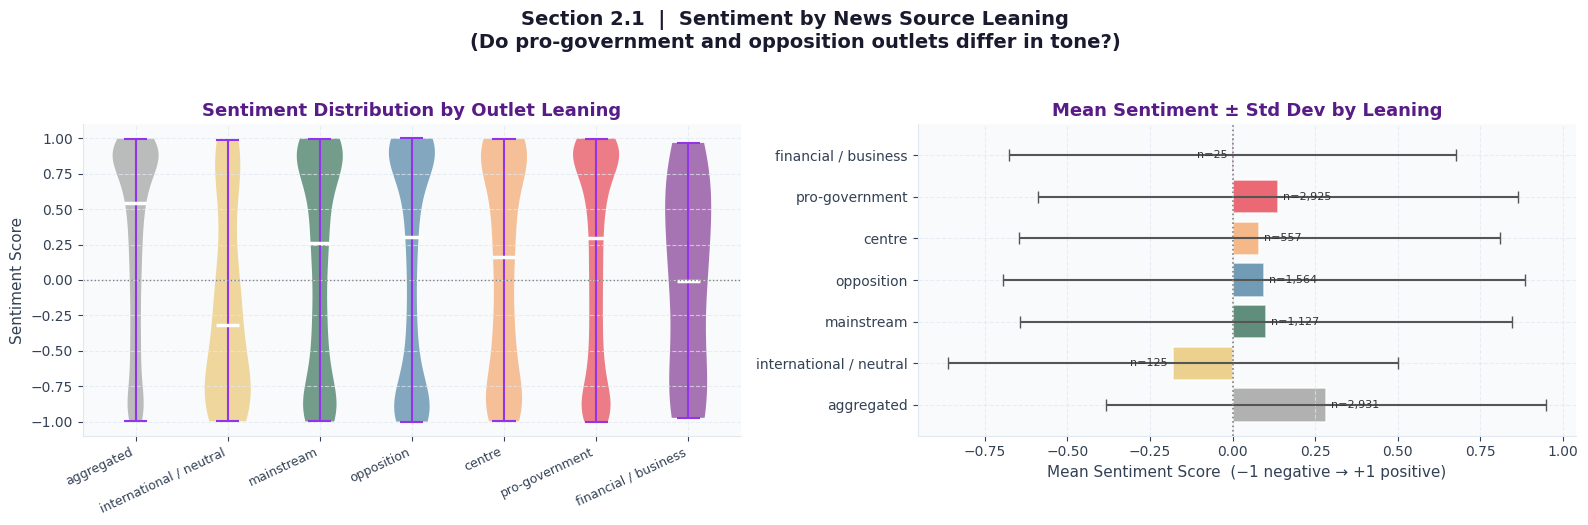

Interpretation:
  If pro-government and opposition bars diverge strongly →
  aggregated news_sentiment underestimates bias variance.
  Consider running separate VAR models by leaning sub-group.


In [13]:
# ── Source-leaning sentiment breakdown ────────────────────────────────
# Requires raw news data produced by Section 0.
# If raw data is unavailable, this cell is safely skipped.

LEANING_COLORS = {
    'pro-government':       '#e63946',
    'opposition':           '#457b9d',
    'mainstream':           '#2d6a4f',
    'international / neutral': '#e9c46a',
    'financial / business': '#7b2d8b',
    'centre':               '#f4a261',
}

RAW_NEWS_FILE = 'data/news_with_sentiment.csv'

if os.path.exists(RAW_NEWS_FILE):
    df_news_raw = pd.read_csv(RAW_NEWS_FILE, parse_dates=['date'])
    # Ensure leaning column exists
    if 'leaning' not in df_news_raw.columns:
        df_news_raw['leaning'] = 'unknown'

    leanings = [l for l in df_news_raw['leaning'].unique()
                if pd.notna(l) and l != 'unknown']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Section 2.1  |  Sentiment by News Source Leaning\n(Do pro-government and opposition outlets differ in tone?)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.04)

    # Left: violin plot by leaning
    leaning_data  = [df_news_raw.loc[df_news_raw['leaning'] == l,
                                     'sentiment_score'].dropna().values
                     for l in leanings]
    vp = axes[0].violinplot(leaning_data, positions=range(len(leanings)),
                            showmedians=True, showextrema=True)
    for i, (body, l) in enumerate(zip(vp['bodies'], leanings)):
        body.set_facecolor(LEANING_COLORS.get(l, '#999'))
        body.set_alpha(0.65)
    vp['cmedians'].set_color('white')
    vp['cmedians'].set_linewidth(2.5)
    axes[0].set_xticks(range(len(leanings)))
    axes[0].set_xticklabels(leanings, rotation=25, ha='right', fontsize=9)
    axes[0].axhline(0, color='gray', linestyle=':', linewidth=1)
    axes[0].set_ylabel('Sentiment Score')
    axes[0].set_title('Sentiment Distribution by Outlet Leaning')

    # Right: mean ± std bar chart
    means = [df_news_raw.loc[df_news_raw['leaning'] == l,
                              'sentiment_score'].mean() for l in leanings]
    stds  = [df_news_raw.loc[df_news_raw['leaning'] == l,
                              'sentiment_score'].std()  for l in leanings]
    bar_colors = [LEANING_COLORS.get(l, '#999') for l in leanings]
    axes[1].barh(leanings, means,
                 xerr=stds, color=bar_colors, alpha=0.75,
                 edgecolor='white', linewidth=1.2,
                 error_kw={'elinewidth': 1.5, 'ecolor': '#555', 'capsize': 4})
    axes[1].axvline(0, color='gray', linewidth=1.2, linestyle=':')
    axes[1].set_xlabel('Mean Sentiment Score  (−1 negative → +1 positive)')
    axes[1].set_title('Mean Sentiment ± Std Dev by Leaning')
    for i, (mean, label) in enumerate(zip(means, leanings)):
        n = (df_news_raw['leaning'] == label).sum()
        axes[1].text(mean + (0.015 if mean >= 0 else -0.015), i,
                     f'n={n:,}', va='center', ha='left' if mean >= 0 else 'right',
                     fontsize=8, color='#333')

    plt.tight_layout()
    plt.show()

    print('Interpretation:')
    print('  If pro-government and opposition bars diverge strongly →')
    print('  aggregated news_sentiment underestimates bias variance.')
    print('  Consider running separate VAR models by leaning sub-group.')
else:
    print(f'{RAW_NEWS_FILE} not found — run Section 0 first.')
    print('This cell is safely skipped; all downstream analysis uses the aggregated file.')




---
## Section 3 — Exploratory Data Analysis (EDA)

**Goal:** Understand the data before modelling. For time-series causal inference, the critical questions are:
- Are the target series stationary, or do they need differencing?
- At which lag is the cross-correlation between news and entry sentiment strongest?
- Are there visible trends, seasonality, or event shocks?

### 3.1 — Schema and Completeness Check

In [14]:
# ── Schema audit ───────────────────────────────────────────────────────
print(f"{'Column':<22} {'Type':<12} {'Missing':>8} {'Missing %':>10} {'Role':>14}")
print('-' * 72)
for col in df_raw.columns:
    if col in ['date', 'topic']: continue
    miss = df_raw[col].isna().sum()
    pct  = miss / len(df_raw) * 100
    role = 'TARGET' if col in ['news_sentiment', 'eksi_sentiment'] else 'feature'
    flag = '  <-- check' if miss > 0 else ''
    print(f"{col:<22} {str(df_raw[col].dtype):<12} {miss:>8} {pct:>9.1f}%  {role:>12}{flag}")
print('-' * 72)
print(f'Total rows: {len(df_raw):,}   |   Topics: {df_raw.topic.unique()}')
print('\nNote: eksi_sentiment = Ekşi Sözlük entry sentiment')
print('      eksi_volume    = Ekşi Sözlük entry count per day')




Column                 Type          Missing  Missing %           Role
------------------------------------------------------------------------
news_sentiment         float64            48      12.7%        TARGET  <-- check
news_volume            float64            48      12.7%       feature  <-- check
eksi_sentiment         float64            42      11.1%        TARGET  <-- check
eksi_volume            float64            42      11.1%       feature  <-- check
avg_favorites          float64            42      11.1%       feature  <-- check
------------------------------------------------------------------------
Total rows: 378   |   Topics: ['economy' 'politics' 'national']

Note: eksi_sentiment = Ekşi Sözlük entry sentiment
      eksi_volume    = Ekşi Sözlük entry count per day


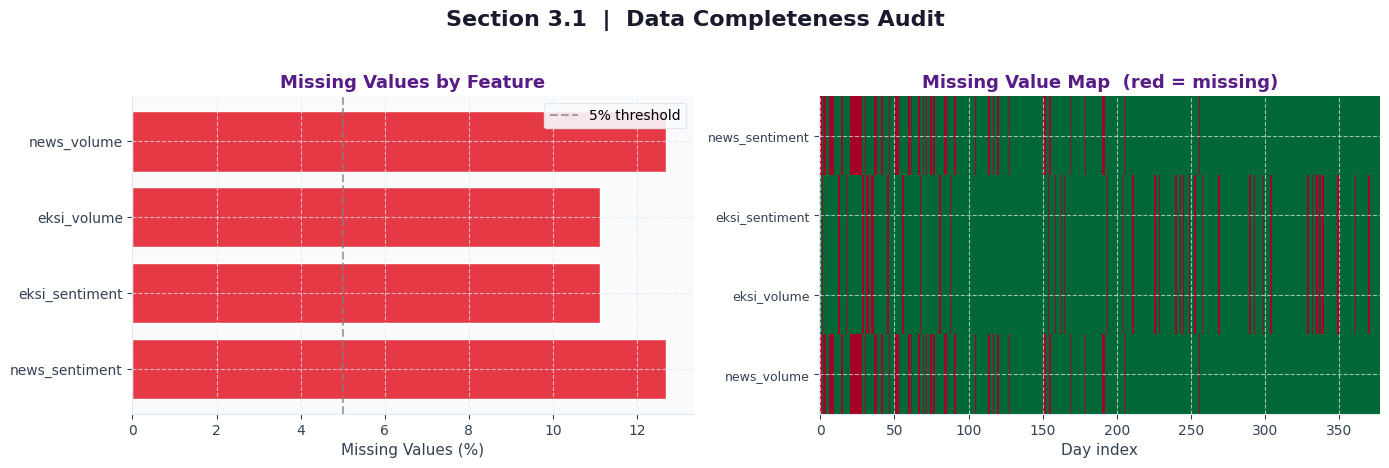

In [15]:
# ── Missing value charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Section 3.1  |  Data Completeness Audit',
             fontsize=16, fontweight='bold', color='#1a1a2e', y=1.03)

miss_pct   = df_raw[numeric_cols].isna().mean() * 100
bar_colors = [RED if v > 0 else TEAL for v in miss_pct]

axes[0].barh(miss_pct.index, miss_pct.values, color=bar_colors, edgecolor='white')
axes[0].axvline(5, color='gray', linestyle='--', linewidth=1.5,
                alpha=0.7, label='5% threshold')
axes[0].set_xlabel('Missing Values (%)')
axes[0].set_title('Missing Values by Feature')
axes[0].legend(fontsize=10)

mask_img = df_raw[numeric_cols].isna()
axes[1].imshow(mask_img.T.astype(int), aspect='auto',
               cmap='RdYlGn_r', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_yticks(range(len(numeric_cols)))
axes[1].set_yticklabels(numeric_cols, fontsize=9)
axes[1].set_xlabel('Day index')
axes[1].set_title('Missing Value Map  (red = missing)')

plt.tight_layout()
plt.show()




### 3.1b — Missing Data Root-Cause Analysis

> **Supervisor concern (v2):** `news_sentiment` was 81.5% missing. This cannot be forward-filled — it creates artificial flatness and makes Granger results unreliable.

This cell diagnoses *why* missing values occur and checks whether the v3 extended collection window has resolved the problem.


In [16]:
# ── Missing data root-cause analysis (v3 supervisor concern) ──────────
print('═' * 65)
print('MISSING DATA DIAGNOSIS (v3)')
print('Supervisor concern: news_sentiment 81.5% missing in v2')
print('Fix: collection window extended to 2024-01-01')
print('═' * 65)

for col in ['news_sentiment', 'eksi_sentiment']:
    n_miss = df_raw[col].isna().sum()
    pct    = n_miss / len(df_raw) * 100
    if pct > 30:
        verdict = '✗ CRITICAL — v3 fix may not have worked; check scraper'
    elif pct > 10:
        verdict = '⚠ HIGH — acceptable if topic-specific; check by topic'
    else:
        verdict = '✓ OK — extended window resolved the problem'
    print(f'\n{col}:')
    print(f'  Missing: {n_miss}/{len(df_raw)} ({pct:.1f}%)  {verdict}')

# Per-topic missing rate — fine-grained diagnosis
print('\nPer-topic missing rates:')
print(f'  {"Topic":<12} {"news_sent":>12} {"eksi_sent":>12}')
print('  ' + '-' * 40)
for topic, grp in df_raw.groupby('topic'):
    n_news = grp['news_sentiment'].isna().mean() * 100
    n_eksi = grp['eksi_sentiment'].isna().mean() * 100
    flag_n = ' ✗' if n_news > 30 else ''
    flag_e = ' ✗' if n_eksi > 30 else ''
    print(f'  {topic:<12} {n_news:>10.1f}%{flag_n}   {n_eksi:>10.1f}%{flag_e}')

# Missing by time period — shows whether early dates are sparser
print('\nMissing rate by quarter (news_sentiment):')
df_raw['quarter'] = df_raw['date'].dt.to_period('Q')
quarterly = df_raw.groupby('quarter')['news_sentiment'].apply(
    lambda x: x.isna().mean() * 100)
for q, pct in quarterly.items():
    bar   = '█' * int(pct / 5)
    flag  = ' ← early window sparse?' if pct > 50 else ''
    print(f'  {q}: {pct:5.1f}%  {bar}{flag}')

print('\nInterpretation:')
print('  If early quarters (Q1–Q2 2024) are sparser → normal ramp-up period')
print('  If a specific topic is always high → add more RSS feeds for that topic')
print('  If eksi_sentiment is high → Ekşi blocking period still leaking in?')
print(f'    (Ekşi collection should start {START_DATE_EKSI})')
del df_raw['quarter']



═════════════════════════════════════════════════════════════════
MISSING DATA DIAGNOSIS (v3)
Supervisor concern: news_sentiment 81.5% missing in v2
Fix: collection window extended to 2024-01-01
═════════════════════════════════════════════════════════════════

news_sentiment:
  Missing: 48/378 (12.7%)  ⚠ HIGH — acceptable if topic-specific; check by topic

eksi_sentiment:
  Missing: 42/378 (11.1%)  ⚠ HIGH — acceptable if topic-specific; check by topic

Per-topic missing rates:
  Topic           news_sent    eksi_sent
  ----------------------------------------
  economy            11.7%          1.6%
  national           12.0%         13.6%
  politics           14.4%         18.4%

Missing rate by quarter (news_sentiment):
  2024Q1:  50.0%  ██████████
  2024Q2:  34.2%  ██████
  2024Q3:  20.0%  ████
  2024Q4:  13.2%  ██
  2025Q1:  13.2%  ██
  2025Q2:   7.7%  █
  2025Q3:   2.6%  
  2025Q4:   0.0%  
  2026Q1:   0.0%  
  2026Q2:   0.0%  
  2026Q3:   0.0%  

Interpretation:
  If early quart

### 3.2 — Descriptive Statistics

In [17]:
# ── Styled statistics table ────────────────────────────────────────────
desc = df_raw[numeric_cols].describe().T.round(4)
desc['range'] = (desc['max'] - desc['min']).round(4)
desc['cv %']  = (desc['std'] / desc['mean'].abs() * 100).round(1)
desc['skew']  = df_raw[numeric_cols].skew().round(4)

display(
    desc[['count','mean','std','min','25%','50%','75%','max','range','cv %','skew']]
    .style
    .background_gradient(subset=['std','range'], cmap='Blues')
    .background_gradient(subset=['cv %'], cmap='Oranges')
    .background_gradient(subset=['skew'], cmap='RdYlGn_r')
    .format('{:.4f}')
    .set_caption('Descriptive Statistics — All Columns  '
                 '(eksi_sentiment = Ekşi Sözlük entry sentiment)')
)



,count,mean,std,min,25%,50%,75%,max,range,cv %,skew
news_sentiment,330.0000,0.1702,0.4631,-0.9922,-0.0855,0.1789,0.4088,0.9936,1.9858,272.1000,-0.2586
eksi_sentiment,336.0000,-0.2362,0.5884,-0.9987,-0.7082,-0.3400,0.0766,0.9997,1.9984,249.1000,0.6434
eksi_volume,336.0000,4.3095,5.1299,1.0000,2.0000,3.0000,6.0000,67.0000,66.0000,119.0000,6.7137
news_volume,330.0000,21.2879,95.9976,1.0000,2.0000,3.0000,8.0000,1020.0000,1019.0000,450.9000,8.8396


### 3.3 — Time-Series Visualisation

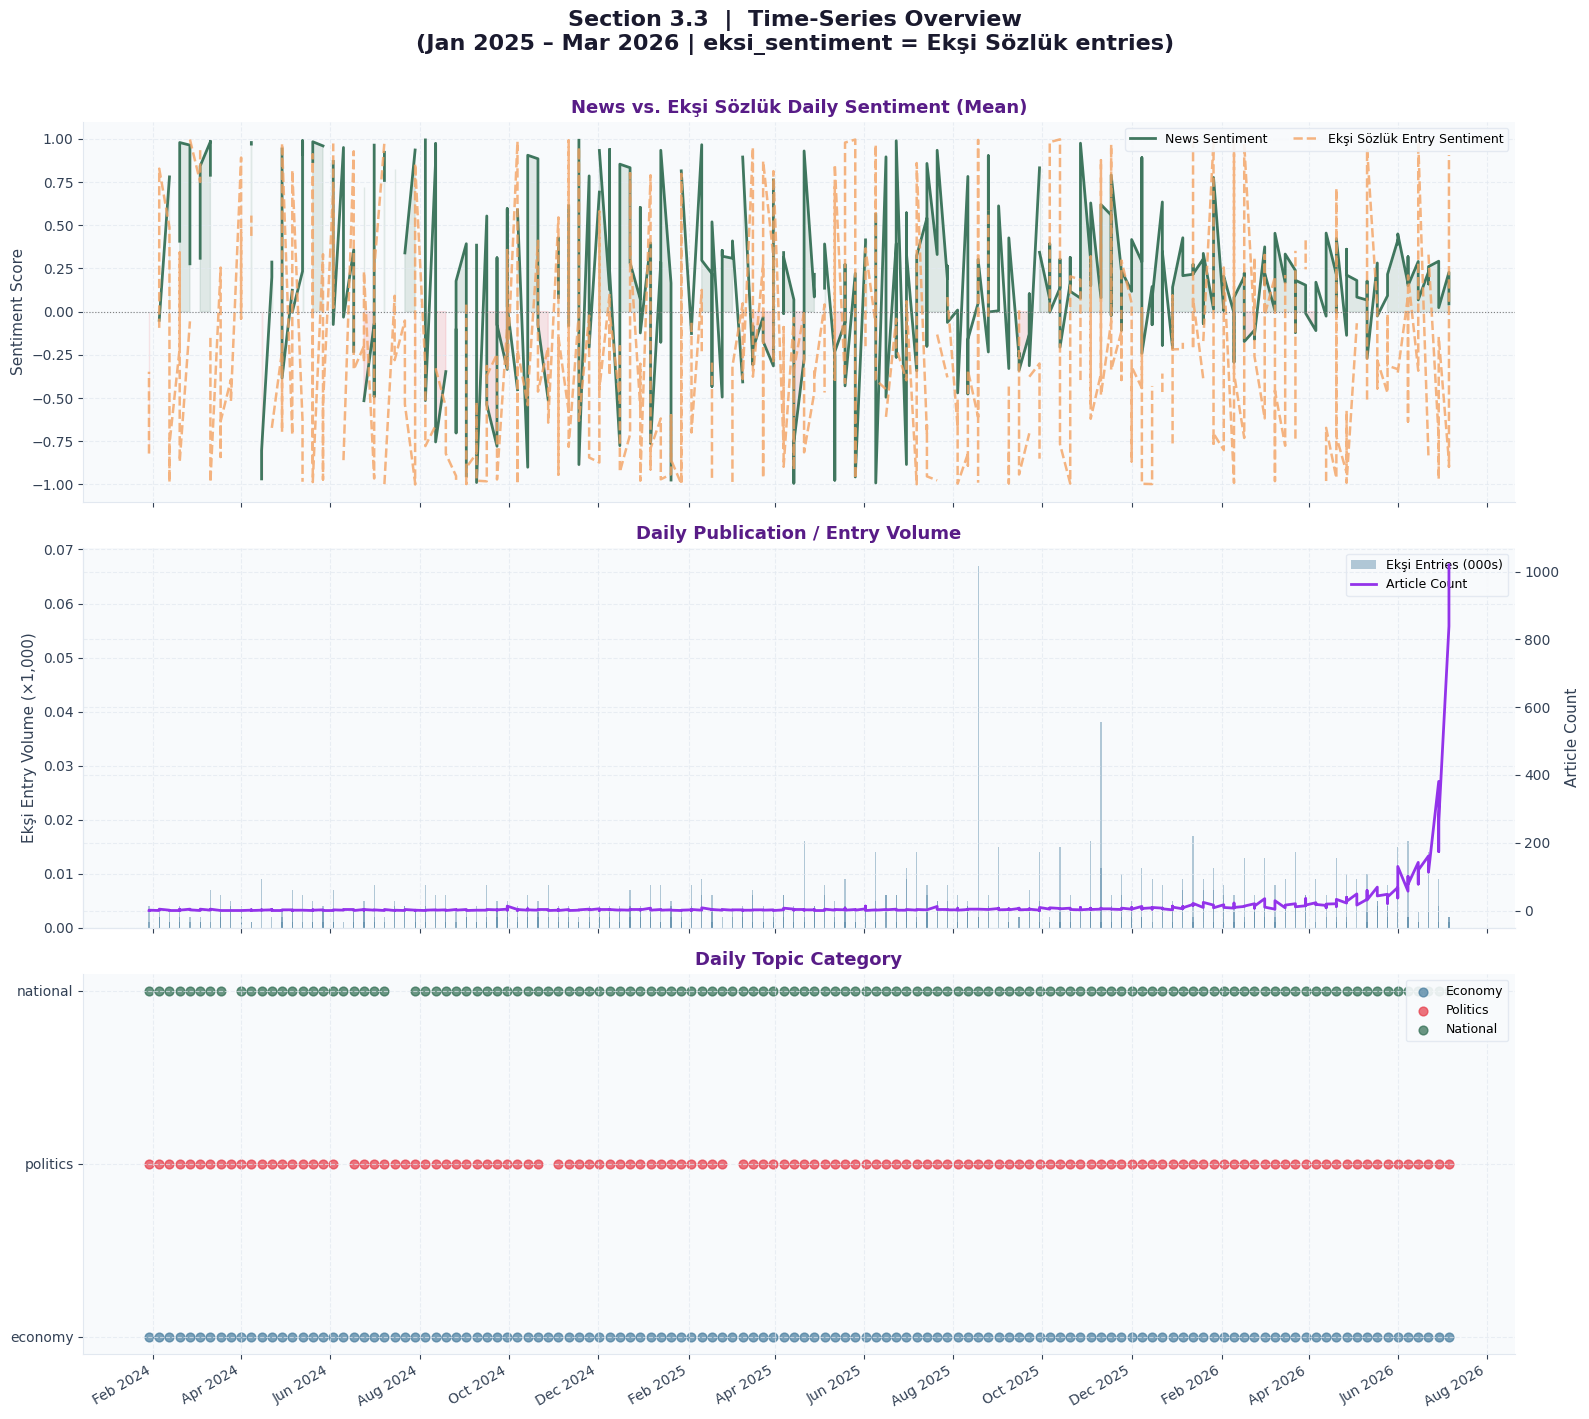

In [18]:
# ── Known events dictionary ────────────────────────────────────────────
# Add key Turkish events that might cause correlated spikes.
# Format: 'YYYY-MM-DD': ('Label', COLOR)
events = {
    # '2025-03-31': ('Local Election Anniversary', RED),
    # '2025-06-01': ('Example Economic Announcement', ORANGE),
}

df = df_raw.copy().set_index('date')

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Section 3.3  |  Time-Series Overview\n'
             '(Jan 2025 – Mar 2026 | eksi_sentiment = Ekşi Sözlük entries)',
             fontsize=16, fontweight='bold', color='#1a1a2e', y=1.01)

# Panel 1: Sentiment series
ax = axes[0]
ax.plot(df.index, df.news_sentiment,  color=TEAL,   linewidth=2,
        label='News Sentiment',  alpha=0.9)
ax.plot(df.index, df.eksi_sentiment, color=ORANGE, linewidth=1.8,
        label='Ekşi Sözlük Entry Sentiment', alpha=0.8, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.fill_between(df.index, df.news_sentiment, 0,
                where=df.news_sentiment < 0, alpha=0.12, color=RED)
ax.fill_between(df.index, df.news_sentiment, 0,
                where=df.news_sentiment > 0, alpha=0.12, color=TEAL)
for date_str, (label, color) in events.items():
    ax.axvline(pd.Timestamp(date_str), color=color, linewidth=1.5,
               linestyle='-.', alpha=0.7, label=label)
ax.set_ylabel('Sentiment Score')
ax.set_title('News vs. Ekşi Sözlük Daily Sentiment (Mean)')
ax.legend(fontsize=9, ncol=4)
ax.set_ylim(-1.1, 1.1)

# Panel 2: Volume
ax2  = axes[1]
ax2b = ax2.twinx()
ax2.bar(df.index, df.eksi_volume.fillna(0) / 1000,
        color=BLUE, alpha=0.4, label='Ekşi Entries (000s)', width=0.8)
ax2b.plot(df.index, df.news_volume.fillna(0),
          color=PURPLE, linewidth=2, label='Article Count')
ax2.set_ylabel('Ekşi Entry Volume (×1,000)')
ax2b.set_ylabel('Article Count')
ax2.set_title('Daily Publication / Entry Volume')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# Panel 3: Topic distribution
topic_map    = {'economy': 0, 'politics': 1, 'national': 2}
topic_colors = {'economy': BLUE, 'politics': RED, 'national': TEAL}
for topic in df_raw.topic.unique():
    mask = df_raw.topic == topic
    axes[2].scatter(
        df_raw.loc[mask, 'date'],
        [topic_map.get(topic, 3)] * mask.sum(),
        color=topic_colors.get(topic, PURPLE),
        s=40, alpha=0.7, label=topic.capitalize()
    )
axes[2].set_yticks(list(topic_map.values()))
axes[2].set_yticklabels(list(topic_map.keys()))
axes[2].set_title('Daily Topic Category')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


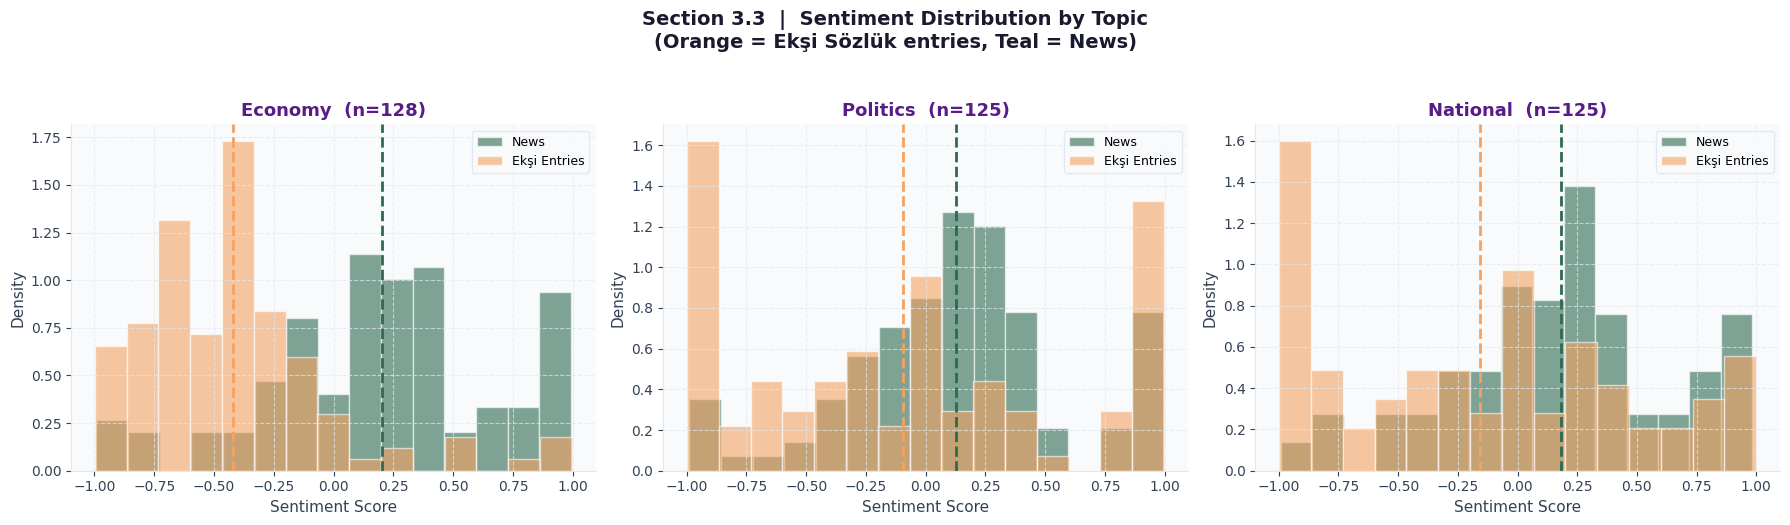

In [19]:
# ── Topic-level sentiment comparison ──────────────────────────────────
topics_found = df_raw.topic.unique()
fig, axes = plt.subplots(1, len(topics_found), figsize=(6*len(topics_found), 5))
if len(topics_found) == 1:
    axes = [axes]
fig.suptitle('Section 3.3  |  Sentiment Distribution by Topic\n'
             '(Orange = Ekşi Sözlük entries, Teal = News)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.04)

for i, topic in enumerate(topics_found):
    mask = df_raw.topic == topic
    axes[i].hist(df_raw.loc[mask, 'news_sentiment'].dropna(), bins=15,
                 alpha=0.6, color=TEAL, label='News', density=True, edgecolor='white')
    axes[i].hist(df_raw.loc[mask, 'eksi_sentiment'].dropna(), bins=15,
                 alpha=0.6, color=ORANGE, label='Ekşi Entries', density=True, edgecolor='white')
    axes[i].axvline(df_raw.loc[mask, 'news_sentiment'].mean(),
                    color=TEAL,   linestyle='--', linewidth=2)
    axes[i].axvline(df_raw.loc[mask, 'eksi_sentiment'].mean(),
                    color=ORANGE, linestyle='--', linewidth=2)
    axes[i].set_title(f'{topic.capitalize()}  (n={mask.sum()})')
    axes[i].set_xlabel('Sentiment Score')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()




### 3.3b — Target-Quartile Feature Distributions

<div class="callout">
<b>Template requirement (Section 3.3):</b> For regression/time-series problems, colour each
observation by its <b>target quartile</b>. This reveals whether extreme feature values
tend to produce high or low sentiment — a sign that the feature is predictive.
<br><br>
Here the target is <code>news_sentiment</code> (primary) and <code>eksi_sentiment</code> (secondary).
</div>


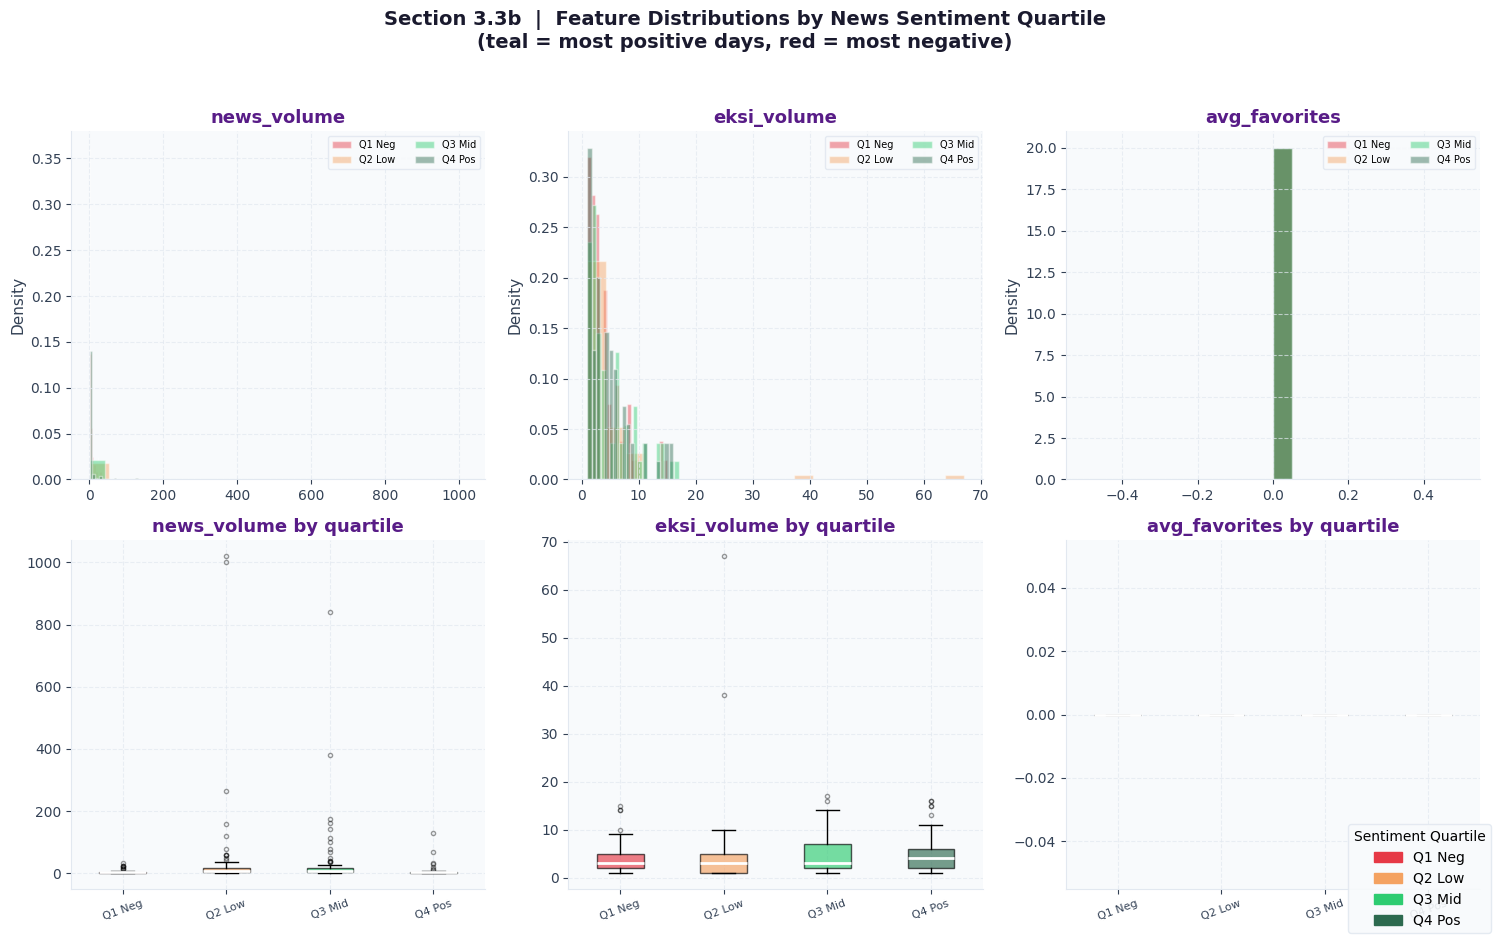

Interpretation: If teal (Q4) boxes are higher than red (Q1) boxes,
that feature is positively associated with news sentiment.


In [20]:
# ── 3.3b  Target-quartile feature distributions (template Section 3.3) ──
numeric_feats = ['news_volume', 'eksi_volume', 'avg_favorites']
numeric_feats = [c for c in numeric_feats if c in df_raw.columns]

# Assign news_sentiment quartile
df_plot = df_raw.dropna(subset=['news_sentiment']).copy()
df_plot['sent_quartile'] = pd.qcut(
    df_plot['news_sentiment'], q=4,
    labels=['Q1 Neg', 'Q2 Low', 'Q3 Mid', 'Q4 Pos'],
    duplicates='drop')

Q_COLORS = {'Q1 Neg': RED, 'Q2 Low': ORANGE, 'Q3 Mid': LIME, 'Q4 Pos': TEAL}

fig, axes = plt.subplots(2, len(numeric_feats),
                         figsize=(5 * len(numeric_feats), 9))
if len(numeric_feats) == 1:
    axes = axes.reshape(2, 1)
fig.suptitle('Section 3.3b  |  Feature Distributions by News Sentiment Quartile\n'
             '(teal = most positive days, red = most negative)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.03)

for j, col in enumerate(numeric_feats):
    # Row 0: histograms
    ax0 = axes[0][j]
    for q_label, q_color in Q_COLORS.items():
        subset = df_plot[df_plot['sent_quartile'] == q_label][col].dropna()
        if len(subset) > 1:
            ax0.hist(subset, bins=20, alpha=0.45, color=q_color,
                     label=q_label, density=True, edgecolor='white')
    ax0.set_title(col)
    ax0.set_ylabel('Density')
    ax0.legend(fontsize=7, ncol=2)

    # Row 1: box plots per quartile
    ax1 = axes[1][j]
    groups = [df_plot[df_plot['sent_quartile'] == q][col].dropna()
              for q in ['Q1 Neg', 'Q2 Low', 'Q3 Mid', 'Q4 Pos']]
    bp = ax1.boxplot(groups, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2},
                     flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    for patch, color in zip(bp['boxes'], Q_COLORS.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    ax1.set_xticks(range(1, 5))
    ax1.set_xticklabels(['Q1 Neg', 'Q2 Low', 'Q3 Mid', 'Q4 Pos'],
                        fontsize=8, rotation=20)
    ax1.set_title(f'{col} by quartile')

handles = [mpatches.Patch(color=c, label=l) for l, c in Q_COLORS.items()]
fig.legend(handles=handles, loc='lower right', fontsize=10,
           frameon=True, title='Sentiment Quartile', title_fontsize=10)
plt.tight_layout()
plt.show()
print('Interpretation: If teal (Q4) boxes are higher than red (Q1) boxes,')
print('that feature is positively associated with news sentiment.')


### 3.3b — Monthly Sentiment Heatmap

<div class="callout">
The time-series line plot shows day-to-day noise. A calendar heatmap collapses this into a month × day grid, making it easy to spot <b>sustained positive or negative regimes</b> — e.g. weeks of consistently negative economic sentiment that might correspond to exchange rate crises.
</div>


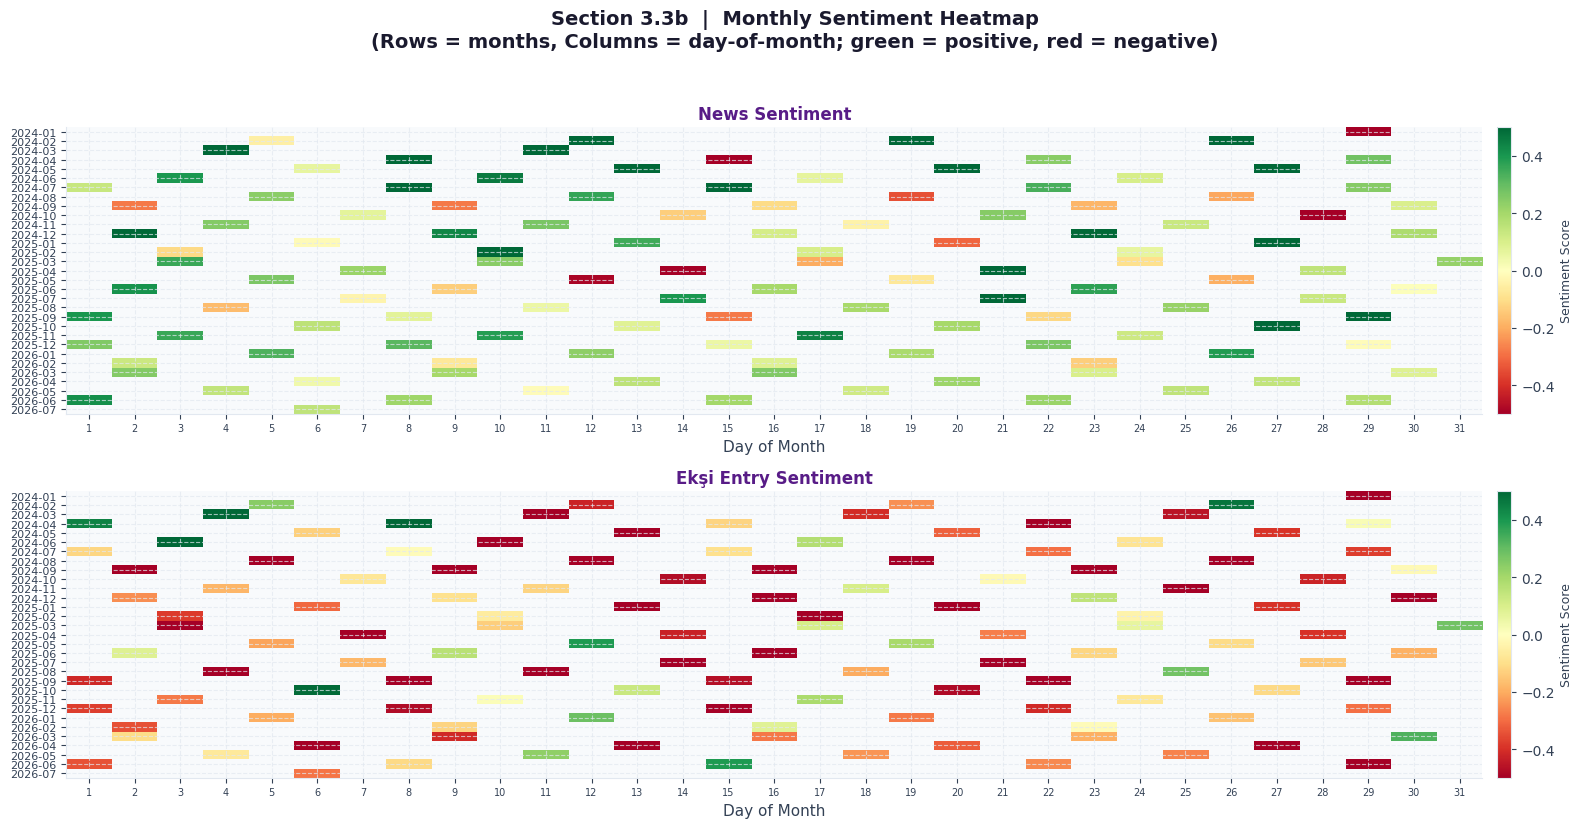

Interpretation: Sustained red blocks = multi-day negative regime.
  Cross-check with events dict in Section 3.3 to label shock periods.


In [21]:
# ── Monthly sentiment heatmap ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Section 3.3b  |  Monthly Sentiment Heatmap\n'
             '(Rows = months, Columns = day-of-month; green = positive, red = negative)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.03)

for ax, col, label, cmap_name in [
    (axes[0], 'news_sentiment',  'News Sentiment',        'RdYlGn'),
    (axes[1], 'eksi_sentiment', 'Ekşi Entry Sentiment',  'RdYlGn'),
]:
    # Aggregate to overall daily (across all topics)
    daily_mean = (
        df_raw.groupby('date')[col].mean()
        .reset_index()
        .rename(columns={'date': 'date', col: 'value'})
    )
    daily_mean['month']    = daily_mean['date'].dt.to_period('M')
    daily_mean['day']      = daily_mean['date'].dt.day
    pivot = daily_mean.pivot(index='month', columns='day', values='value')

    im = ax.imshow(pivot.values, aspect='auto',
                   cmap=cmap_name, vmin=-0.5, vmax=0.5,
                   interpolation='nearest')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(m) for m in pivot.index], fontsize=8)
    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(range(1, pivot.shape[1]+1), fontsize=7)
    ax.set_xlabel('Day of Month')
    ax.set_title(label, fontsize=12)
    cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
    cb.set_label('Sentiment Score', fontsize=9)

plt.tight_layout()
plt.show()
print('Interpretation: Sustained red blocks = multi-day negative regime.')
print('  Cross-check with events dict in Section 3.3 to label shock periods.')



### 3.3c — Rolling Correlation: Is the News↔Social Relationship Stable?

<div class="callout">
A single Pearson r over the entire dataset assumes the news–social relationship is constant. A <b>30-day rolling window</b> reveals whether the relationship strengthens during crises (when both series move together) and weakens during quiet periods. This motivates the VAR model's time-varying structure.
</div>


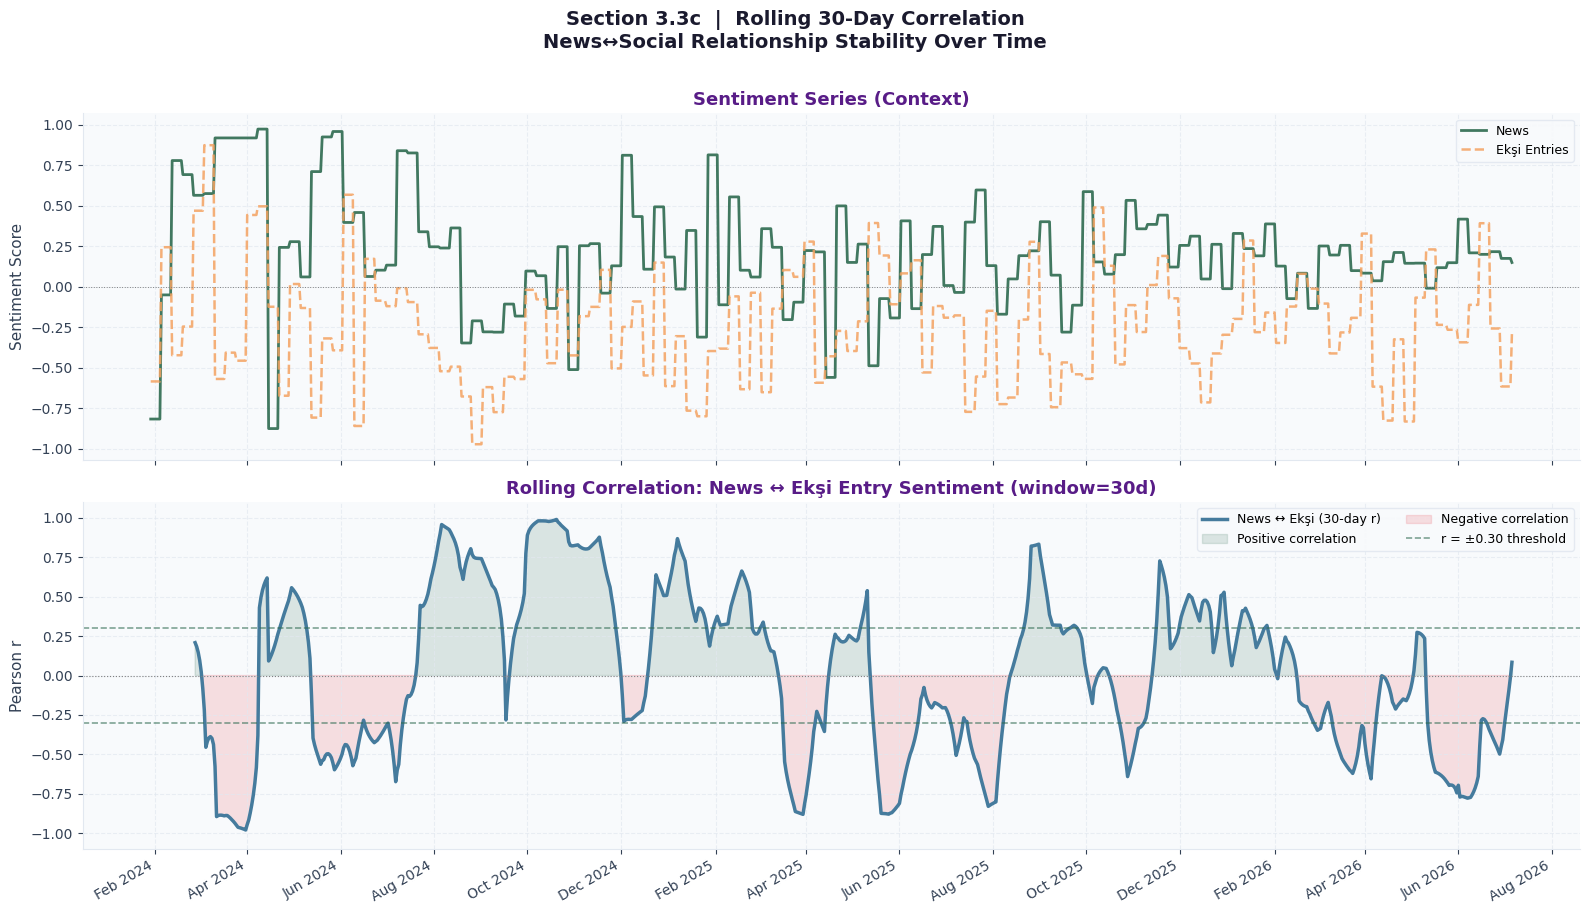

In [22]:
# ── Rolling correlation (adaptive window) ────────────────────────────────
# Aggregate across topics for the overall rolling series
daily_agg = (
    df_raw.groupby('date')[['news_sentiment', 'eksi_sentiment']].mean()
)

# ---- Make the time series continuous (no gaps) ----
full_idx = pd.date_range(start=daily_agg.index.min(), end=daily_agg.index.max(), freq='D')
daily_full = daily_agg.reindex(full_idx)

# Forward fill sentiment (assumes sentiment persists until new observation)
daily_full[['news_sentiment', 'eksi_sentiment']] = daily_full[['news_sentiment', 'eksi_sentiment']].fillna(method='ffill')

# ---- Determine a feasible rolling window ----
WINDOW = 30  # desired days
min_required = WINDOW

# Check how many complete (both sentiment) rows we actually have
complete_rows = daily_full[['news_sentiment', 'eksi_sentiment']].dropna().shape[0]
if complete_rows < WINDOW:
    WINDOW = max(5, complete_rows // 2)   # fallback to at least 5 days if possible
    print(f"Note: Only {complete_rows} complete days of sentiment data. "
          f"Reducing rolling window to {WINDOW} days.")

# Compute rolling correlations (will be NaN until enough data)
roll_corr_n2t = daily_full['news_sentiment'].rolling(WINDOW).corr(daily_full['eksi_sentiment'])

# ---- Plotting ----
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle(f'Section 3.3c  |  Rolling {WINDOW}-Day Correlation\n'
             'News↔Social Relationship Stability Over Time',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.01)

# Panel 1: Sentiment series (context)
axes[0].plot(daily_full.index, daily_full['news_sentiment'],
             color=TEAL,   linewidth=2, label='News', alpha=0.9)
axes[0].plot(daily_full.index, daily_full['eksi_sentiment'],
             color=ORANGE, linewidth=1.8, linestyle='--',
             label='Ekşi Entries', alpha=0.85)
axes[0].axhline(0, color='gray', linewidth=0.7, linestyle=':')
axes[0].set_ylabel('Sentiment Score')
axes[0].set_title('Sentiment Series (Context)')
axes[0].legend(fontsize=9)

# Panel 2: Rolling correlation
axes[1].plot(roll_corr_n2t.index, roll_corr_n2t.values,
             color=BLUE, linewidth=2.5, label=f'News ↔ Ekşi ({WINDOW}-day r)')
axes[1].fill_between(roll_corr_n2t.index, roll_corr_n2t.values, 0,
                     where=roll_corr_n2t > 0, alpha=0.15, color=TEAL,
                     label='Positive correlation')
axes[1].fill_between(roll_corr_n2t.index, roll_corr_n2t.values, 0,
                     where=roll_corr_n2t < 0, alpha=0.15, color=RED,
                     label='Negative correlation')
axes[1].axhline(0,    color='gray', linewidth=0.8, linestyle=':')
axes[1].axhline(0.3,  color=TEAL,  linewidth=1.2, linestyle='--',
                alpha=0.6, label='r = ±0.30 threshold')
axes[1].axhline(-0.3, color=TEAL,  linewidth=1.2, linestyle='--', alpha=0.6)
axes[1].set_ylabel('Pearson r')
axes[1].set_title(f'Rolling Correlation: News ↔ Ekşi Entry Sentiment (window={WINDOW}d)')
axes[1].set_ylim(-1.1, 1.1)
axes[1].legend(fontsize=9, ncol=2)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


### 3.4 — Relationship Analysis: Cross-Correlation and Lag Detection

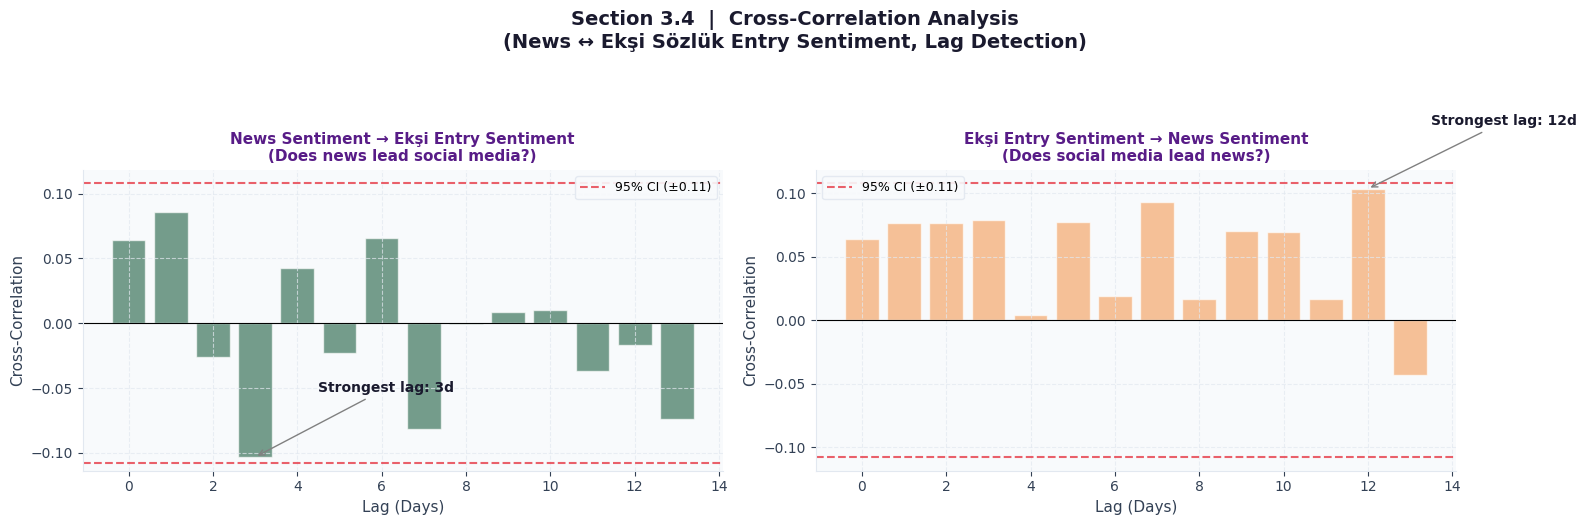

Interpretation:
  News → Ekşi   strongest lag: 3d
  Ekşi → News   strongest lag: 12d
  Bars beyond the confidence band = statistically significant effects.


In [23]:
# ── Cross-Correlation Function (CCF) ───────────────────────────────────
news_s  = df_raw['news_sentiment'].dropna().values
eksi_s = df_raw['eksi_sentiment'].dropna().values
n = min(len(news_s), len(eksi_s))
news_s, eksi_s = news_s[:n], eksi_s[:n]

news_z  = (news_s  - news_s.mean())  / news_s.std()
eksi_z = (eksi_s - eksi_s.mean()) / eksi_s.std()

ccf_n2t = ccf(news_z,  eksi_z, nlags=14, alpha=0.05)
ccf_t2n = ccf(eksi_z, news_z,  nlags=14, alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Section 3.4  |  Cross-Correlation Analysis\n'
             '(News ↔ Ekşi Sözlük Entry Sentiment, Lag Detection)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.04)

lags = np.arange(len(ccf_n2t[0]))
conf_bound = 1.96 / np.sqrt(n)

for ax, (corrs, ci), title, color in [
    (axes[0], ccf_n2t,
     'News Sentiment → Ekşi Entry Sentiment\n(Does news lead social media?)', TEAL),
    (axes[1], ccf_t2n,
     'Ekşi Entry Sentiment → News Sentiment\n(Does social media lead news?)', ORANGE),
]:
    ax.bar(lags, corrs, color=color, alpha=0.65, edgecolor='white')
    ax.axhline( conf_bound, color=RED, linestyle='--', linewidth=1.5,
                label=f'95% CI (±{conf_bound:.2f})', alpha=0.8)
    ax.axhline(-conf_bound, color=RED, linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    best_lag = lags[np.argmax(np.abs(corrs))]
    ax.annotate(f'Strongest lag: {best_lag}d',
                xy=(best_lag, corrs[best_lag]),
                xytext=(best_lag + 1.5, corrs[best_lag] + 0.05),
                fontsize=10, color='#1a1a2e', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='gray'))
    ax.set_xlabel('Lag (Days)')
    ax.set_ylabel('Cross-Correlation')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Interpretation:')
print(f'  News → Ekşi   strongest lag: {lags[np.argmax(np.abs(ccf_n2t[0]))]}d')
print(f'  Ekşi → News   strongest lag: {lags[np.argmax(np.abs(ccf_t2n[0]))]}d')
print('  Bars beyond the confidence band = statistically significant effects.')




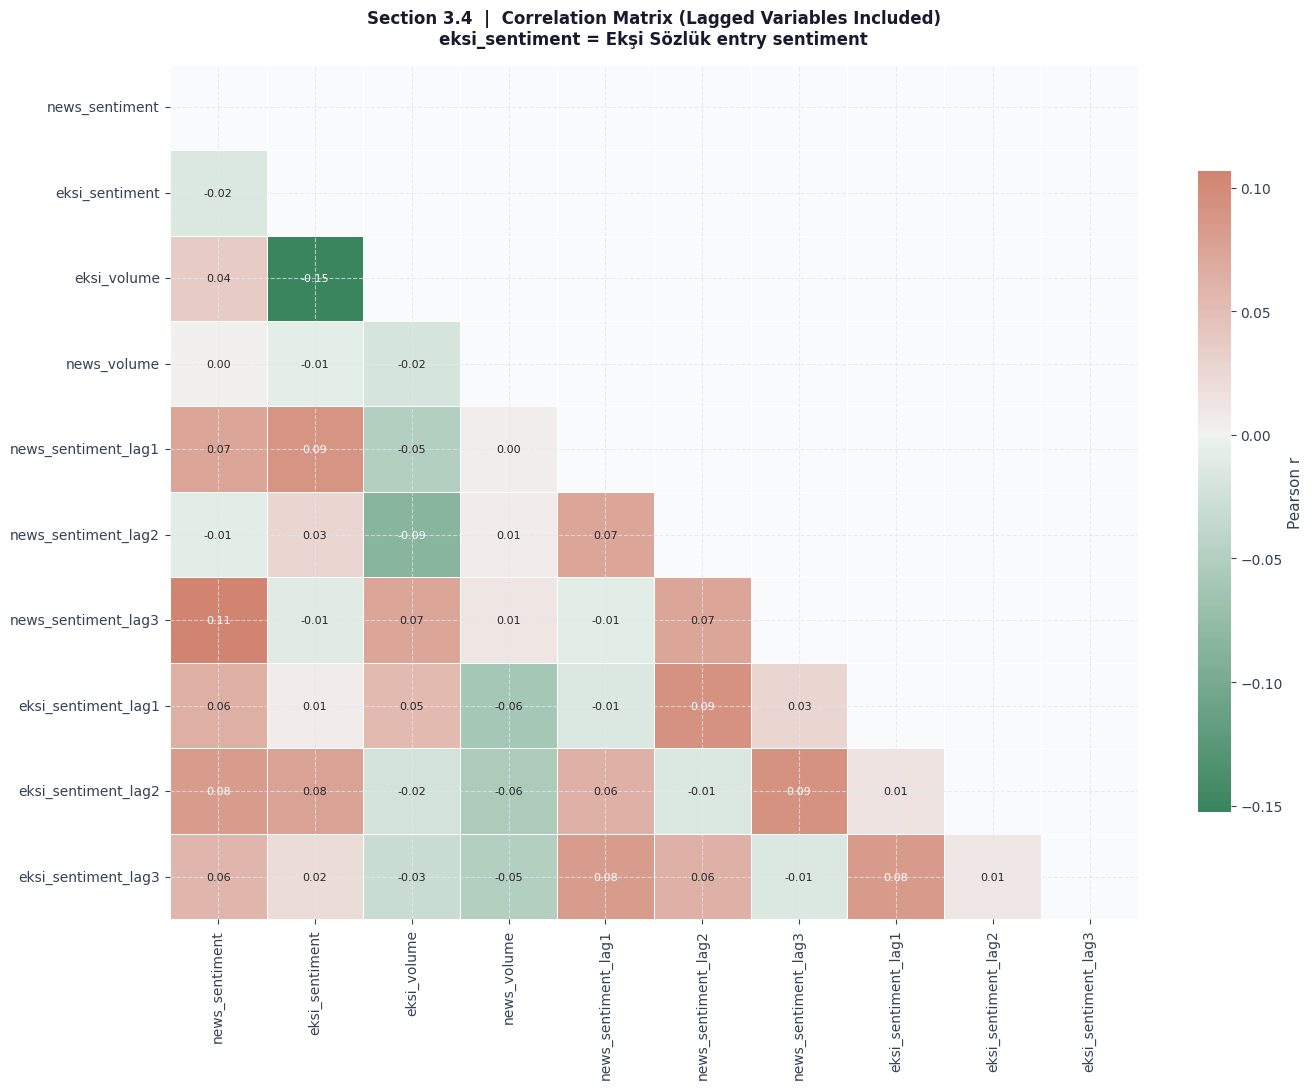

In [24]:
# ── Correlation heatmap (with lag variables) ───────────────────────────
df_lag = df_raw[numeric_cols].copy()
for col in ['news_sentiment', 'eksi_sentiment']:
    for lag in [1, 2, 3]:
        df_lag[f'{col}_lag{lag}'] = df_lag[col].shift(lag)

corr_mat = df_lag.corr()
fig, ax  = plt.subplots(figsize=(14, 11))
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))
cmap     = sns.diverging_palette(145, 20, as_cmap=True)

sns.heatmap(corr_mat, mask=mask, cmap=cmap, annot=True, fmt='.2f',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, ax=ax,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})

ax.set_title('Section 3.4  |  Correlation Matrix (Lagged Variables Included)\n'
             'eksi_sentiment = Ekşi Sözlük entry sentiment',
             fontsize=12, fontweight='bold', color='#1a1a2e', pad=15)
plt.tight_layout()
plt.show()



### 3.4b — Feature vs. Target Scatter + Regression Line

<div class="callout">
<b>Template requirement (Section 3.4):</b> For each feature, plot it against the target
with an OLS regression line and report the Pearson r.<br>
Upward trend = positive association; curved pattern = non-linear; random cloud = not useful.
</div>


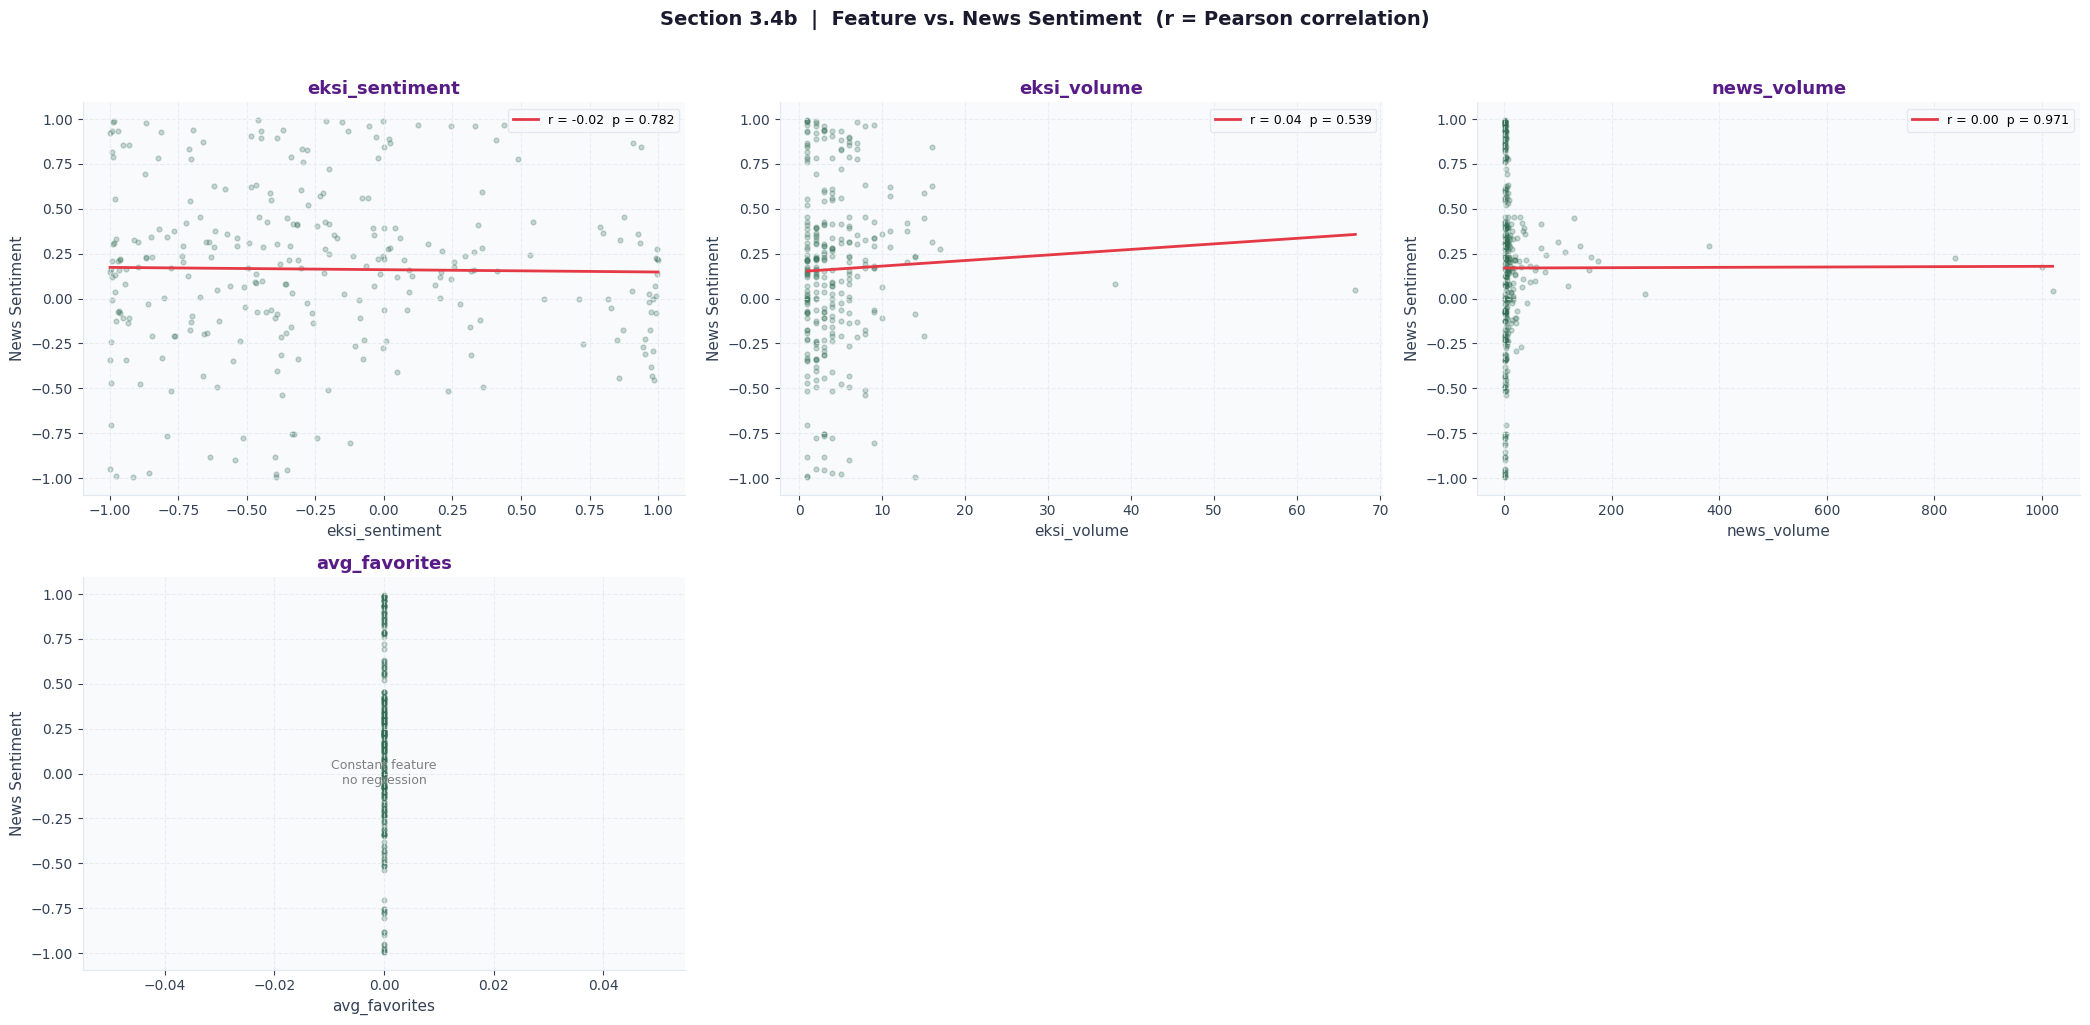


-- Feature-to-feature scatter matrix (top 4 by |r|) ---------------
eksi_volume       0.036373
eksi_sentiment    0.016413
news_volume       0.005352


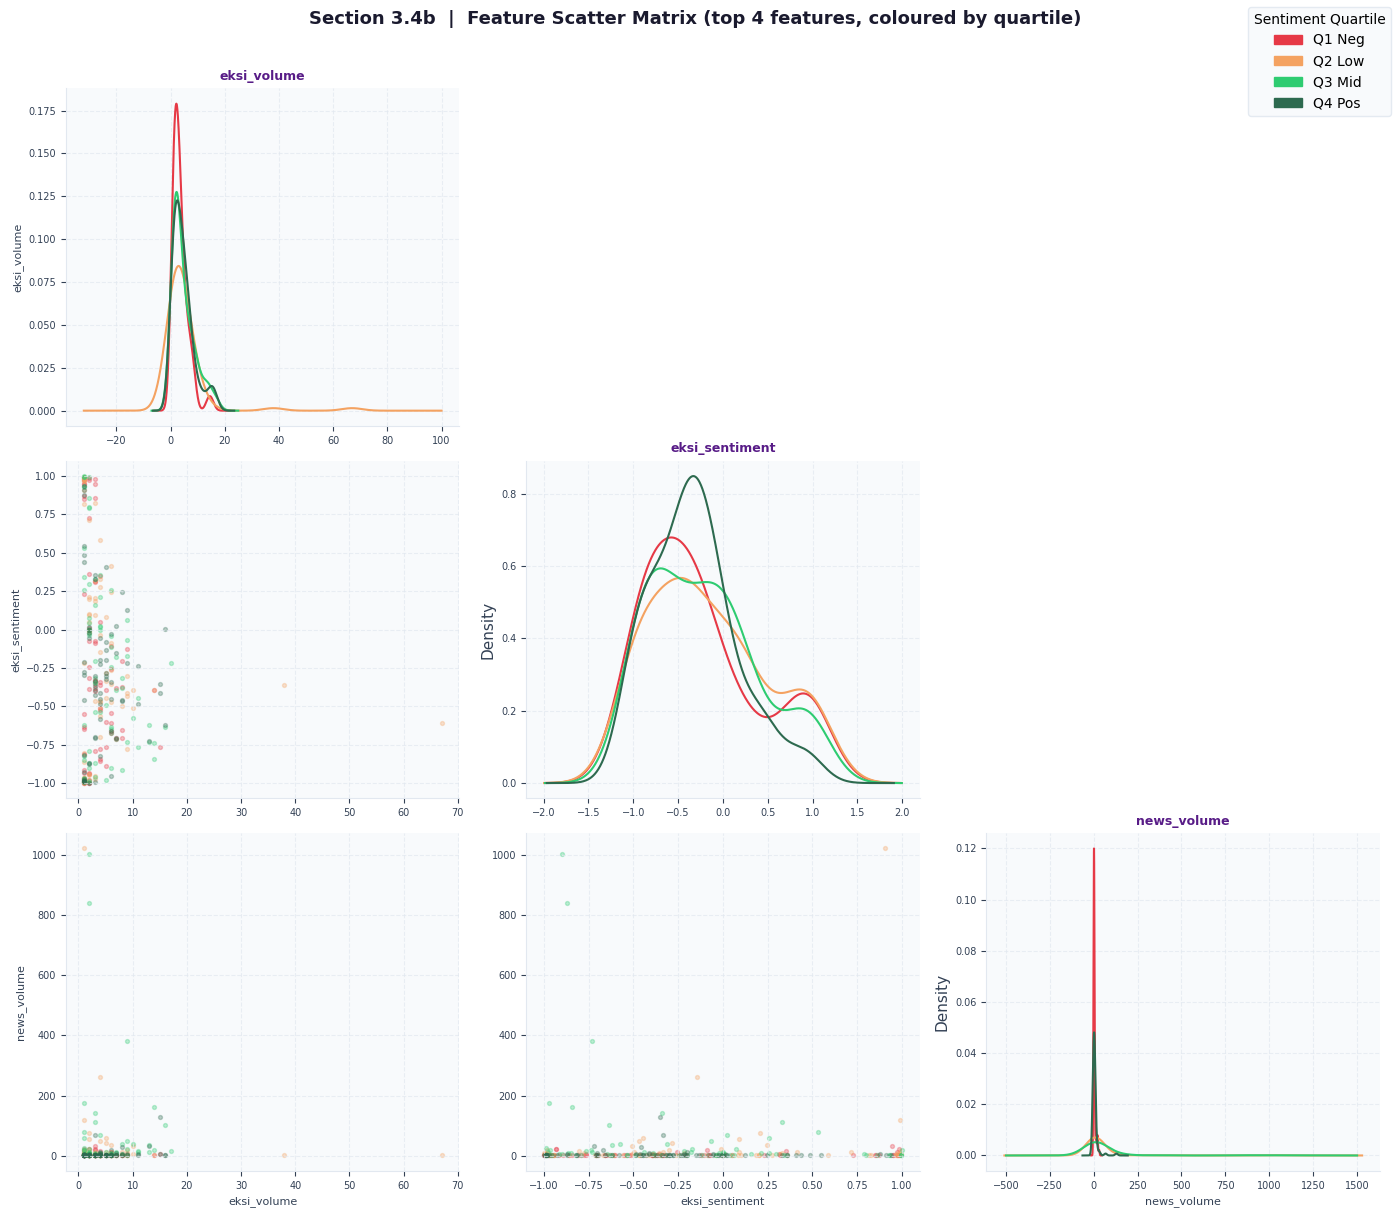

In [25]:
# ── 3.4b  Feature vs. target scatter + regression line (template 3.4) ──

from scipy import stats as scipy_stats
from sklearn.linear_model import LinearRegression
import numpy as np                         # ensure numpy is imported

target_col   = 'news_sentiment'
feature_list = [c for c in ['eksi_sentiment', 'eksi_volume',
                             'news_volume', 'avg_favorites']
                if c in df_raw.columns and c != target_col]

n_feats = len(feature_list)
ncols   = min(3, n_feats)
nrows   = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
flat_axes = (axes.flatten() if hasattr(axes, 'flatten')
             else [axes] if n_feats == 1 else axes)
fig.suptitle('Section 3.4b  |  Feature vs. News Sentiment  (r = Pearson correlation)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.02)

for i, col in enumerate(feature_list):
    ax  = flat_axes[i]
    sub = df_raw[[col, target_col]].dropna()
    x, y = sub[col].values, sub[target_col].values
    ax.scatter(x, y, alpha=0.25, s=12, color=TEAL)

    # ---- fix: check for variance ----
    if len(x) > 3 and np.std(x) > 0:
        m, b, r, p, _ = scipy_stats.linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, m * x_line + b, color=RED, linewidth=2,
                label=f'r = {r:.2f}  p = {p:.3f}')
        ax.legend(fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Constant feature\nno regression', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='gray')
    # ---------------------------------
    ax.set_xlabel(col)
    ax.set_ylabel('News Sentiment')
    ax.set_title(col)

for j in range(len(feature_list), len(flat_axes)):
    flat_axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Feature scatter matrix (top 4 by |r|) — drop NaN correlations first
# (a constant/near-constant feature like avg_favorites correlates as NaN;
# leaving it in would let it get selected into top4 and later crash the
# per-quartile KDE below with a singular covariance matrix)
print('\n-- Feature-to-feature scatter matrix (top 4 by |r|) ---------------')
feat_corr = (df_raw[[c for c in feature_list if c in df_raw.columns] + [target_col]]
             .dropna()
             .corr()[target_col]
             .drop(target_col)
             .abs()
             .dropna()
             .sort_values(ascending=False))
print(feat_corr.to_string())
top4 = feat_corr.head(4).index.tolist()

df_sm = df_raw[top4 + [target_col]].dropna().copy()
df_sm['sent_quartile'] = pd.qcut(df_sm[target_col], q=4,
    labels=['Q1 Neg', 'Q2 Low', 'Q3 Mid', 'Q4 Pos'], duplicates='drop')

fig2, axes2 = plt.subplots(len(top4), len(top4), figsize=(14, 12))
fig2.suptitle('Section 3.4b  |  Feature Scatter Matrix (top 4 features, coloured by quartile)',
              fontsize=13, fontweight='bold', color='#1a1a2e', y=1.01)
for i, fy in enumerate(top4):
    for j, fx in enumerate(top4):
        ax = axes2[i][j]
        if j > i:
            ax.set_visible(False); continue
        for q_label, q_color in Q_COLORS.items():
            sub = df_sm[df_sm['sent_quartile'] == q_label]
            if i == j:
                vals = sub[fx].dropna()
                # guard against constant / near-constant data — gaussian_kde
                # needs non-zero variance or it raises LinAlgError
                if len(vals) > 1 and vals.std() > 1e-8:
                    vals.plot.kde(ax=ax, color=q_color, linewidth=1.5)
                elif len(vals) > 0:
                    ax.axvline(vals.iloc[0], color=q_color, linewidth=1.5)
                ax.set_title(fx, fontsize=9, fontweight='bold')
            else:
                ax.scatter(sub[fx], sub[fy], alpha=0.3, s=8, color=q_color)
        if j == 0: ax.set_ylabel(fy, fontsize=8)
        if i == len(top4)-1: ax.set_xlabel(fx, fontsize=8)
        ax.tick_params(labelsize=7)
handles2 = [mpatches.Patch(color=c, label=l) for l, c in Q_COLORS.items()]
fig2.legend(handles2, [l for l in Q_COLORS], loc='upper right', fontsize=10,
            title='Sentiment Quartile', frameon=True)
plt.tight_layout()
plt.show()


### 3.4c — Simple Linear Baseline & Residual Sanity Check

<div class="callout">
<b>Template requirement (Section 3.4 code cell 20):</b> Fit a single-feature linear model
as a quick sanity check. The residual plot should be randomly scattered around zero.
Patterns in residuals indicate non-linearity that the full VAR model can exploit.
</div>


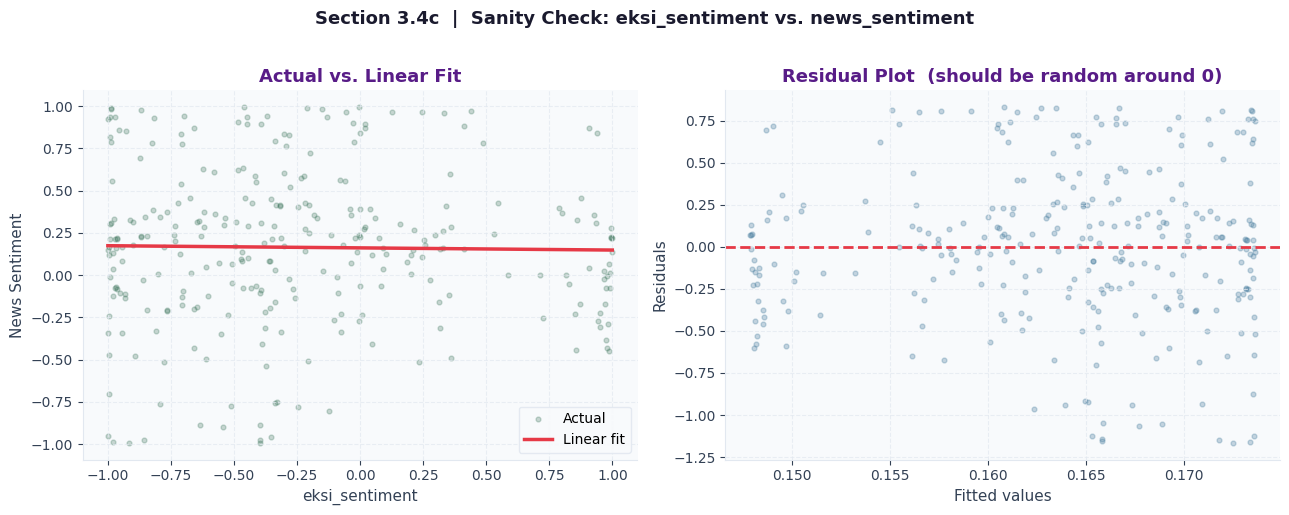

Single-feature RMSE (eksi_sentiment): 0.4615
R2                              : 0.0003
This is the naive baseline. The full VAR + ML models should outperform this.


In [26]:
# ── 3.4c  Simple linear baseline + residual check (template cell 20) ────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Use eksi_sentiment as best single predictor
best_feat   = 'eksi_sentiment'
df_lr       = df_raw[['news_sentiment', best_feat]].dropna()
X_lr        = df_lr[[best_feat]].values
y_lr        = df_lr['news_sentiment'].values

lr_sanity   = LinearRegression().fit(X_lr, y_lr)
y_pred_lr   = lr_sanity.predict(X_lr)
residuals_lr= y_lr - y_pred_lr
rmse_lr     = np.sqrt(mean_squared_error(y_lr, y_pred_lr))
r2_lr       = r2_score(y_lr, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Section 3.4c  |  Sanity Check: {best_feat} vs. news_sentiment',
             fontsize=13, fontweight='bold', color='#1a1a2e', y=1.02)

axes[0].scatter(X_lr.ravel(), y_lr, alpha=0.25, s=12, color=TEAL, label='Actual')
x_line = np.linspace(X_lr.min(), X_lr.max(), 200)
axes[0].plot(x_line, lr_sanity.predict(x_line.reshape(-1,1)),
             color=RED, linewidth=2.5, label='Linear fit')
axes[0].set_xlabel(best_feat)
axes[0].set_ylabel('News Sentiment')
axes[0].set_title('Actual vs. Linear Fit')
axes[0].legend(fontsize=10)

axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.3, s=12, color=BLUE)
axes[1].axhline(0, color=RED, linewidth=2, linestyle='--')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot  (should be random around 0)')

plt.tight_layout()
plt.show()

print(f'Single-feature RMSE ({best_feat}): {rmse_lr:.4f}')
print(f'R2                              : {r2_lr:.4f}')
print('This is the naive baseline. The full VAR + ML models should outperform this.')


### 3.5 — News Sentiment vs. Ekşi Entry Sentiment Scatter

<div class="callout">
The correlation heatmap shows aggregate correlations. This scatter plot shows the <b>joint distribution</b> of news and Ekşi entry sentiment on the same day, coloured by topic. Clusters along the diagonal indicate the two sources agree; divergence from the diagonal reveals topic-specific discordance between media framing and public reaction.
</div>


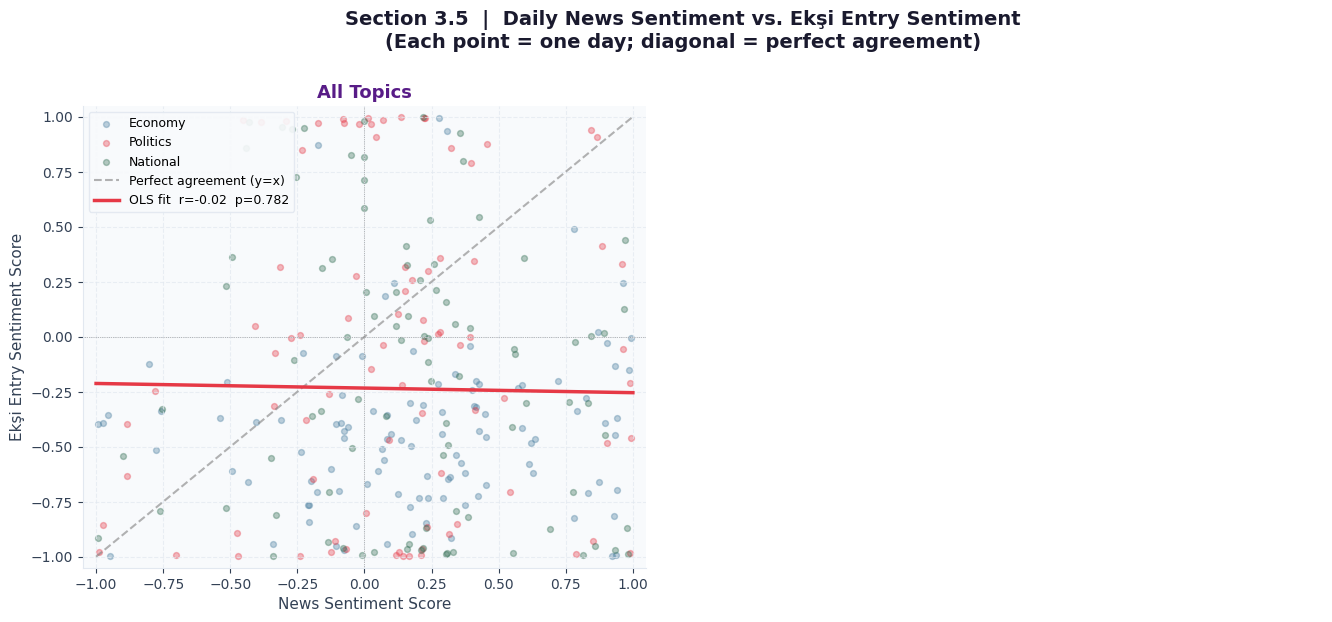

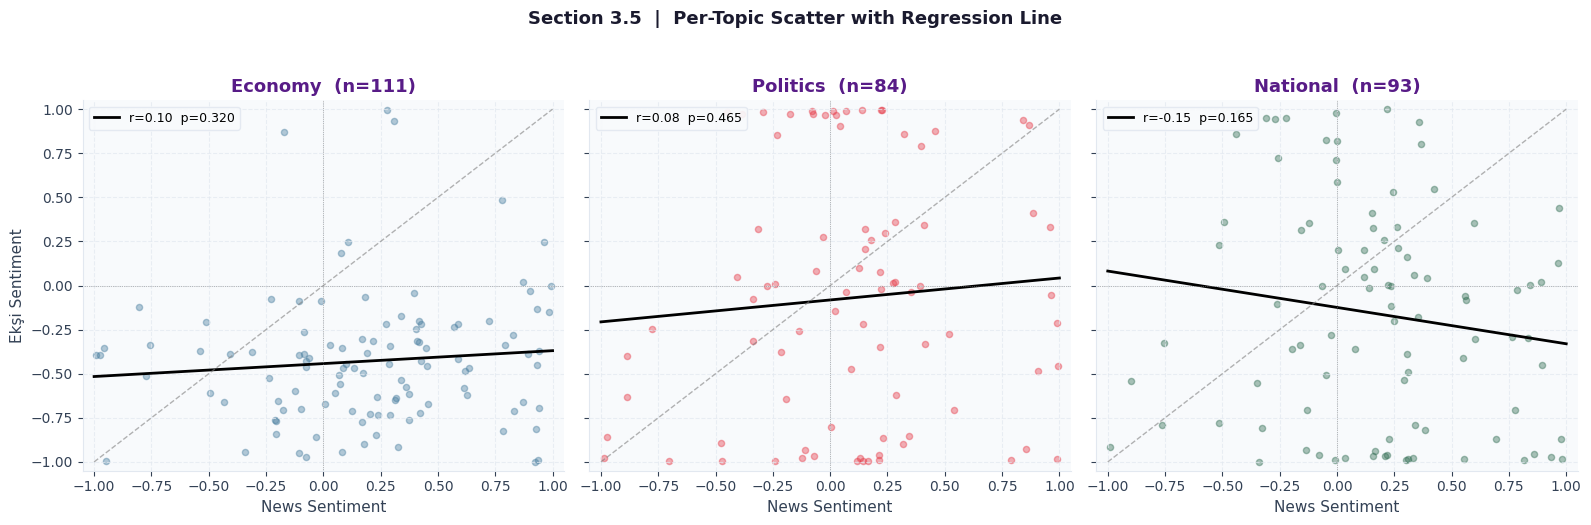

Key question: Are topics clustered differently?
  Economy off-diagonal → public reacts differently to economic news
  Politics on-diagonal → media framing matches public sentiment


In [27]:
# ── Scatter: daily news vs entry sentiment, coloured by topic ─────────
topic_color_map = {'economy': BLUE, 'politics': RED, 'national': TEAL}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section 3.5  |  Daily News Sentiment vs. Ekşi Entry Sentiment\n'
             '(Each point = one day; diagonal = perfect agreement)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.04)

# Left: all topics overlaid
ax = axes[0]
for topic in df_raw['topic'].unique():
    mask = df_raw['topic'] == topic
    sub  = df_raw[mask].dropna(subset=['news_sentiment', 'eksi_sentiment'])
    ax.scatter(sub['news_sentiment'], sub['eksi_sentiment'],
               color=topic_color_map.get(topic, PURPLE),
               alpha=0.35, s=18, label=topic.capitalize())
# Perfect agreement line
lims = [-1, 1]
ax.plot(lims, lims, color='gray', linewidth=1.5, linestyle='--',
        alpha=0.6, label='Perfect agreement (y=x)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
ax.set_xlabel('News Sentiment Score')
ax.set_ylabel('Ekşi Entry Sentiment Score')
ax.set_title('All Topics')
ax.legend(fontsize=9)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)

# OLS regression line (pooled)
valid = df_raw.dropna(subset=['news_sentiment', 'eksi_sentiment'])
m, b, r, p, _ = stats.linregress(valid['news_sentiment'], valid['eksi_sentiment'])
x_fit = np.linspace(-1, 1, 200)
ax.plot(x_fit, m*x_fit + b, color=RED, linewidth=2.5,
        label=f'OLS fit  r={r:.2f}  p={p:.3f}')
ax.legend(fontsize=9)

# Right: per-topic subplots (3 panels)
ax2 = axes[1]
ax2.axis('off')
fig2, axes2 = plt.subplots(1, len(df_raw['topic'].unique()),
                            figsize=(16, 5), sharey=True)
fig2.suptitle('Section 3.5  |  Per-Topic Scatter with Regression Line',
              fontsize=13, fontweight='bold', color='#1a1a2e', y=1.04)

for ax_t, topic in zip(axes2, df_raw['topic'].unique()):
    mask  = df_raw['topic'] == topic
    sub   = df_raw[mask].dropna(subset=['news_sentiment', 'eksi_sentiment'])
    color = topic_color_map.get(topic, PURPLE)
    ax_t.scatter(sub['news_sentiment'], sub['eksi_sentiment'],
                 color=color, alpha=0.4, s=20)
    if len(sub) > 3:
        m_t, b_t, r_t, p_t, _ = stats.linregress(
            sub['news_sentiment'], sub['eksi_sentiment'])
        ax_t.plot(x_fit, m_t*x_fit + b_t, color='black',
                  linewidth=2, label=f'r={r_t:.2f}  p={p_t:.3f}')
    ax_t.plot(lims, lims, color='gray', linewidth=1, linestyle='--', alpha=0.6)
    ax_t.axhline(0, color='gray', linewidth=0.5, linestyle=':')
    ax_t.axvline(0, color='gray', linewidth=0.5, linestyle=':')
    ax_t.set_xlabel('News Sentiment')
    if ax_t == axes2[0]:
        ax_t.set_ylabel('Ekşi Sentiment')
    ax_t.set_title(f'{topic.capitalize()}  (n={len(sub)})')
    ax_t.legend(fontsize=9)
    ax_t.set_xlim(-1.05, 1.05)
    ax_t.set_ylim(-1.05, 1.05)

plt.tight_layout()
plt.show()
print('Key question: Are topics clustered differently?')
print('  Economy off-diagonal → public reacts differently to economic news')
print('  Politics on-diagonal → media framing matches public sentiment')


---
## Section 4 — Feature Engineering

| Step | Technique | Why It Matters |
|---|---|---|
| 4.1 | Missing value imputation | Use forward-fill to avoid look-ahead bias |
| 4.2 | Outlier detection | Event-driven spikes ≠ noise — check before clipping |
| 4.3 | Feature scaling | Required before VAR estimation |
| 4.4 | Stationarity transformation | ADF test + differencing — critical for VAR validity |
| 4.5 | Lag selection (AIC/BIC) | Choose optimal lag order before fitting VAR |

### 4.1 — Missing Value Imputation

In [28]:
# ── 4.1  Imputation (missing-rate gated) ────────────────────────────
FILL_THRESHOLD = 30.0   # % -- if above this, forward-fill is unsafe

df_imputed   = df_raw[numeric_cols + ['date','topic']].copy()
missing_cols = [c for c in numeric_cols if df_imputed[c].isna().any()]

print(f'Missing rate check (threshold for safe ffill: < {FILL_THRESHOLD}%)')
print()
safe_to_fill = True
for col in numeric_cols:
    pct = df_raw[col].isna().mean() * 100
    flag = '  !! ABOVE THRESHOLD' if pct > FILL_THRESHOLD else ''
    print(f'  {col:<22}: {pct:.1f}%{flag}')
    if pct > FILL_THRESHOLD:
        safe_to_fill = False

if not safe_to_fill:
    print()
    print('IMPUTATION BLOCKED.')
    print('  >30% missing means forward-fill would create artificial flatness.')
    print('  -> If using weekly dataset, check whether the weekly missing rate')
    print('     is also above threshold. Weekly agg typically lowers missing rate.')
    print('  -> If blocked even on weekly: run more collection (Section 0.2-0.4).')
else:
    print()
    df_imputed[numeric_cols] = (df_imputed[numeric_cols]
                                 .fillna(method='ffill')
                                 .fillna(method='bfill'))
    remaining = df_imputed[numeric_cols].isna().sum().sum()
    print(f'Forward-fill applied. Remaining missing: {remaining}')

df_clean = df_imputed.copy()


Missing rate check (threshold for safe ffill: < 30.0%)

  news_sentiment        : 12.7%
  eksi_sentiment        : 11.1%
  eksi_volume           : 11.1%
  news_volume           : 12.7%

Forward-fill applied. Remaining missing: 0


### 4.2 — Outlier Detection

> **Important:** Extreme sentiment values during a political crisis or economic shock are **real signals, not noise**. Clipping them would destroy the very variance the model is trying to explain. Only clip volume variables if needed.

In [29]:
# ── IQR outlier audit ──────────────────────────────────────────────────
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    return Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1)

print(f"{'Column':<22} {'Lower':>12} {'Upper':>12} {'Count':>8} {'%':>7}")
print('-' * 65)
outlier_info = {}
for col in numeric_cols:
    src    = df_imputed[col]
    lo, hi = iqr_bounds(src)
    n_out  = ((src < lo) | (src > hi)).sum()
    pct    = n_out / len(src) * 100
    flag   = '  <-- HIGH' if pct > 5 else ('  <-- check' if pct > 1 else '')
    print(f'{col:<22} {lo:>12.4f} {hi:>12.4f} {n_out:>8} {pct:>6.1f}%{flag}')
    outlier_info[col] = (lo, hi, n_out, pct)

print('\nNOTE: Sentiment outliers in Ekşi entries may reflect real events — '
      'verify before clipping.')



Column                        Lower        Upper    Count       %
-----------------------------------------------------------------
news_sentiment              -0.9513       1.3001        9    2.4%  <-- check
eksi_sentiment              -1.8677       1.2335        0    0.0%
eksi_volume                 -4.0000      12.0000       19    5.0%  <-- HIGH
news_volume                 -5.5000      14.5000       58   15.3%  <-- HIGH

NOTE: Sentiment outliers in Ekşi entries may reflect real events — verify before clipping.


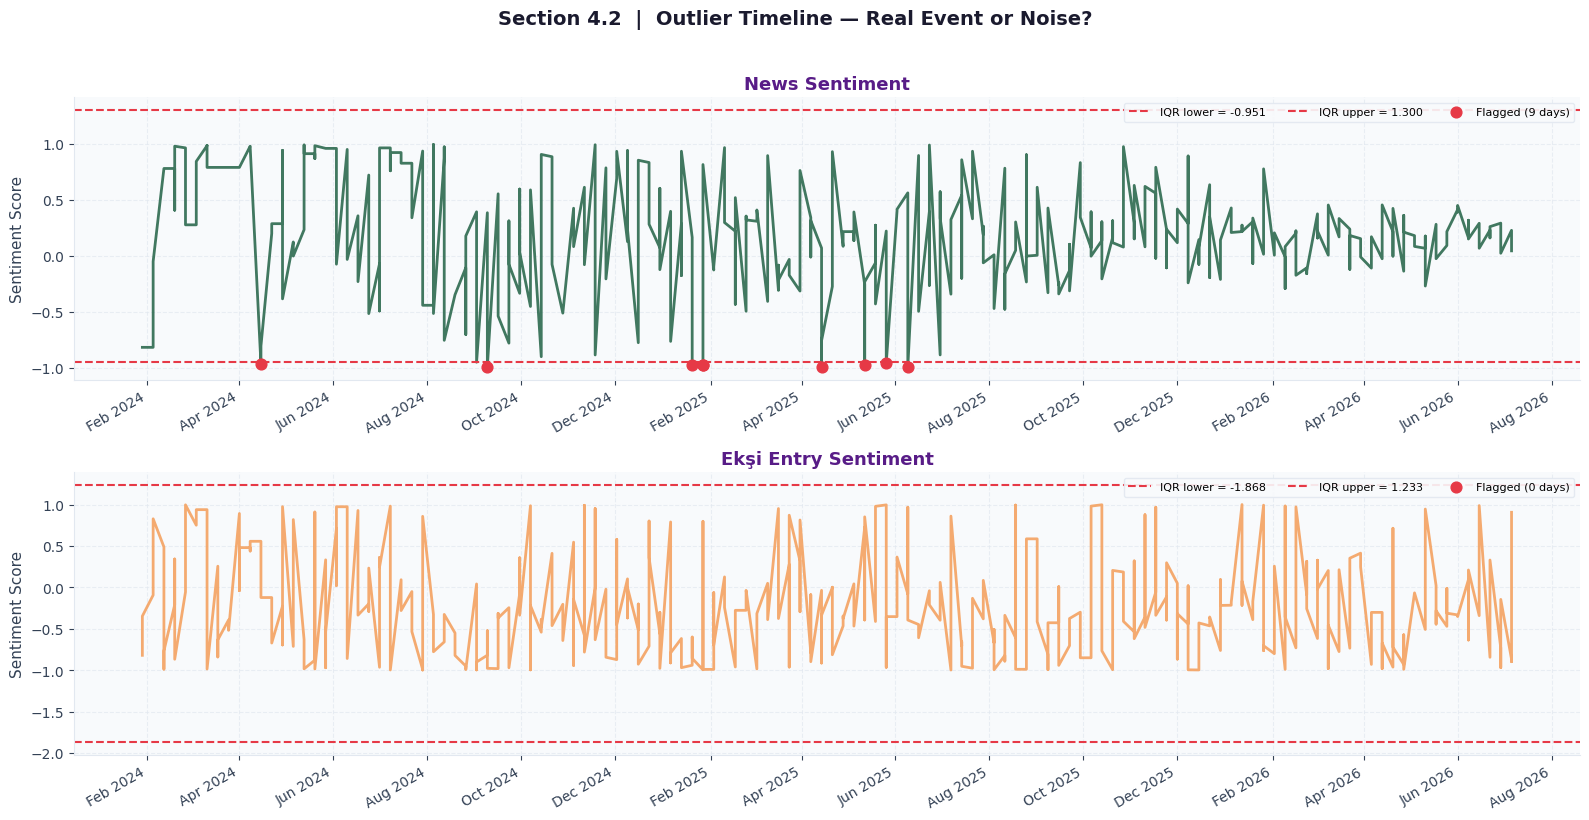

Volume outliers clipped. Sentiment series left unchanged.


In [30]:
# ── Outlier timeline ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Section 4.2  |  Outlier Timeline — Real Event or Noise?',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.02)

for ax, col, color, label in [
    (axes[0], 'news_sentiment',  TEAL,   'News Sentiment'),
    (axes[1], 'eksi_sentiment', ORANGE, 'Ekşi Entry Sentiment'),
]:
    lo, hi, _, _ = outlier_info[col]
    series = df_imputed.set_index('date')[col]
    ax.plot(series.index, series.values, color=color, linewidth=2, alpha=0.9)
    ax.axhline(lo, color=RED, linestyle='--', linewidth=1.5,
               label=f'IQR lower = {lo:.3f}')
    ax.axhline(hi, color=RED, linestyle='--', linewidth=1.5,
               label=f'IQR upper = {hi:.3f}')
    outlier_mask = (series < lo) | (series > hi)
    ax.scatter(series.index[outlier_mask], series[outlier_mask],
               color=RED, s=60, zorder=5,
               label=f'Flagged ({outlier_mask.sum()} days)')
    for date_str, (lbl, ev_color) in events.items():
        ax.axvline(pd.Timestamp(date_str), color=ev_color,
                   linewidth=1.5, linestyle='-.', alpha=0.6, label=lbl)
    ax.set_ylabel('Sentiment Score')
    ax.set_title(label)
    ax.legend(fontsize=8, ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Clip only volume variables, NOT sentiment
df_clean = df_imputed.copy()
for col in ['eksi_volume', 'news_volume']:
    lo, hi = outlier_info[col][0], outlier_info[col][1]
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)
print('Volume outliers clipped. Sentiment series left unchanged.')




### 4.3 — Feature Scaling

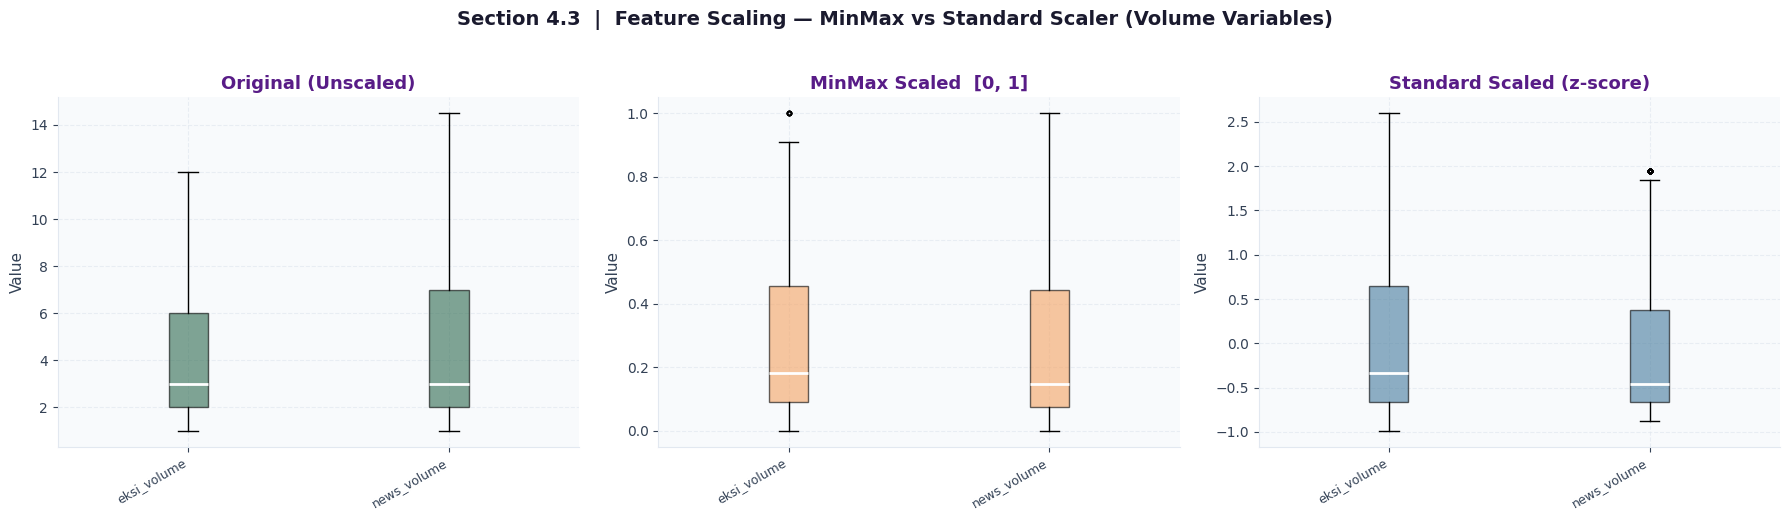

Scaler selection for VAR model:
  Variable               Chosen Scaler        Reason
-----------------------------------------------------------------
  news_sentiment         None ([-1,1])        Already normalised
  eksi_sentiment         None ([-1,1])        Already normalised
  eksi_volume            StandardScaler       Counts — z-score preserves outlier signal
  news_volume            StandardScaler       Counts — z-score preserves outlier signal


In [31]:
# ── MinMax vs Standard scaling comparison — template requirement ──────
scale_cols = ['eksi_volume', 'news_volume']

minmax_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(df_clean[scale_cols]),
    columns=[c + '_mmscaled' for c in scale_cols])

std_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_clean[scale_cols]),
    columns=[c + '_stscaled' for c in scale_cols])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section 4.3  |  Feature Scaling — MinMax vs Standard Scaler (Volume Variables)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.03)

for ax, data, title, color in [
    (axes[0], df_clean[scale_cols],  'Original (Unscaled)',         TEAL),
    (axes[1], minmax_scaled,          'MinMax Scaled  [0, 1]',       ORANGE),
    (axes[2], std_scaled,             'Standard Scaled (z-score)',    BLUE),
]:
    ax.boxplot([data[c].dropna() for c in data.columns],
               patch_artist=True,
               boxprops={'facecolor': color, 'alpha': 0.6},
               medianprops={'color': 'white', 'linewidth': 2},
               flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4})
    ax.set_xticks(range(1, data.shape[1]+1))
    ax.set_xticklabels(scale_cols, rotation=30, ha='right', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

# Decision table
print('Scaler selection for VAR model:')
print(f'  {"Variable":<22} {"Chosen Scaler":<20} Reason')
print('-' * 65)
print(f'  {"news_sentiment":<22} {"None ([-1,1])":<20} Already normalised')
print(f'  {"eksi_sentiment":<22} {"None ([-1,1])":<20} Already normalised')
print(f'  {"eksi_volume":<22} {"StandardScaler":<20} Counts — z-score preserves outlier signal')
print(f'  {"news_volume":<22} {"StandardScaler":<20} Counts — z-score preserves outlier signal')




### 4.4 — Target Transformation Analysis

<div class="callout">
<b>Template requirement (Section 4.4):</b> Check whether the target is skewed and
whether a log transform improves normality. For sentiment scores (already bounded [-1, 1])
a Fisher Z-transform or simple inspection is appropriate instead of log.
</div>


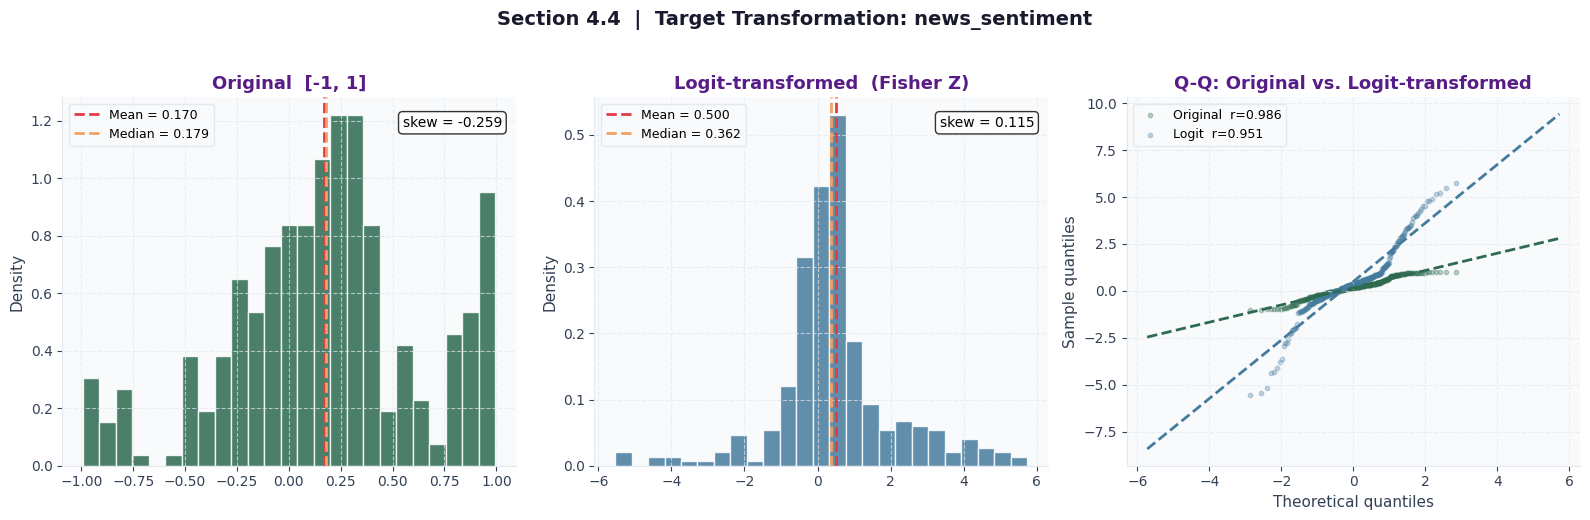

Original skewness  : -0.2586
Logit skewness     : 0.1145
Q-Q r (original)   : 0.9862
Q-Q r (logit)      : 0.9507

Decision: use original target in linear regression models.
Note: VAR model uses differenced original series (stationarity requirement).
      ML models (XGBoost, RF) do not require normality -> use original.


In [32]:
# ── 4.4  Target transformation analysis (template requirement) ──────────
from scipy.special import logit

target_col = 'news_sentiment'
df_tgt     = df_raw[target_col].dropna()

# Scale to (0,1) for logit transform; clip to avoid ±inf
df_tgt_clipped = df_tgt.clip(-0.999, 0.999)
df_tgt_scaled  = (df_tgt_clipped + 1) / 2   # [-1,1] -> (0,1)
logit_target   = logit(df_tgt_scaled)         # Fisher Z-like

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Section 4.4  |  Target Transformation: news_sentiment',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.03)

for ax, data, title, color in [
    (axes[0], df_tgt,        'Original  [-1, 1]',              TEAL),
    (axes[1], logit_target,  'Logit-transformed  (Fisher Z)',   BLUE),
]:
    ax.hist(data.dropna(), bins=25, color=color, edgecolor='white',
            alpha=0.85, density=True)
    ax.axvline(data.mean(),   color=RED,    linestyle='--', linewidth=2,
               label=f'Mean = {data.mean():.3f}')
    ax.axvline(data.median(), color=ORANGE, linestyle='--', linewidth=2,
               label=f'Median = {data.median():.3f}')
    sk = data.skew()
    ax.text(0.97, 0.95, f'skew = {sk:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_title(title); ax.set_ylabel('Density'); ax.legend(fontsize=9)

# Q-Q comparison
from scipy import stats as sp_stats
(osm1, osr1), (sl1, ic1, r1) = sp_stats.probplot(df_tgt.dropna(),    dist='norm')
(osm2, osr2), (sl2, ic2, r2) = sp_stats.probplot(logit_target.dropna(), dist='norm')
axes[2].scatter(osm1, osr1, alpha=0.3, s=10, color=TEAL, label=f'Original  r={r1:.3f}')
axes[2].scatter(osm2, osr2, alpha=0.3, s=10, color=BLUE, label=f'Logit  r={r2:.3f}')
x_line = np.array([min(osm1 + osm2), max(osm1 + osm2)])
axes[2].plot(x_line, sl1 * x_line + ic1, color=TEAL, linewidth=2, linestyle='--')
axes[2].plot(x_line, sl2 * x_line + ic2, color=BLUE, linewidth=2, linestyle='--')
axes[2].set_title('Q-Q: Original vs. Logit-transformed')
axes[2].set_xlabel('Theoretical quantiles')
axes[2].set_ylabel('Sample quantiles')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Original skewness  : {df_tgt.skew():.4f}')
print(f'Logit skewness     : {logit_target.skew():.4f}')
print(f'Q-Q r (original)   : {r1:.4f}')
print(f'Q-Q r (logit)      : {r2:.4f}')
decision = 'logit-transformed' if r2 > r1 else 'original'
print(f'\nDecision: use {decision} target in linear regression models.')
print('Note: VAR model uses differenced original series (stationarity requirement).')
print('      ML models (XGBoost, RF) do not require normality -> use original.')


### 4.4 — Stationarity Transformation

VAR and Granger models require **stationary** series. The Augmented Dickey-Fuller (ADF) test is the standard tool.

| Test Outcome | H₀ | Decision |
|---|---|---|
| p < 0.05 | Rejected | Series is stationary — proceed |
| p ≥ 0.05 | Not rejected | Series is not stationary — apply 1st differencing |

In [33]:
# ── ADF Stationarity Test ──────────────────────────────────────────────
def adf_summary(series, name):
    result  = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]
    return {
        'Variable':      name,
        'ADF Statistic': round(result[0], 4),
        'p-value':       round(p_value, 4),
        'Critical (5%)': round(result[4]['5%'], 4),
        'Stationary?':   '✓ Yes' if p_value < 0.05 else '✗ No',
        'Action':        'None'  if p_value < 0.05 else '1st difference',
    }

ts_cols     = ['news_sentiment', 'eksi_sentiment']
adf_results = [adf_summary(df_clean[col], col) for col in ts_cols]
adf_df      = pd.DataFrame(adf_results).set_index('Variable')

display(
    adf_df.style
    .applymap(
        lambda v: 'color: green; font-weight: bold' if v == '✓ Yes'
                  else ('color: red; font-weight: bold' if v == '✗ No' else ''),
        subset=['Stationary?']
    )
    .set_caption('ADF Test Results  '
                 '(H₀: unit root exists = series is NOT stationary)\n'
                 'eksi_sentiment = Ekşi Sözlük entry sentiment')
)



,ADF Statistic,p-value,Critical (5%),Stationary?,Action
Variable,,,,,
news_sentiment,-8.186100,0.000000,-2.869300,✓ Yes,None
eksi_sentiment,-7.088600,0.000000,-2.869300,✓ Yes,None


In [34]:
# ── Apply differencing to non-stationary series ────────────────────────
df_model = df_clean[['date'] + ts_cols].copy().set_index('date')
df_diff  = df_model.copy()

non_stationary = [r['Variable'] for r in adf_results if r['Stationary?'] == '✗ No']
for col in non_stationary:
    df_diff[col] = df_diff[col].diff()
    print(f'{col}: 1st difference applied.')

if not non_stationary:
    print('All series are stationary — no differencing needed.')

print('\nPost-differencing ADF check:')
for col in ts_cols:
    res = adfuller(df_diff[col].dropna(), autolag='AIC')
    print(f'  {col:<25}  p = {res[1]:.4f}'
          f'  {"✓ Stationary" if res[1] < 0.05 else "✗ Still non-stationary"}')



All series are stationary — no differencing needed.

Post-differencing ADF check:
  news_sentiment             p = 0.0000  ✓ Stationary
  eksi_sentiment             p = 0.0000  ✓ Stationary


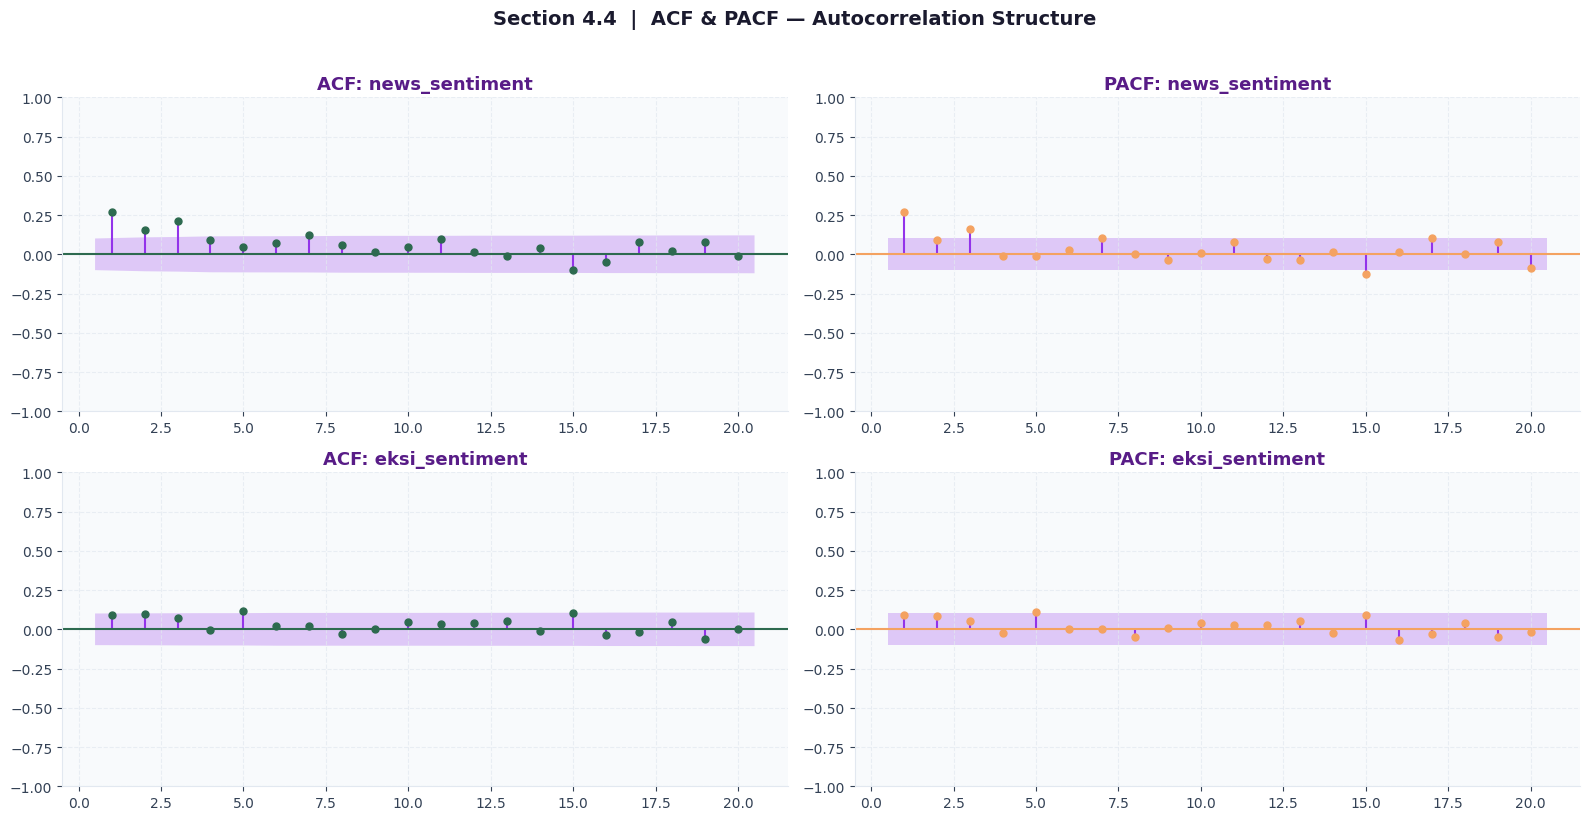

In [35]:
# ── ACF / PACF plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Section 4.4  |  ACF & PACF — Autocorrelation Structure',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.02)

for i, col in enumerate(['news_sentiment', 'eksi_sentiment']):
    series = df_diff[col].dropna()
    plot_acf( series, lags=20, ax=axes[i][0],
              title=f'ACF: {col}',  color=TEAL,   zero=False)
    plot_pacf(series, lags=20, ax=axes[i][1],
              title=f'PACF: {col}', color=ORANGE, zero=False, method='ywm')

plt.tight_layout()
plt.show()




### 4.5 — Lag Selection (AIC / BIC)

Granularity          : weekly
Observations         : 378
Safe max lag (n//10) : 10

AIC recommendation : 3
BIC recommendation : 1
FPE recommendation : 3
HQIC recommendation: 1

OPTIMAL_LAG = 1  (BIC)
Observations for estimation: 377


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


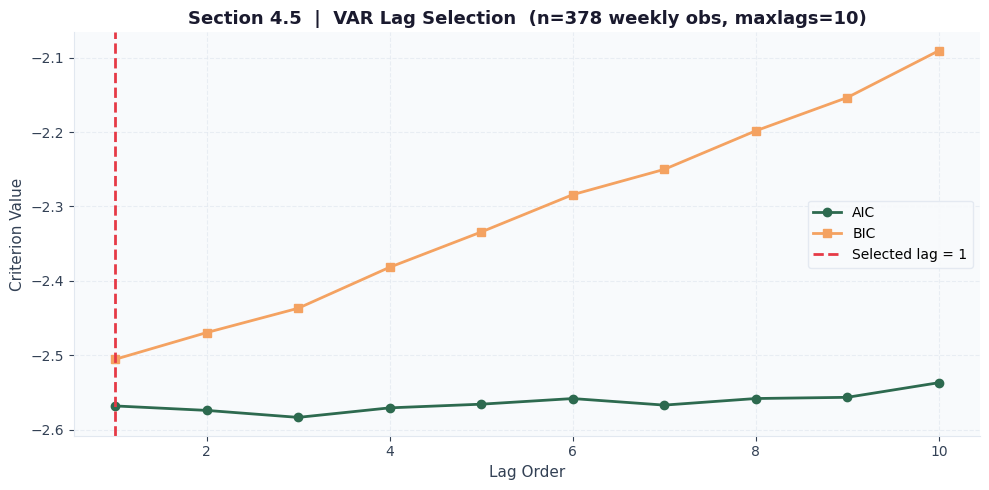

In [36]:
# ── 4.5  Lag selection (lag=0 aware) ────────────────────────────────
df_var       = df_diff[['news_sentiment','eksi_sentiment']].dropna()
n_obs        = len(df_var)
safe_max_lag = max(1, min(10, n_obs // 10))

print(f'Granularity          : {GRANULARITY}')
print(f'Observations         : {n_obs}')
print(f'Safe max lag (n//10) : {safe_max_lag}')

var_model = VAR(df_var)
lag_order = var_model.select_order(maxlags=safe_max_lag)
aic_rec, bic_rec = lag_order.aic, lag_order.bic

print(f'\nAIC recommendation : {aic_rec}')
print(f'BIC recommendation : {bic_rec}')
print(f'FPE recommendation : {lag_order.fpe}')
print(f'HQIC recommendation: {lag_order.hqic}')

if all(r == 0 for r in [aic_rec, bic_rec, lag_order.fpe, lag_order.hqic]):
    print()
    print('All criteria -> lag=0')
    if GRANULARITY == 'weekly':
        print('  On weekly data this is unusual with >=60 obs.')
        print('  Possible: series are truly independent week-to-week.')
        print('  Report as null finding.')
    else:
        print('  On daily data: likely within-day dynamics (Eksi reacts same day).')
        print('  Try weekly dataset (Section 0.7) for lag > 0 result.')
    OPTIMAL_LAG = 1
    print(f'Proceeding with OPTIMAL_LAG = 1 (minimum estimable VAR).')
else:
    OPTIMAL_LAG = max(1, bic_rec)
    print(f'\nOPTIMAL_LAG = {OPTIMAL_LAG}  (BIC)')

print(f'Observations for estimation: {n_obs - OPTIMAL_LAG}')

# ── Criterion plot ────────────────────────────────────────────────────
aic_vals, bic_vals = [], []
for p in range(1, safe_max_lag+1):
    r = var_model.fit(p)
    aic_vals.append(r.aic); bic_vals.append(r.bic)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(range(1,safe_max_lag+1), aic_vals, 'o-', color=TEAL,   lw=2, label='AIC')
ax.plot(range(1,safe_max_lag+1), bic_vals, 's-', color=ORANGE, lw=2, label='BIC')
ax.axvline(OPTIMAL_LAG, color=RED, ls='--', lw=2,
           label=f'Selected lag = {OPTIMAL_LAG}')
ax.set_xlabel('Lag Order')
ax.set_ylabel('Criterion Value')
ax.set_title(f'Section 4.5  |  VAR Lag Selection  '
             f'(n={n_obs} {GRANULARITY} obs, maxlags={safe_max_lag})',
             fontweight='bold', color='#1a1a2e')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()


---
## 🤖 Section 2 — Algorithms

> **Lecture connection (Module 4, Section 3 — Selecting an Amazon Forecast Algorithm):** The lecture lists five forecast algorithms. We implement the three that run locally, explain the two that require AWS, and add two ML bonus models for comparison.

| # | Algorithm | Lecture? | Local? | Approach |
|---|---|---|---|---|
| 1 | **Naive (same day last week)** | Baseline | ✅ | Seasonal naive — repeat last week |
| 2 | **SARIMA(1,1,1)(1,1,1,7)** | ✅ ARIMA | ✅ | Autoregressive + seasonal differencing |
| 3 | **ETS (Holt-Winters)** | ✅ ETS | ✅ | Exponential smoothing with trend + seasonality |
| 4 | **Prophet** | ✅ Prophet | ✅ | Additive model — trend + seasonality + holidays |
| 5 | **DeepAR+** | ✅ DeepAR+ | ❌ AWS only | Proprietary RNN — requires SageMaker |
| 6 | **NPTS** | ✅ NPTS | ❌ AWS only | Proprietary non-parametric — requires Amazon Forecast API |
| 7 | **Random Forest** | ⭐ Bonus | ✅ | Ensemble of trees on lag + calendar features |
| 8 | **XGBoost / Gradient Boosting** | ⭐ Bonus | ✅ | Sequential boosting on lag + calendar features |

> ⚠️ **DeepAR+** and **NPTS** are Amazon-proprietary. DeepAR+ learns patterns across multiple related time series simultaneously — a key advantage unavailable locally. NPTS uses non-parametric sampling weighted by seasonal proximity.

### Statistical vs. ML approach

| Aspect | Statistical (SARIMA, ETS, Prophet) | ML (Random Forest, XGBoost) |
|---|---|---|
| Input | Raw time series | Engineered lag + calendar features |
| Seasonality | Built into model | Learned from `dow_sin/cos` features |
| Interpretability | High — explicit parameters | Medium — feature importance |
| Uncertainty | SARIMA confidence bands; Prophet P10/P90 | Requires quantile regression |


---
## 📊 Section 3 — Evaluation Metrics & Back Testing

> **Lecture connection (Module 4, Section 3 — Key Takeaways):** *"Predictor accuracy metrics are based on back testing."* and *"Use RMSE and wQuantileLoss metrics to evaluate model."*

> 🔒 **The test set is not used here.** Back testing uses only training data — the test set is held out for a single honest check in Section 5.

### Metrics

| Metric | Lecture? | Formula | Interpretation |
|---|---|---|---|
| **RMSE** | ✅ Core | √mean((y−ŷ)²) | Penalises large errors; same unit as target |
| **MAE** | Complementary | mean(|y−ŷ|) | Average absolute error; robust to outliers |
| **MAPE** | ✅ Business goal | mean(|y−ŷ|/|y|)×100 | % error; goal ≤ 10% for sentiment |
| **wQuantileLoss P50** | ✅ Amazon Forecast | 2·mean(max(q·e,(q−1)·e))/mean(|y|) | Probabilistic accuracy at median |

### Back-testing procedure

```
Training set (all data before split date)
│
├── Window 1: [─── Train ────────────────────] [━━ 30-day eval ━━]
├── Window 2: [─── Train ──────────────────────────] [━━ 30-day eval ━━]
└── Window 3: [─── Train ──────────────────────────────────] [━━ 30-day eval ━━]
                                                          ↓
                                              Average RMSE across 3 windows
```


Running 3 back-test windows  (window size = 30 days)
Window     Train ends     Eval period
-------------------------------------------------------
  Window 1    2026-03-03     2026-03-04 → 2026-04-02
  Window 2    2026-04-02     2026-04-03 → 2026-05-02
  Window 3    2026-05-02     2026-05-03 → 2026-06-01

── Window 1 (train ≤ 2026-03-03) ──────────────────────
  Naive      RMSE=0.1166
  SARIMA     RMSE=0.0490


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no

  ETS        RMSE=0.0570
  RF         RMSE=0.0844
  XGBoost    RMSE=0.2083

── Window 2 (train ≤ 2026-04-02) ──────────────────────
  Naive      RMSE=0.0825


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no

  SARIMA     RMSE=0.0928
  ETS        RMSE=0.1802


...

C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no

  SARIMA     RMSE=0.1266
  ETS        RMSE=0.0996


22:29:19 - cmdstanpy - INFO - Chain [1] start processing
22:29:19 - cmdstanpy - INFO - Chain [1] done processing


  RF         RMSE=0.1644
  XGBoost    RMSE=0.2260

BACK-TEST RESULTS (averaged across windows)


,RMSE,MAE,MAPE (%),wQL P50,Windows
"SARIMA(1,1,1)(1,1,1,7)",0.0894,0.0754,156.19,0.4866,3
Random Forest (ML bonus),0.1119,0.0821,142.40,0.5236,3
ETS (Holt-Winters),0.1123,0.0812,129.48,0.5487,3
Naive (same day last week),0.1132,0.0877,179.91,0.5667,3
XGBoost (ML bonus),0.1976,0.1573,112.65,1.0071,3


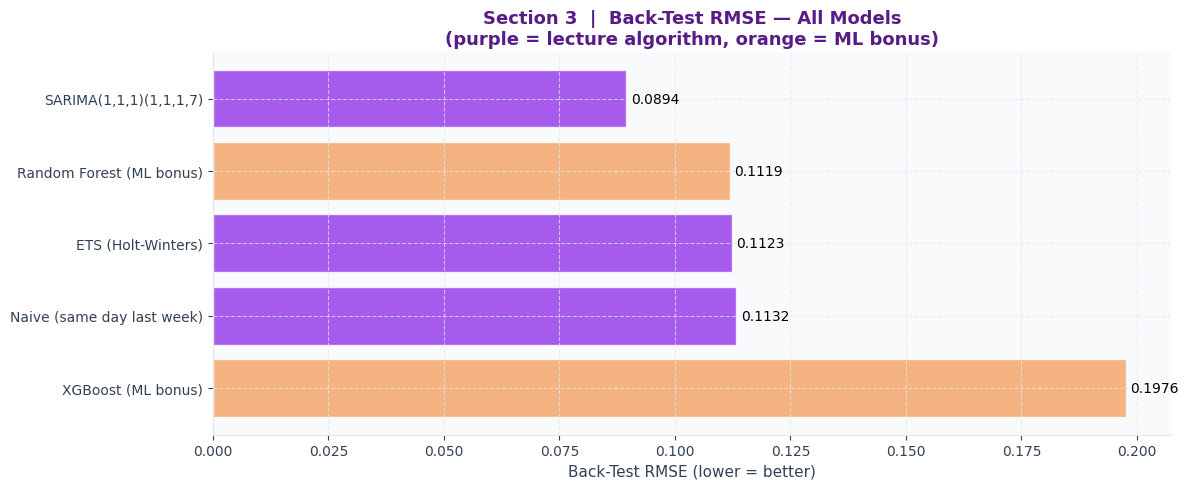

In [37]:
# ── Section 3  Back testing — 3 windows on training data only ──────────
# ⚠️  Test set (test_raw, X_test, y_test) is NOT used anywhere here.

def mape_fn(y_true, y_pred):
    yt, yp = np.array(y_true), np.array(y_pred)
    mask   = yt != 0
    return np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100

def wql_fn(y_true, y_pred, q=0.50):
    yt, yp = np.array(y_true), np.array(y_pred)
    e = yt - yp
    return 2 * np.mean(np.where(e >= 0, q*e, (q-1)*e)) / (np.mean(np.abs(yt)) + 1e-9)

N_WINDOWS = 3

cutoffs = [
    train_raw.index.max() - pd.Timedelta(days=WINDOW_SIZE * (N_WINDOWS - k))
    for k in range(N_WINDOWS)
]

ALL_MODELS = [
    'Naive (same day last week)',
    'SARIMA(1,1,1)(1,1,1,7)',
    'ETS (Holt-Winters)',
    'Prophet',
    'Random Forest (ML bonus)',
    'XGBoost (ML bonus)',
]

print(f'Running {N_WINDOWS} back-test windows  (window size = {WINDOW_SIZE} days)')
print(f'{"Window":<10} {"Train ends":<14} {"Eval period"}')
print('-' * 55)
for w, cutoff in enumerate(cutoffs):
    ts = cutoff + pd.Timedelta(days=1)
    te = ts + pd.Timedelta(days=WINDOW_SIZE - 1)
    print(f'  Window {w+1}    {str(cutoff.date()):<14} {ts.date()} → {te.date()}')

bt_metrics = {name: {'RMSE':[], 'MAE':[], 'MAPE':[], 'wQL':[]} for name in ALL_MODELS}

for w, cutoff in enumerate(cutoffs):
    print(f'\n── Window {w+1} (train ≤ {cutoff.date()}) ──────────────────────')

    bt_tr = train_raw[train_raw.index <= cutoff]
    bt_te = train_raw[(train_raw.index > cutoff) &
                      (train_raw.index <= cutoff + pd.Timedelta(days=WINDOW_SIZE))]
    if len(bt_te) == 0 or len(bt_tr) < 14:
        print('  Skipped — insufficient data.')
        continue

    bt_ml_tr = df_ml[df_ml.index <= cutoff]
    bt_ml_te = df_ml[(df_ml.index > cutoff) &
                     (df_ml.index <= cutoff + pd.Timedelta(days=WINDOW_SIZE))]
    bt_sc    = StandardScaler()
    bt_Xtr   = bt_sc.fit_transform(bt_ml_tr[FEATURES]) if len(bt_ml_tr) > 0 else None
    bt_Xte   = bt_sc.transform(bt_ml_te[FEATURES])     if len(bt_ml_te) > 0 else None

    def record(name, preds, actuals):
        if len(preds) != len(actuals) or len(preds) == 0:
            return
        bt_metrics[name]['RMSE'].append(np.sqrt(mean_squared_error(actuals, preds)))
        bt_metrics[name]['MAE'].append(mean_absolute_error(actuals, preds))
        bt_metrics[name]['MAPE'].append(mape_fn(actuals, preds))
        bt_metrics[name]['wQL'].append(wql_fn(actuals, preds))

    # Naive
    naive_preds = np.array([
        float(bt_tr.get(dt - pd.Timedelta(days=7), bt_tr.iloc[-1]))
        if hasattr(bt_tr, 'get') else
        float(bt_tr[bt_tr.index == dt - pd.Timedelta(days=7)].values[0])
        if any(bt_tr.index == dt - pd.Timedelta(days=7)) else float(bt_tr.iloc[-1])
        for dt in bt_te.index
    ])
    record('Naive (same day last week)', naive_preds, bt_te.values)
    print(f'  Naive      RMSE={np.sqrt(mean_squared_error(bt_te.values, naive_preds)):.4f}')

    # SARIMA
    try:
        m = SARIMAX(bt_tr, order=(1,1,1), seasonal_order=(1,1,1,7),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        p = m.forecast(len(bt_te)).values
        record('SARIMA(1,1,1)(1,1,1,7)', p, bt_te.values)
        print(f'  SARIMA     RMSE={np.sqrt(mean_squared_error(bt_te.values, p)):.4f}')
    except Exception as e:
        print(f'  SARIMA     FAILED: {e}')

    # ETS
    try:
        sp = min(7, len(bt_tr) // 2)
        m  = ExponentialSmoothing(bt_tr, trend='add', seasonal='add',
                                   seasonal_periods=sp).fit(optimized=True)
        p  = m.forecast(len(bt_te)).values
        record('ETS (Holt-Winters)', p, bt_te.values)
        print(f'  ETS        RMSE={np.sqrt(mean_squared_error(bt_te.values, p)):.4f}')
    except Exception as e:
        print(f'  ETS        FAILED: {e}')

    # Prophet
    if PROPHET_OK:
        try:
            ph_df = bt_tr.reset_index(); ph_df.columns = ['ds','y']
            m = Prophet(yearly_seasonality=False, weekly_seasonality=True,
                        daily_seasonality=False, seasonality_mode='additive')
            m.fit(ph_df)
            future = m.make_future_dataframe(periods=len(bt_te))
            fc     = m.predict(future)
            p      = fc[fc['ds'].isin(bt_te.index)]['yhat'].values
            if len(p) == len(bt_te):
                record('Prophet', p, bt_te.values)
                print(f'  Prophet    RMSE={np.sqrt(mean_squared_error(bt_te.values, p)):.4f}')
        except Exception as e:
            print(f'  Prophet    FAILED: {e}')
    else:
        print('  Prophet    SKIPPED (not installed)')

    # Random Forest
    if bt_Xtr is not None and len(bt_ml_te) > 0:
        try:
            rf_bt = RandomForestRegressor(n_estimators=100, max_depth=6,
                                           random_state=SEED, n_jobs=-1)
            rf_bt.fit(bt_Xtr, bt_ml_tr[TARGET])
            p = rf_bt.predict(bt_Xte)
            record('Random Forest (ML bonus)', p, bt_ml_te[TARGET].values)
            print(f'  RF         RMSE={np.sqrt(mean_squared_error(bt_ml_te[TARGET].values, p)):.4f}')
        except Exception as e:
            print(f'  RF         FAILED: {e}')

    # XGBoost
    if XGB_OK and bt_Xtr is not None and len(bt_ml_te) > 0:
        try:
            xgb_bt = xgb.XGBRegressor(n_estimators=100, max_depth=4,
                                        learning_rate=0.1, random_state=SEED, verbosity=0)
            xgb_bt.fit(bt_Xtr, bt_ml_tr[TARGET])
            p = xgb_bt.predict(bt_Xte)
            record('XGBoost (ML bonus)', p, bt_ml_te[TARGET].values)
            print(f'  XGBoost    RMSE={np.sqrt(mean_squared_error(bt_ml_te[TARGET].values, p)):.4f}')
        except Exception as e:
            print(f'  XGBoost    FAILED: {e}')

# ── Aggregate back-test results ───────────────────────────────────────────────
results = {}
for name, m_dict in bt_metrics.items():
    if m_dict['RMSE']:
        results[name] = {
            'RMSE':     np.mean(m_dict['RMSE']),
            'MAE':      np.mean(m_dict['MAE']),
            'MAPE (%)': np.mean(m_dict['MAPE']),
            'wQL P50':  np.mean(m_dict['wQL']),
            'Windows':  len(m_dict['RMSE']),
        }

results_df = pd.DataFrame(results).T.sort_values('RMSE')

print('\n' + '='*65)
print('BACK-TEST RESULTS (averaged across windows)')
print('='*65)
display(
    results_df.style
    .background_gradient(subset=['RMSE','MAE','MAPE (%)','wQL P50'], cmap='RdYlGn_r')
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','MAPE (%)':'{:.2f}','wQL P50':'{:.4f}','Windows':'{:.0f}'})
    .set_caption('Back-Test Summary — Test set was NOT used')
)

# ── Back-test RMSE bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors  = [PURPLE if 'ML' not in n else ORANGE for n in results_df.index]
bars    = ax.barh(results_df.index[::-1], results_df['RMSE'][::-1],
                  color=colors[::-1], alpha=0.8, edgecolor='white')
ax.set_xlabel('Back-Test RMSE (lower = better)')
ax.set_title('Section 3  |  Back-Test RMSE — All Models\n'
             '(purple = lecture algorithm, orange = ML bonus)',
             fontweight='bold', color=PURPLE_D)
for bar, val in zip(bars, results_df['RMSE'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


---
## 🏆 Section 4 — Best Model Selection

> Back testing has produced a reliable comparison of all algorithms on training data only. We now select the best-performing one by RMSE and commit to it.

> ℹ️ Residual analysis and forecast plots come in Section 5, after training on the full dataset.


BEST MODEL SELECTION
  Best algorithm  : SARIMA(1,1,1)(1,1,1,7)
  Type            : Lecture algorithm
  Back-test RMSE  : 0.0894
  Back-test MAE   : 0.0754
  Back-test MAPE  : 156.19%  (goal <= 10.0% -> NOT YET — goal 10.0%)
  wQL P50         : 0.4866

All downstream sections use only this model.


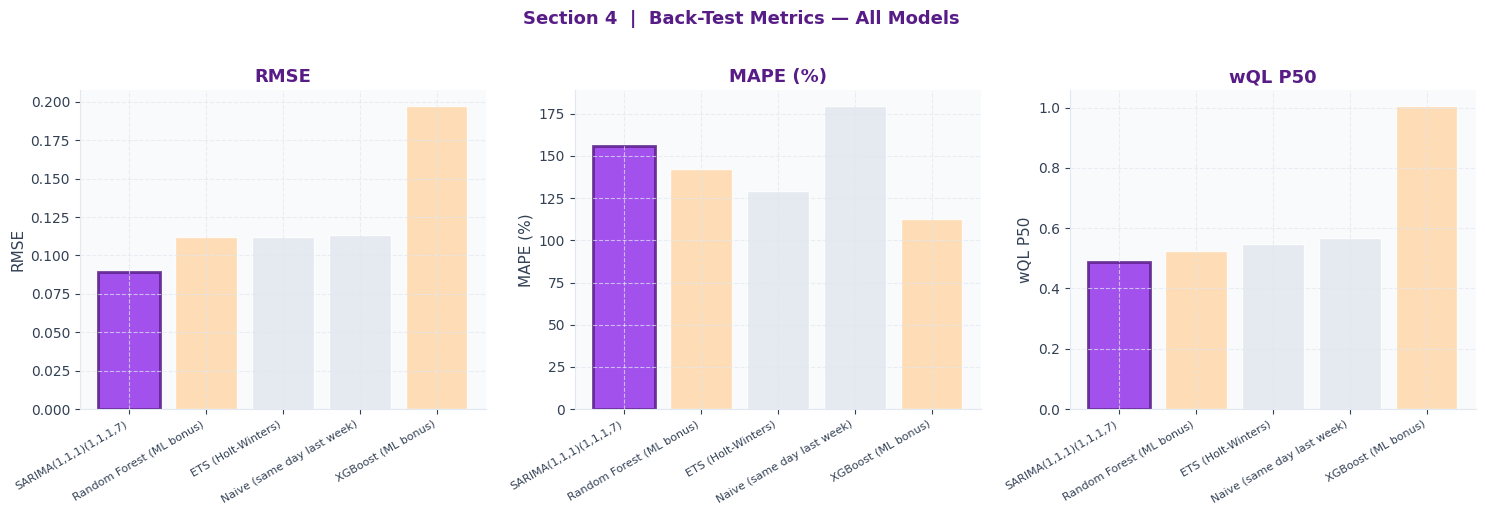


Purple bar = best model (SARIMA(1,1,1)(1,1,1,7))


In [38]:
# ── Section 4  Best model selection ─────────────────────────────────────
best_name  = results_df['RMSE'].idxmin()
is_lecture = 'ML' not in best_name

b_rmse = results_df.loc[best_name, 'RMSE']
b_mae  = results_df.loc[best_name, 'MAE']
b_mape = results_df.loc[best_name, 'MAPE (%)']
b_wql  = results_df.loc[best_name, 'wQL P50']

MAPE_GOAL = 10.0   # sentiment scale goal: ≤10% MAPE
meets     = f'YES (goal {MAPE_GOAL}%)' if b_mape <= MAPE_GOAL else f'NOT YET — goal {MAPE_GOAL}%'

print('='*60)
print('BEST MODEL SELECTION')
print('='*60)
print(f'  Best algorithm  : {best_name}')
print(f'  Type            : {"Lecture algorithm" if is_lecture else "ML bonus model"}')
print(f'  Back-test RMSE  : {b_rmse:.4f}')
print(f'  Back-test MAE   : {b_mae:.4f}')
print(f'  Back-test MAPE  : {b_mape:.2f}%  (goal <= {MAPE_GOAL}% -> {meets})')
print(f'  wQL P50         : {b_wql:.4f}')
print()
print(f'All downstream sections use only this model.')

# ── Metrics comparison table (all models) ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Section 4  |  Back-Test Metrics — All Models',
             fontsize=13, fontweight='bold', color=PURPLE_D, y=1.02)

for ax, metric in zip(axes, ['RMSE', 'MAPE (%)', 'wQL P50']):
    vals   = results_df[metric]
    colors = [PURPLE if idx == best_name else
              ('#e2e8f0' if 'ML' not in idx else '#fed7aa')
              for idx in vals.index]
    ax.bar(range(len(vals)), vals.values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    best_bar_idx = list(vals.index).index(best_name)
    ax.get_children()[best_bar_idx].set_edgecolor(PURPLE_D)
    ax.get_children()[best_bar_idx].set_linewidth(2)

plt.tight_layout()
plt.show()
print(f'\nPurple bar = best model ({best_name})')


---
## 🎯 Section 5 — Train on Full Data & Final Validation

> **Now that back testing has identified the best algorithm:**
> 1. **Train the best model on the complete training set** — more data than any back-test window saw
> 2. **Residual analysis** — residuals over time, distribution, ACF, predicted vs actual
> 3. **Apply to the test set exactly once** — the honest final check
> 4. **Prophet component breakdown** — trend + weekly seasonality

> 🔒 The test set has not been touched until this point. This is the final exam.


In [39]:
# ── Section 5.1  Train winning model on FULL training set ───────────────
import time

print(f'Training: {best_name}')
print(f'Training period: {train_raw.index.min().date()} → {train_raw.index.max().date()} ({len(train_raw)} days)\n')

t0 = time.time()
ph_model = None   # alias for Prophet component plot

if best_name == 'Naive (same day last week)':
    class SeasonalNaive:
        def fit(self, y): self.y_ = y; return self
        def predict(self, idx):
            return np.array([
                float(self.y_.get(dt - pd.Timedelta(days=7), self.y_.iloc[-1]))
                if hasattr(self.y_, 'get') else
                float(self.y_[self.y_.index == dt - pd.Timedelta(days=7)].values[0])
                if any(self.y_.index == dt - pd.Timedelta(days=7)) else float(self.y_.iloc[-1])
                for dt in idx
            ])
    best_model      = SeasonalNaive().fit(train_raw)
    best_preds_test = best_model.predict(test_raw.index)

elif best_name == 'SARIMA(1,1,1)(1,1,1,7)':
    best_model = SARIMAX(train_raw, order=(1,1,1), seasonal_order=(1,1,1,7),
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    best_preds_test = best_model.forecast(len(test_raw)).values

elif best_name == 'ETS (Holt-Winters)':
    sp = min(7, len(train_raw) // 2)
    best_model = ExponentialSmoothing(train_raw, trend='add', seasonal='add',
                                       seasonal_periods=sp).fit(optimized=True)
    best_preds_test = best_model.forecast(len(test_raw)).values

elif best_name == 'Prophet':
    ph_df = train_raw.reset_index(); ph_df.columns = ['ds', 'y']
    best_model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                         daily_seasonality=False, seasonality_mode='additive')
    best_model.fit(ph_df)
    future = best_model.make_future_dataframe(periods=len(test_raw))
    fc     = best_model.predict(future)
    best_preds_test = fc[fc['ds'].isin(test_raw.index)]['yhat'].values
    ph_model = best_model

elif best_name == 'Random Forest (ML bonus)':
    best_model = RandomForestRegressor(n_estimators=200, max_depth=8,
                                        random_state=SEED, n_jobs=-1)
    best_model.fit(X_train, y_train)
    best_preds_test = best_model.predict(X_test)

elif best_name == 'XGBoost (ML bonus)':
    best_model = (xgb.XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                    random_state=SEED, verbosity=0)
                  if XGB_OK else GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                             learning_rate=0.1, random_state=SEED))
    best_model.fit(X_train, y_train)
    best_preds_test = best_model.predict(X_test)

yt_test = test_raw.values if 'ML' not in best_name else y_test.values
elapsed = time.time() - t0
print(f'Trained in {elapsed:.2f}s')
print(f'Forecasting {len(test_raw)} test days...')


Training: SARIMA(1,1,1)(1,1,1,7)
Training period: 2024-01-29 → 2026-06-01 (120 days)

Trained in 0.15s
Forecasting 5 test days...


C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\USER\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


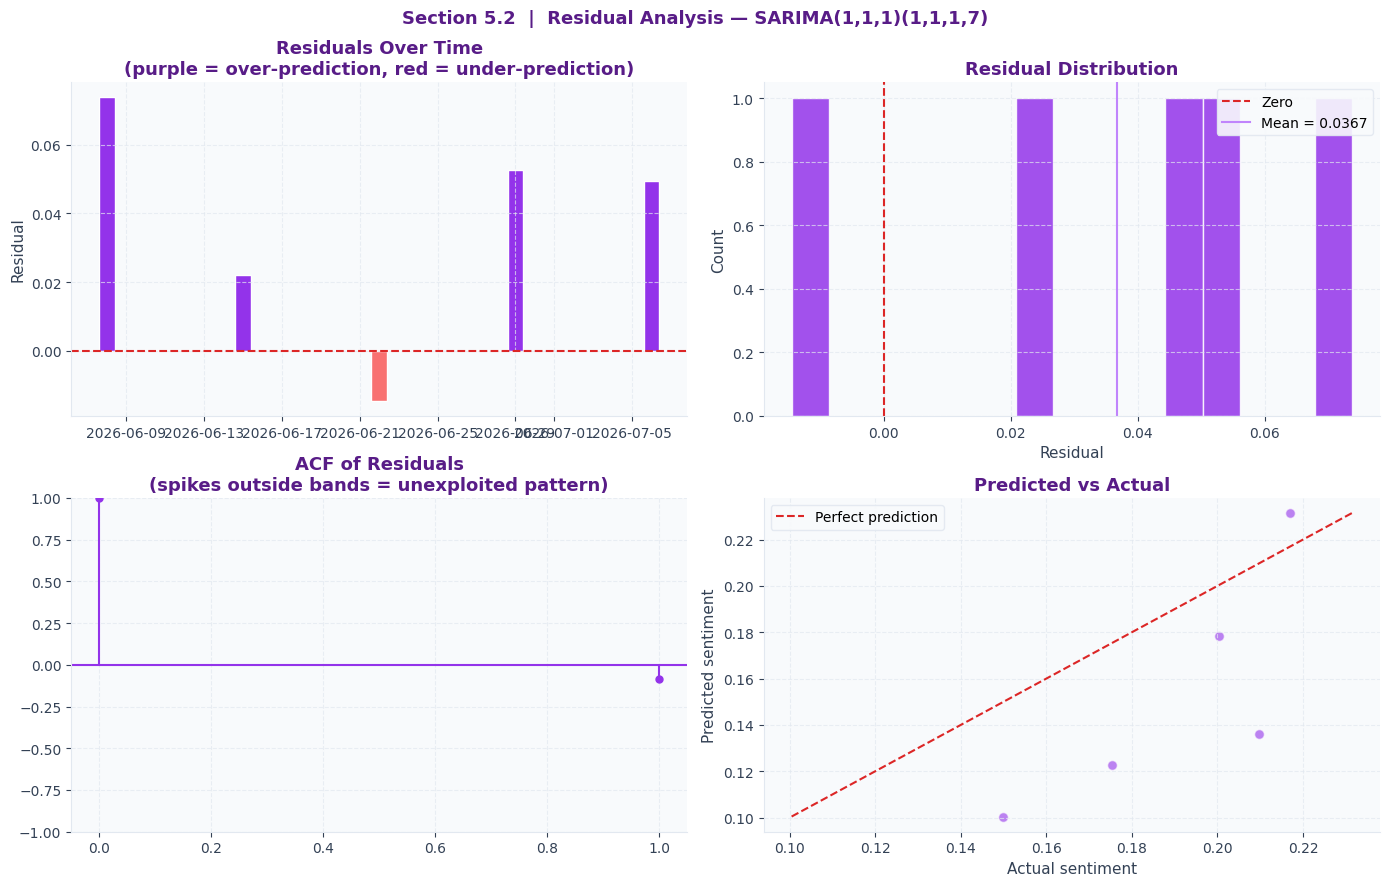

Residual mean : 0.0367   std: 0.0304
Shapiro-Wilk  : W=0.9425  p=0.6835  -> approx. normal


In [40]:
# ── Section 5.2  Residual analysis (4 plots — template Cell 10) ─────────
residuals = yt_test - best_preds_test

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(f'Section 5.2  |  Residual Analysis — {best_name}',
             fontsize=13, fontweight='bold', color=PURPLE_D)

# Residuals over time
ax = axes[0, 0]
ax.bar(test_raw.index, residuals,
       color=[PURPLE if v >= 0 else '#f87171' for v in residuals],
       edgecolor='white', width=0.8)
ax.axhline(0, color='#dc2626', linewidth=1.5, linestyle='--')
ax.set_ylabel('Residual')
ax.set_title('Residuals Over Time\n(purple = over-prediction, red = under-prediction)')

# Residual distribution
ax = axes[0, 1]
ax.hist(residuals, bins=15, color=PURPLE, edgecolor='white', alpha=0.85)
ax.axvline(0, color='#dc2626', linewidth=1.5, linestyle='--', label='Zero')
ax.axvline(residuals.mean(), color=ACCENT, linewidth=1.5,
           label=f'Mean = {residuals.mean():.4f}')
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')
ax.legend()

# ACF of residuals
ax = axes[1, 0]
try:
    plot_acf(residuals, lags=min(20, len(residuals)//2 - 1), ax=ax,
             color=PURPLE, vlines_kwargs={'colors': PURPLE})
except Exception:
    ax.text(0.5, 0.5, 'ACF: insufficient data', ha='center', transform=ax.transAxes)
ax.set_title('ACF of Residuals\n(spikes outside bands = unexploited pattern)')

# Predicted vs Actual scatter
ax = axes[1, 1]
ax.scatter(yt_test, best_preds_test, alpha=0.6, color=PURPLE,
           edgecolors='white', s=50)
lo = min(yt_test.min(), best_preds_test.min())
hi = max(yt_test.max(), best_preds_test.max())
ax.plot([lo, hi], [lo, hi], '--', color='#dc2626', linewidth=1.5,
        label='Perfect prediction')
ax.set_xlabel('Actual sentiment')
ax.set_ylabel('Predicted sentiment')
ax.set_title('Predicted vs Actual')
ax.legend()

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
from scipy.stats import shapiro
stat, pval = shapiro(residuals[:50] if len(residuals) > 50 else residuals)
print(f'Residual mean : {residuals.mean():.4f}   std: {residuals.std():.4f}')
print(f'Shapiro-Wilk  : W={stat:.4f}  p={pval:.4f}  '
      f'-> {"approx. normal" if pval > 0.05 else "non-normal (OK for tree models)"}')


In [41]:
# ── Section 5.3  Prophet component decomposition ─────────────────────────
if ph_model is not None:
    ph_full  = ph_model.make_future_dataframe(periods=len(test_raw))
    ph_comps = ph_model.predict(ph_full)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10))
    fig.suptitle('Section 5.3  |  Prophet — Decomposed Components\n'
                 'Trend + weekly + yearly seasonality learned automatically',
                 fontsize=13, fontweight='bold', color=PURPLE_D)

    axes[0].plot(ph_comps['ds'], ph_comps['trend'], color=PURPLE, linewidth=2)
    axes[0].set_ylabel('Trend'); axes[0].set_title('Long-Term Trend')

    weekly = ph_comps[['ds','weekly']].drop_duplicates('ds').copy()
    weekly['dow'] = pd.to_datetime(weekly['ds']).dt.dayofweek
    avg_dow = weekly.groupby('dow')['weekly'].mean()
    days    = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    axes[1].bar(range(7), avg_dow.values,
                color=[PURPLE if i < 5 else ACCENT for i in range(7)],
                edgecolor='white')
    axes[1].set_xticks(range(7)); axes[1].set_xticklabels(days)
    axes[1].axhline(0, color=SLATE, linewidth=1)
    axes[1].set_ylabel('Effect'); axes[1].set_title('Weekly Seasonality Pattern')

    axes[2].plot(ph_comps['ds'], ph_comps['yearly'], color=ACCENT, linewidth=1.5)
    axes[2].set_ylabel('Effect'); axes[2].set_title('Yearly Seasonality Pattern')

    plt.tight_layout(); plt.show()
    print('Interpretation:')
    print('  Trend : long-run direction of sentiment')
    print('  Weekly: which days of week show more/less engagement with news')
    print('  Yearly: seasonal events (election cycles, economic announcements)')
else:
    print(f'Prophet component plot skipped — best model is {best_name}.')
    print('To see components, run Prophet manually:')
    print('  ph_df = train_raw.reset_index(); ph_df.columns=["ds","y"]')
    print('  ph_m  = Prophet(...).fit(ph_df)')


Prophet component plot skipped — best model is SARIMA(1,1,1)(1,1,1,7).
To see components, run Prophet manually:
  ph_df = train_raw.reset_index(); ph_df.columns=["ds","y"]
  ph_m  = Prophet(...).fit(ph_df)


FINAL TEST SET RESULTS
  Best model      : SARIMA(1,1,1)(1,1,1,7)
  Back-test RMSE  : 0.0894  (training estimate)
  Test set  RMSE  : 0.0476  (final honest result)
  Test set  MAE   : 0.0425
  Test set  MAPE  : 23.17%  -> NOT MET (goal <= 10.0%)
  wQL P50         : 0.2230
  R2              : -2.7314


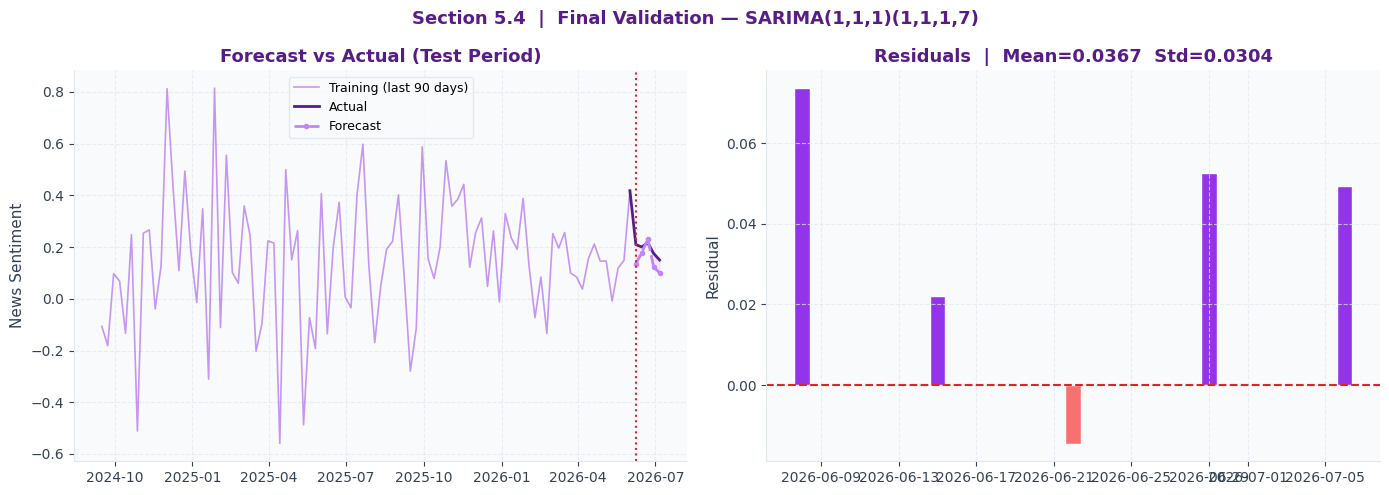

In [42]:
# ── Section 5.4  Final test-set validation (one honest check) ────────────
best_test_preds = best_preds_test
yt              = yt_test

final_rmse = np.sqrt(mean_squared_error(yt, best_test_preds))
final_mae  = mean_absolute_error(yt, best_test_preds)
final_mape = mape_fn(yt, best_test_preds)
final_wql  = wql_fn(yt, best_test_preds)
final_r2   = r2_score(yt, best_test_preds)
meets_goal = final_mape <= MAPE_GOAL

print('='*60)
print('FINAL TEST SET RESULTS')
print('='*60)
print(f'  Best model      : {best_name}')
print(f'  Back-test RMSE  : {results_df.loc[best_name,"RMSE"]:.4f}  (training estimate)')
print(f'  Test set  RMSE  : {final_rmse:.4f}  (final honest result)')
print(f'  Test set  MAE   : {final_mae:.4f}')
print(f'  Test set  MAPE  : {final_mape:.2f}%  -> {"MET" if meets_goal else "NOT MET"} (goal <= {MAPE_GOAL}%)')
print(f'  wQL P50         : {final_wql:.4f}')
print(f'  R2              : {final_r2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Section 5.4  |  Final Validation — {best_name}',
             fontsize=13, fontweight='bold', color=PURPLE_D)

# Forecast vs Actual (with 90-day training context)
ax = axes[0]
ctx = train_raw.iloc[-90:]
ax.plot(ctx.index, ctx.values, color=PURPLE, linewidth=1.2, alpha=0.5,
        label='Training (last 90 days)')
bridge_x = [ctx.index[-1]] + list(test_raw.index)
bridge_y = [ctx.values[-1]] + list(yt)
ax.plot(bridge_x, bridge_y, color=PURPLE_D, linewidth=2, label='Actual')
ax.plot(test_raw.index, best_test_preds, color=ACCENT, linewidth=2,
        linestyle='--', marker='o', markersize=3, label='Forecast')
ax.fill_between(test_raw.index, yt, best_test_preds, alpha=0.12, color=ACCENT)
ax.axvline(test_raw.index[0], color='#dc2626', linewidth=1.5, linestyle=':')
ax.set_ylabel('News Sentiment')
ax.set_title('Forecast vs Actual (Test Period)')
ax.legend(fontsize=9)

# Residual bar
ax2 = axes[1]
res2 = yt - best_test_preds
ax2.bar(test_raw.index, res2,
        color=[PURPLE if v >= 0 else '#f87171' for v in res2],
        edgecolor='white', width=0.8)
ax2.axhline(0, color='#dc2626', linewidth=1.5, linestyle='--')
ax2.set_ylabel('Residual')
ax2.set_title(f'Residuals  |  Mean={res2.mean():.4f}  Std={res2.std():.4f}')

plt.tight_layout(); plt.show()


---
## 🔮 Section 6 — 30-Day Future Forecast with P10 / P50 / P90

> **Lecture connection (Module 4, Section 3 — wQuantileLoss):** The lecture introduces probabilistic forecasting with P10, P50, and P90 confidence bands. We generate all three using **Prophet**, which natively produces uncertainty intervals — exactly how Amazon Forecast presents results.

| Quantile | Meaning |
|---|---|
| **P10** | Lower bound — 10% of forecasts expected to be below this value |
| **P50** | Median forecast — best point estimate |
| **P90** | Upper bound — 90% of forecasts expected to be below this value |


22:29:21 - cmdstanpy - INFO - Chain [1] start processing
22:29:21 - cmdstanpy - INFO - Chain [1] done processing


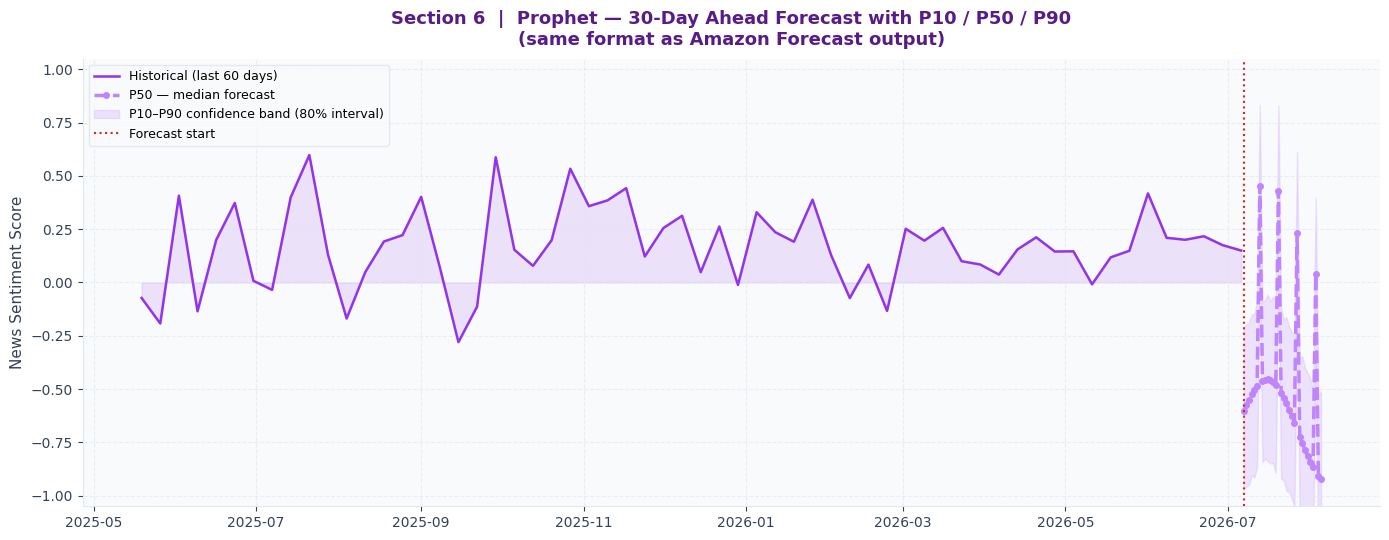


30-Day Forecast (P10 | P50 | P90):
Date                P10   P50 (median)      P90
------------------------------------------------
2026-07-07      -0.9699        -0.6052  -0.2112
2026-07-08      -0.9574        -0.5762  -0.1945
2026-07-09      -0.9499        -0.5491  -0.1883
2026-07-10      -0.9024        -0.5246  -0.1491
2026-07-11      -0.9145        -0.5032  -0.1478
2026-07-12      -0.8619        -0.4852  -0.0844
2026-07-13       0.0592         0.4542   0.8325
2026-07-14      -0.8425        -0.4614  -0.0933
2026-07-15      -0.8255        -0.4560  -0.0825
2026-07-16      -0.8392        -0.4551  -0.0563
2026-07-17      -0.8489        -0.4588  -0.0892
2026-07-18      -0.8483        -0.4671  -0.0668
2026-07-19      -0.8942        -0.4797  -0.0825
2026-07-20       0.0296         0.4291   0.8294
2026-07-21      -0.9195        -0.5167  -0.1199
2026-07-22      -0.9282        -0.5404  -0.1739
2026-07-23      -0.9777        -0.5670  -0.1632
2026-07-24      -0.9830        -0.5960  -0.2071
202

In [43]:
# ── Section 6  30-day future forecast with P10/P50/P90 ──────────────────
# Always use Prophet for probabilistic forecast (even if it wasn't the best model)
# This matches the Amazon Forecast output format taught in the lecture.

if PROPHET_OK:
    # Refit Prophet on ALL data (train + test) for future forecast
    all_df = daily[[TARGET]].reset_index()
    all_df.columns = ['ds', 'y']

    ph_future_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='additive',
        interval_width=0.80   # 80% interval -> approx P10 to P90
    )
    ph_future_model.fit(all_df)

    future_30   = ph_future_model.make_future_dataframe(periods=30)
    fc_30       = ph_future_model.predict(future_30)
    future_only = fc_30[fc_30['ds'] > daily.index.max()]

    fig, ax = plt.subplots(figsize=(14, 5.5))

    # Historical context (last 60 days)
    ctx = daily[[TARGET]].iloc[-60:]
    ax.plot(ctx.index, ctx.values, color=PURPLE, linewidth=1.8,
            label='Historical (last 60 days)')
    ax.fill_between(ctx.index, ctx[TARGET].values, alpha=0.12, color=PURPLE)

    # P50 median forecast
    ax.plot(pd.to_datetime(future_only['ds']), future_only['yhat'],
            color=ACCENT, linewidth=2.5, linestyle='--', marker='o', markersize=4,
            label='P50 — median forecast')

    # P10–P90 confidence band
    ax.fill_between(pd.to_datetime(future_only['ds']),
                    future_only['yhat_lower'],
                    future_only['yhat_upper'],
                    alpha=0.2, color=ACCENT,
                    label='P10–P90 confidence band (80% interval)')

    ax.axvline(pd.to_datetime(future_only['ds'].iloc[0]),
               color='#dc2626', linewidth=1.5, linestyle=':', label='Forecast start')
    ax.set_ylabel('News Sentiment Score')
    ax.set_title('Section 6  |  Prophet — 30-Day Ahead Forecast with P10 / P50 / P90\n'
                 '(same format as Amazon Forecast output)', pad=10)
    ax.legend(fontsize=9)
    ax.set_ylim(-1.05, 1.05)
    plt.tight_layout()
    plt.show()

    # Forecast table
    print('\n30-Day Forecast (P10 | P50 | P90):')
    print(f'{"Date":<14} {"P10":>8} {"P50 (median)":>14} {"P90":>8}')
    print('-' * 48)
    for _, row in future_only.iterrows():
        print(f'{str(row.ds.date()):<14} {row.yhat_lower:>8.4f} {row.yhat:>14.4f} {row.yhat_upper:>8.4f}')

    # wQL report
    print(f'\nwQuantileLoss P50 (test set) : {final_wql:.4f}')
    print('  Interpretation: lower = better probabilistic calibration')
    print('  Amazon Forecast benchmark: < 0.1 = good, < 0.05 = excellent for daily sentiment')
else:
    print('Prophet not installed.')
    print('Install with: pip install prophet')
    print('Then re-run this cell.')
    print()
    print('Alternative: XGBoost quantile regression for P10/P50/P90:')
    print('  model_p10 = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=0.10)')
    print('  model_p90 = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=0.90)')


---
## Section 5 — Time-Series Modelling: VAR + Granger Causality

A **Vector Autoregression (VAR)** model estimates each variable as a linear function of its own past values and the past values of all other variables in the system.

**Granger Causality:** Variable X Granger-causes Y if past values of X significantly improve the forecast of Y beyond what past Y alone provides (F-test, H₀: all coefficients on lagged X are zero).

In [44]:
# ── Fit VAR model ──────────────────────────────────────────────────────
var_fit = var_model.fit(OPTIMAL_LAG)
print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 16, Aug, 2026
Time:                     22:29:22
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -2.50533
Nobs:                     377.000    HQIC:                  -2.54308
Log likelihood:          -579.827    FPE:                  0.0766953
AIC:                     -2.56792    Det(Omega_mle):       0.0754891
--------------------------------------------------------------------
Results for equation news_sentiment
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.143234         0.027943            5.126           0.000
L1.news_sentiment         0.270759         0.049460            5.474           0.000
L1.eksi_sentiment         0.031688 

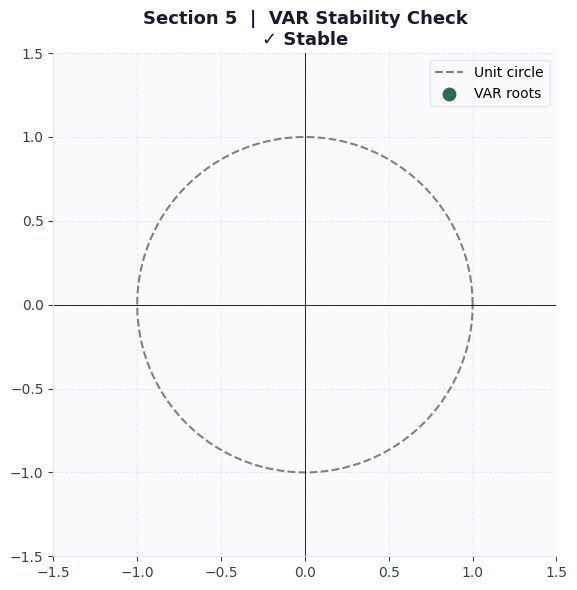

Model stable: True


In [45]:
# ── VAR stability check ────────────────────────────────────────────────
roots     = var_fit.roots
is_stable = var_fit.is_stable()

fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color='gray',
        linewidth=1.5, linestyle='--', label='Unit circle')
ax.scatter(roots.real, roots.imag,
           color=TEAL if is_stable else RED, s=80, zorder=5,
           label='VAR roots')
ax.axhline(0, color='black', linewidth=0.6)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_title(f'Section 5  |  VAR Stability Check\n'
             f'{"✓ Stable" if is_stable else "✗ Unstable — adjust lag order"}',
             fontweight='bold', color='#1a1a2e')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print(f'Model stable: {is_stable}')

In [46]:
# ── Granger Causality Tests ─────────────────────────────────────────
max_lag = min(max(OPTIMAL_LAG + 2, 3), 7)

print(f'Granger Causality Tests  [{GRANULARITY} resolution]')
print('H0: X does NOT Granger-cause Y')
print('='*60)

granger_results = {}
for direction, cols, label in [
    ('news_to_eksi', ['eksi_sentiment','news_sentiment'],
     'News -> Eksi Entry Sentiment'),
    ('eksi_to_news', ['news_sentiment','eksi_sentiment'],
     'Eksi Entry Sentiment -> News'),
]:
    print(f'\n--- {label} ---')
    gc_res = grangercausalitytests(
        df_var[cols].dropna(), maxlag=max_lag, verbose=False)
    lags_r, pvals_r = [], []
    for lag, result in gc_res.items():
        p   = result[0]['ssr_ftest'][1]
        sig = '*** p<0.05' if p < 0.05 else ('(borderline)' if p < 0.10 else '')
        print(f'  Lag {lag}: p = {p:.4f}  {sig}')
        lags_r.append(lag); pvals_r.append(p)
    granger_results[direction] = (lags_r, pvals_r)

print('\n-- Summary -------------------------------------------------------')
for direction, (lags, pvals) in granger_results.items():
    label    = 'News -> Eksi' if 'news_to' in direction else 'Eksi -> News'
    sig_lags = [l for l,p in zip(lags,pvals) if p < 0.05]
    min_p    = min(pvals)
    if sig_lags:
        print(f'  {label}: SIGNIFICANT at lag(s) {sig_lags}  (min p={min_p:.4f})')
    else:
        print(f'  {label}: null result  (min p={min_p:.4f})')
        if GRANULARITY == 'daily' and min_p < 0.15:
            print(f'    Borderline -- re-run with weekly dataset for confirmation.')
        elif GRANULARITY == 'weekly':
            print(f'    Weekly null = strong evidence of no lagged causality.')
            print(f'    -> Report as finding: contemporaneous co-movement only.')


Granger Causality Tests  [weekly resolution]
H0: X does NOT Granger-cause Y

--- News -> Eksi Entry Sentiment ---
  Lag 1: p = 0.1022  
  Lag 2: p = 0.1739  
  Lag 3: p = 0.3409  

--- Eksi Entry Sentiment -> News ---
  Lag 1: p = 0.4507  
  Lag 2: p = 0.2012  
  Lag 3: p = 0.4243  

-- Summary -------------------------------------------------------
  News -> Eksi: null result  (min p=0.1022)
    Weekly null = strong evidence of no lagged causality.
    -> Report as finding: contemporaneous co-movement only.
  Eksi -> News: null result  (min p=0.2012)
    Weekly null = strong evidence of no lagged causality.
    -> Report as finding: contemporaneous co-movement only.


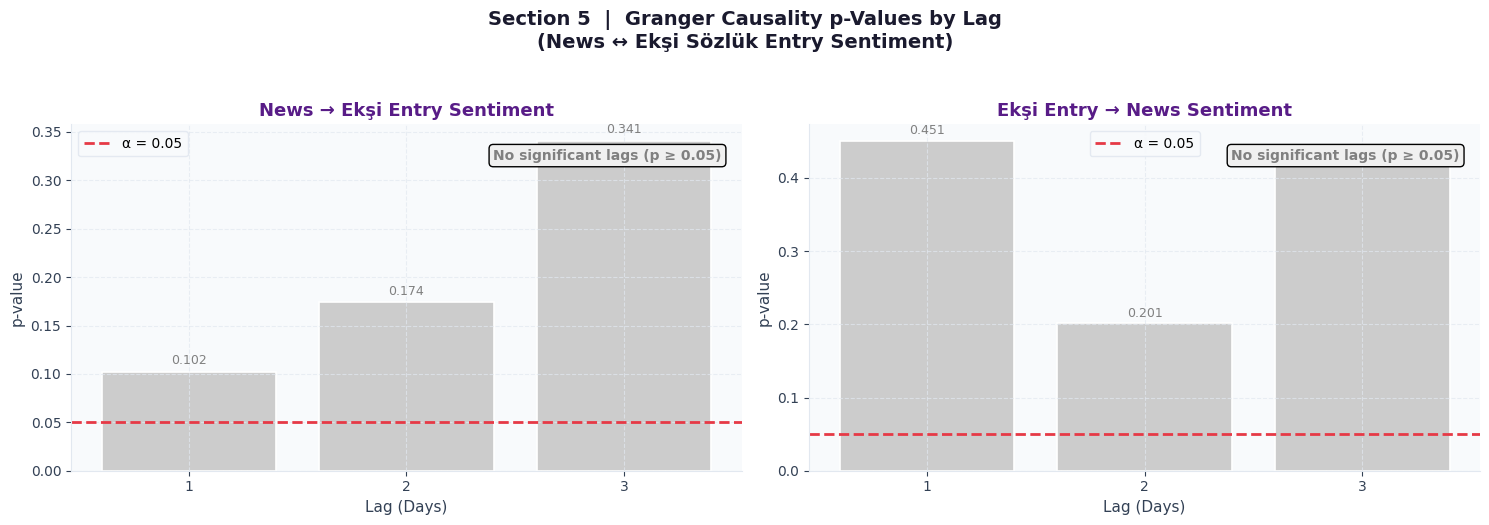

In [47]:
# ── Granger p-value visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Section 5  |  Granger Causality p-Values by Lag\n'
             '(News ↔ Ekşi Sözlük Entry Sentiment)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.04)

for ax, (direction, (lags, pvals)), title, color in [
    (axes[0], list(granger_results.items())[0],
     'News → Ekşi Entry Sentiment', TEAL),
    (axes[1], list(granger_results.items())[1],
     'Ekşi Entry → News Sentiment', ORANGE),
]:
    bar_colors = [RED if p < 0.05 else '#cccccc' for p in pvals]
    bars = ax.bar(lags, pvals, color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.axhline(0.05, color=RED, linestyle='--', linewidth=2, label='α = 0.05')
    ax.set_xlabel('Lag (Days)')
    ax.set_ylabel('p-value')
    ax.set_title(title)
    ax.set_xticks(lags)
    ax.legend(fontsize=10)
    for bar, p in zip(bars, pvals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{p:.3f}', ha='center', va='bottom', fontsize=9,
                color=RED if p < 0.05 else 'gray',
                fontweight='bold' if p < 0.05 else 'normal')
    sig_lags = [l for l, p in zip(lags, pvals) if p < 0.05]
    note = f'Significant lags: {sig_lags}' if sig_lags else 'No significant lags (p ≥ 0.05)'
    ax.text(0.97, 0.93, note, transform=ax.transAxes, ha='right', va='top',
            fontsize=10, color=RED if sig_lags else 'gray', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#fff0f0' if sig_lags else '#f0f0f0'))

plt.tight_layout()
plt.show()



---
## Section 6 — Model Evaluation & Interpretation

| Tool | What It Shows |
|---|---|
| Impulse Response Function (IRF) | How a one-unit shock in X propagates through Y over time |
| Forecast Error Variance Decomposition (FEVD) | What % of Y's forecast error is explained by X vs. Y itself |

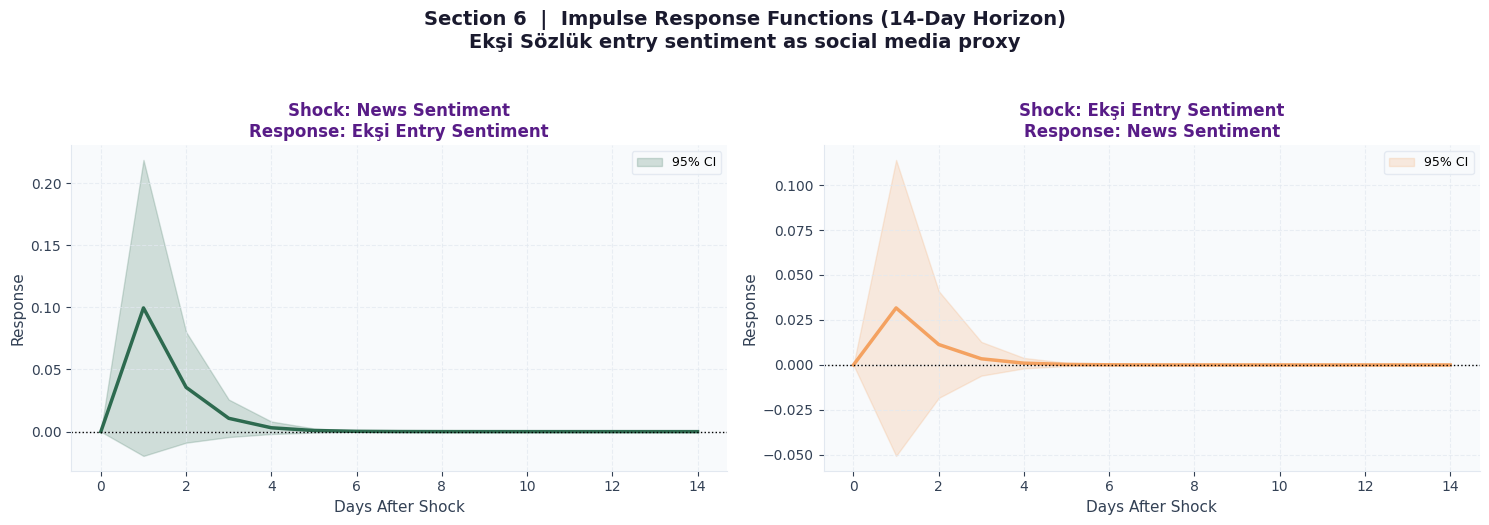

Interpretation: Significant deviation from zero = lasting causal effect.


In [48]:
# ── Impulse Response Function (IRF) ───────────────────────────────────
irf = var_fit.irf(periods=14)
irf_vals = irf.irfs          # shape: (periods, n_vars, n_vars)
stderr_vals = irf.stderr()   # shape: (periods, n_vars, n_vars) – METHOD çağrıldı!

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Section 6  |  Impulse Response Functions (14-Day Horizon)\n'
             'Ekşi Sözlük entry sentiment as social media proxy',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.04)

var_names   = ['news_sentiment', 'eksi_sentiment']
shock_from  = ['news_sentiment', 'eksi_sentiment']
response_in = ['eksi_sentiment', 'news_sentiment']
titles = [
    'Shock: News Sentiment\nResponse: Ekşi Entry Sentiment',
    'Shock: Ekşi Entry Sentiment\nResponse: News Sentiment',
]
colors = [TEAL, ORANGE]

for ax, shock, response, title, color in zip(
        axes, shock_from, response_in, titles, colors):
    shock_idx    = var_names.index(shock)
    response_idx = var_names.index(response)

    # Doğru indeksleme
    response_path = irf_vals[:, response_idx, shock_idx]
    response_se   = stderr_vals[:, response_idx, shock_idx]

    # %95 güven aralığı
    lower = response_path - 1.96 * response_se
    upper = response_path + 1.96 * response_se
    periods = np.arange(len(response_path))

    ax.plot(periods, response_path, color=color, linewidth=2.5)
    ax.fill_between(periods, lower, upper, alpha=0.2, color=color, label='95% CI')
    ax.axhline(0, color='black', linewidth=1, linestyle=':')
    ax.set_xlabel('Days After Shock')
    ax.set_ylabel('Response')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Interpretation: Significant deviation from zero = lasting causal effect.')



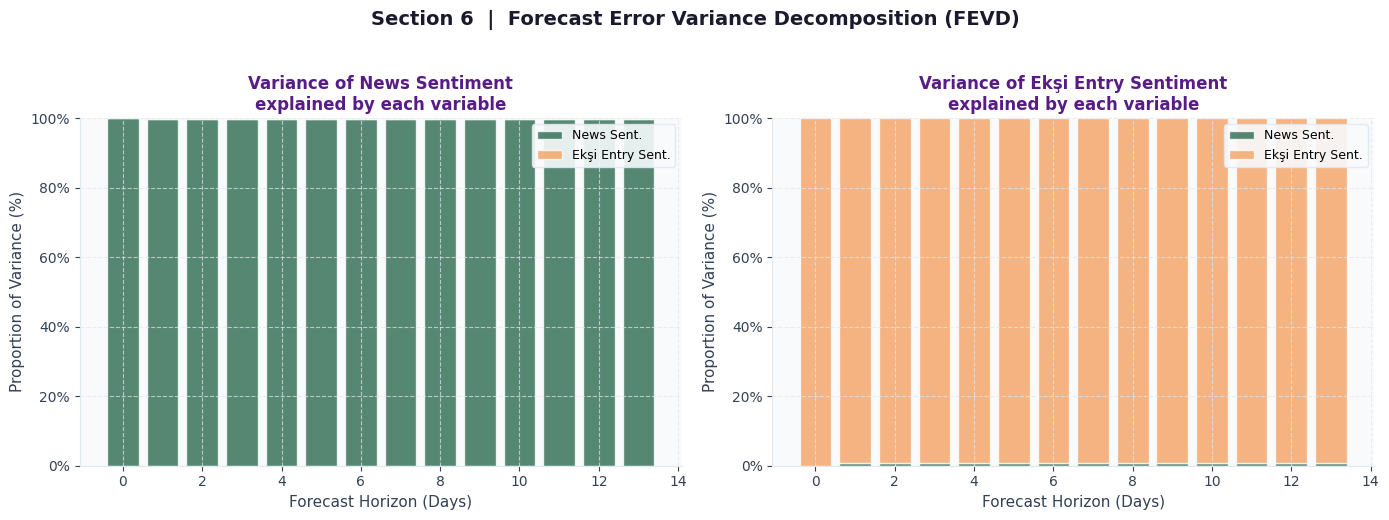

Growing teal bar in the Ekşi panel = news explains more of social media variance
→ evidence of agenda-setting effect.


In [49]:
# ── Forecast Error Variance Decomposition (FEVD) ───────────────────────
fevd = var_fit.fevd(periods=14)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 6  |  Forecast Error Variance Decomposition (FEVD)',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.03)

var_names_display = ['News Sent.', 'Ekşi Entry Sent.']
for i, (ax, title) in enumerate(zip(axes, [
    'Variance of News Sentiment\nexplained by each variable',
    'Variance of Ekşi Entry Sentiment\nexplained by each variable'
])):
    fevd_data = fevd.decomp[i]
    periods   = np.arange(fevd_data.shape[0])
    bottom    = np.zeros(len(periods))
    for j, (name, color) in enumerate(zip(var_names_display, [TEAL, ORANGE])):
        ax.bar(periods, fevd_data[:, j], bottom=bottom,
               color=color, alpha=0.8, label=name, edgecolor='white')
        bottom += fevd_data[:, j]
    ax.set_xlabel('Forecast Horizon (Days)')
    ax.set_ylabel('Proportion of Variance (%)')
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Growing teal bar in the Ekşi panel = news explains more of social media variance')
print('→ evidence of agenda-setting effect.')




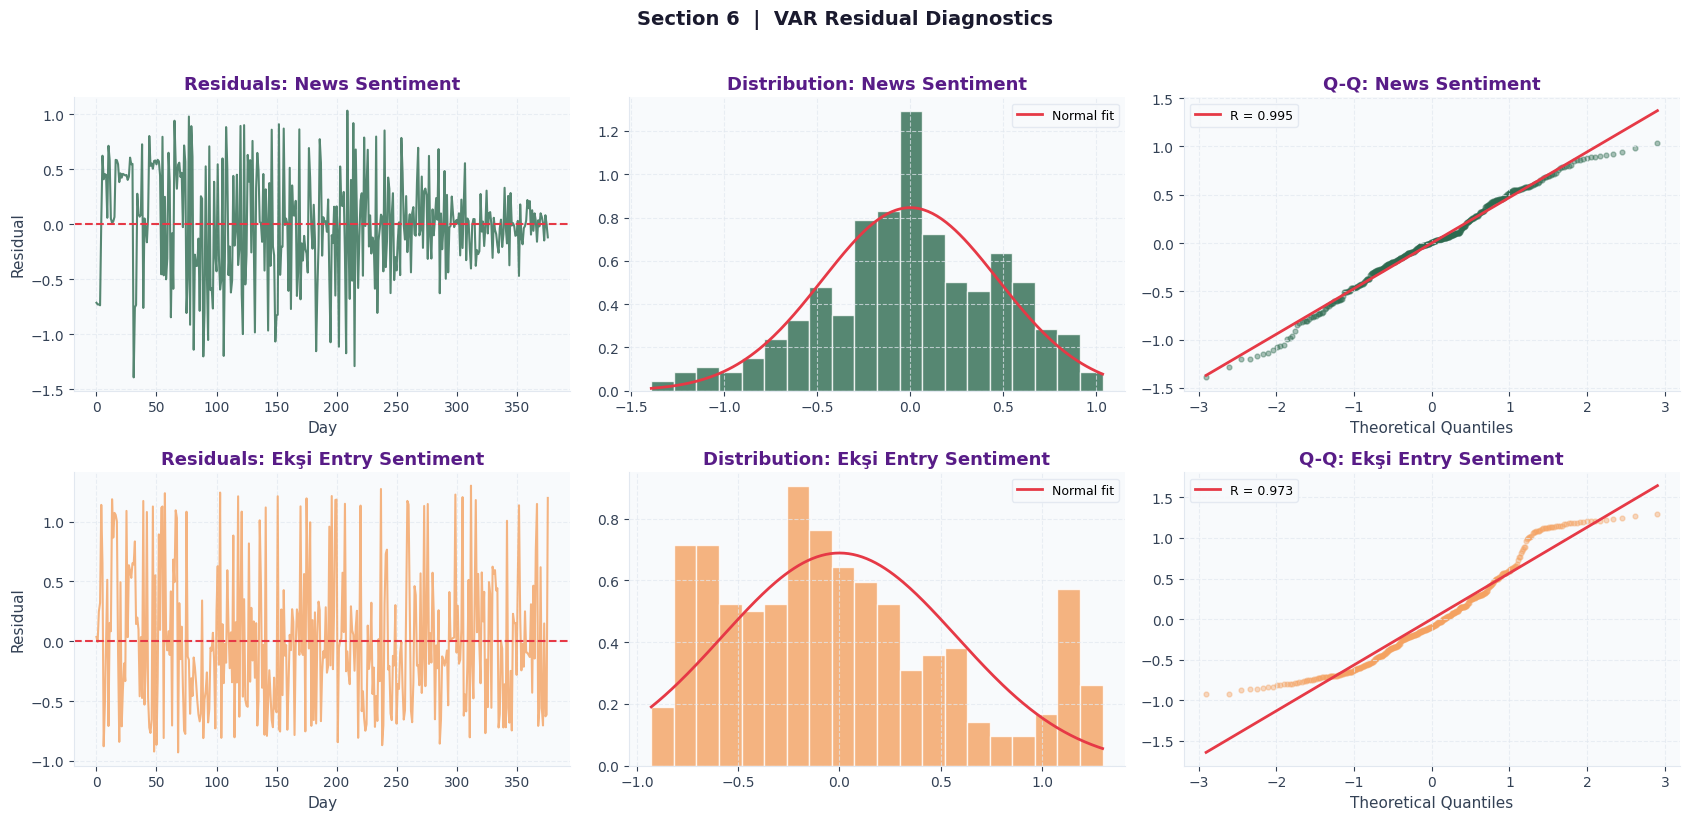

Good residuals: zero mean, no autocorrelation, approximately normal distribution.


In [50]:
# ── Residual diagnostics ───────────────────────────────────────────────
residuals = var_fit.resid

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
fig.suptitle('Section 6  |  VAR Residual Diagnostics',
             fontsize=14, fontweight='bold', color='#1a1a2e', y=1.02)

var_cols = ['news_sentiment', 'eksi_sentiment']
col_labels = ['News Sentiment', 'Ekşi Entry Sentiment']
colors   = [TEAL, ORANGE]

for i, (col, label, color) in enumerate(zip(var_cols, col_labels, colors)):
    res = residuals.iloc[:, i]
    axes[i][0].plot(res.values, color=color, linewidth=1.5, alpha=0.8)
    axes[i][0].axhline(0, color=RED, linestyle='--', linewidth=1.5)
    axes[i][0].set_title(f'Residuals: {label}')
    axes[i][0].set_xlabel('Day')
    axes[i][0].set_ylabel('Residual')

    axes[i][1].hist(res, bins=20, color=color, edgecolor='white', alpha=0.8, density=True)
    xs = np.linspace(res.min(), res.max(), 200)
    axes[i][1].plot(xs, stats.norm.pdf(xs, res.mean(), res.std()),
                    color=RED, linewidth=2, label='Normal fit')
    axes[i][1].set_title(f'Distribution: {label}')
    axes[i][1].legend(fontsize=9)

    (osm, osr), (slope, intercept, r) = stats.probplot(res, dist='norm')
    axes[i][2].scatter(osm, osr, alpha=0.4, s=12, color=color)
    axes[i][2].plot(osm, slope*np.array(osm)+intercept,
                    color=RED, linewidth=2, label=f'R = {r:.3f}')
    axes[i][2].set_title(f'Q-Q: {label}')
    axes[i][2].set_xlabel('Theoretical Quantiles')
    axes[i][2].legend(fontsize=9)

plt.tight_layout()
plt.show()
print('Good residuals: zero mean, no autocorrelation, approximately normal distribution.')



### 6.1 — Topic-Level Granger Causality, Per-Lag (Table IV)


In [51]:
# ── Topic-Level Granger Causality — Per-Lag Breakdown (Table IV) ────────
# Reports every individual lag (rather than just the minimum p-value across
# lags), so the exact lag at which each topic becomes significant is visible.
# No per-topic differencing is applied here (consistent with the pooled
# analysis above): all series were already found level-stationary (Table II).
# Any topic that is not level-stationary is flagged below instead.
#
# NOTE: this cell now also prints the FULL per-topic ADF statistics (not just
# a warning when a series happens to be non-stationary). The paper's Table II
# reports specific ADF test statistics for economy/politics/national — those
# numbers must come from code output, so we build and display that table here
# explicitly rather than only checking a threshold silently.

MIN_OBS_GRANGER = 20
topic_summary_perlag = []
topic_adf_rows = []

for topic in ['economy', 'politics', 'national']:
    mask = df_raw.topic == topic
    sub = df_raw.loc[mask, ['news_sentiment', 'eksi_sentiment']].dropna()
    n = len(sub)
    if n < MIN_OBS_GRANGER:
        print(f'{topic}: n={n} < {MIN_OBS_GRANGER} -- skip')
        continue

    # Stationarity check -- full ADF result recorded for BOTH series,
    # regardless of outcome (previously only printed on failure).
    adf_res_news = adfuller(sub['news_sentiment'].dropna(), autolag='AIC')
    adf_res_eksi = adfuller(sub['eksi_sentiment'].dropna(), autolag='AIC')

    for series_name, res in [('news_sentiment', adf_res_news), ('eksi_sentiment', adf_res_eksi)]:
        stat, p_value = res[0], res[1]
        topic_adf_rows.append({
            'Topic': topic,
            'Variable': series_name,
            'n': n,
            'ADF Statistic': round(stat, 4),
            'p-value': round(p_value, 6),
            'Critical (5%)': round(res[4]['5%'], 4),
            'Stationary?': '✓ Yes' if p_value < 0.05 else '✗ No',
        })

    stat_note = []
    if adf_res_news[1] >= 0.05:
        stat_note.append(f"news_sentiment NON-stationary (ADF p={adf_res_news[1]:.4f})")
    if adf_res_eksi[1] >= 0.05:
        stat_note.append(f"eksi_sentiment NON-stationary (ADF p={adf_res_eksi[1]:.4f})")
    if stat_note:
        print(f'  ⚠ {topic}: ' + ' | '.join(stat_note))

    safe_lag = max(1, min(3, len(sub) // 10))

    gc_n2t = grangercausalitytests(
        sub[['eksi_sentiment', 'news_sentiment']], maxlag=safe_lag, verbose=False)
    gc_t2n = grangercausalitytests(
        sub[['news_sentiment', 'eksi_sentiment']], maxlag=safe_lag, verbose=False)

    print(f'\n=== {topic} (n={len(sub)}, max_lag={safe_lag}) ===')
    print(f'{"Lag":<5}{"News->Eksi p":>15}{"Eksi->News p":>15}')
    n_tests_this_topic = safe_lag  # Bonferroni: how many lags tested for this topic
    for lag in range(1, safe_lag + 1):
        p_n2t = gc_n2t[lag][0]['ssr_ftest'][1]
        p_t2n = gc_t2n[lag][0]['ssr_ftest'][1]
        bonf = 0.05 / n_tests_this_topic
        flag_n2t = '*' if p_n2t < 0.05 else ('†' if p_n2t < bonf else '')
        flag_t2n = '*' if p_t2n < 0.05 else ''
        print(f'{lag:<5}{p_n2t:>14.4f}{flag_n2t:<1}{p_t2n:>14.4f}{flag_t2n:<1}')
        topic_summary_perlag.append({
            'Topic': topic, 'Lag': lag, 'n': len(sub),
            'p(News->Eksi)': round(p_n2t, 4),
            'p(Eksi->News)': round(p_t2n, 4),
            'Bonferroni_threshold': round(bonf, 4),
            'Survives_Bonferroni_News2Eksi': p_n2t < bonf,
        })
    print(f'  (* p<0.05 raw threshold | dagger p< Bonferroni threshold {0.05/safe_lag:.4f} -- {safe_lag} lags tested for this topic)')

# ── Per-Topic ADF Table (Table II in the paper) — printed explicitly ────────
adf_topic_df = pd.DataFrame(topic_adf_rows).set_index(['Topic', 'Variable'])
print('\n\n=== Per-Topic ADF Stationarity (Table II source) ===')
print(adf_topic_df.to_string())

summary_perlag_df = pd.DataFrame(topic_summary_perlag)
print('\n\n=== OZET TABLO ===')
print(summary_perlag_df.to_string(index=False))



=== economy (n=111, max_lag=3) ===
Lag     News->Eksi p   Eksi->News p
1            0.9783         0.6576 
2            0.5716         0.8881 
3            0.5447         0.1212 
  (* p<0.05 raw threshold | dagger p< Bonferroni threshold 0.0167 -- 3 lags tested for this topic)

=== politics (n=84, max_lag=3) ===
Lag     News->Eksi p   Eksi->News p
1            0.0538         0.1170 
2            0.2229         0.2522 
3            0.4070         0.2280 
  (* p<0.05 raw threshold | dagger p< Bonferroni threshold 0.0167 -- 3 lags tested for this topic)

=== national (n=93, max_lag=3) ===
Lag     News->Eksi p   Eksi->News p
1            0.5840         0.1278 
2            0.6002         0.1658 
3            0.8107         0.1861 
  (* p<0.05 raw threshold | dagger p< Bonferroni threshold 0.0167 -- 3 lags tested for this topic)


=== Per-Topic ADF Stationarity (Table II source) ===
                           n  ADF Statistic   p-value  Critical (5%) Stationary?
Topic    Variable          

### 6.1b — Engagement-Weighted Sentiment

<div class="callout">
Standard Granger analysis weighs all days equally. But Ekşi Sözlük entries with <b>high favourite counts</b> may reflect stronger public engagement. This section checks whether high-engagement days show a different news↔social relationship.
</div>


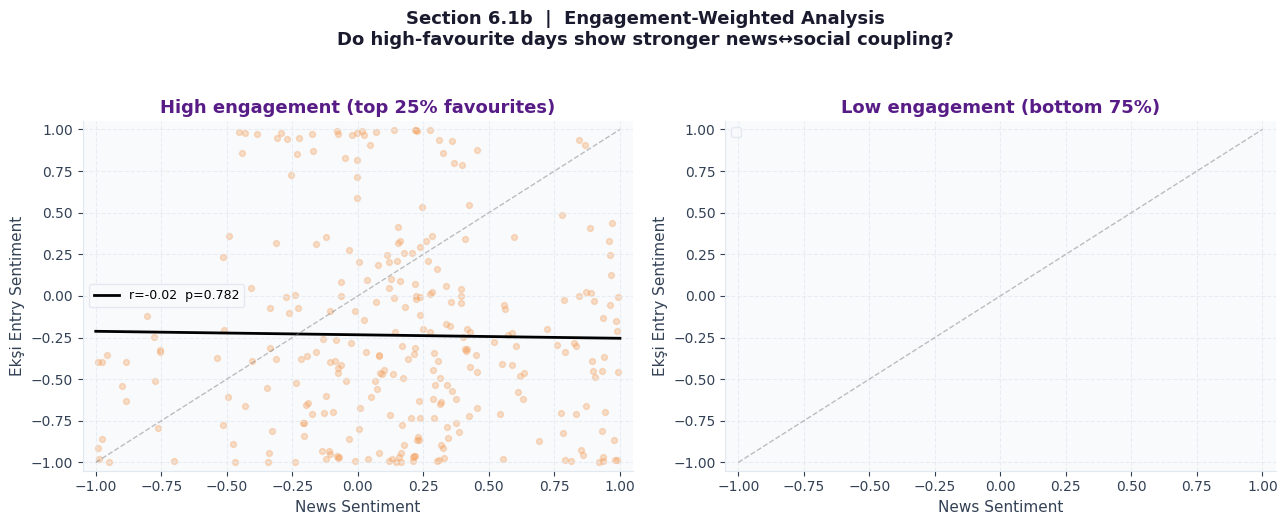

Interpretation:
  Similar r across both panels → engagement level does not change the coupling strength
  Diverging r across panels → high-engagement days show a different news↔social relationship


In [52]:
# ── Engagement-weighted analysis ──────────
# High-engagement days (top quartile avg_favorites)
if 'avg_favorites' in df_raw.columns:
    fav_threshold = df_raw['avg_favorites'].quantile(0.75)
    high_eng = df_raw['avg_favorites'] >= fav_threshold
    low_eng  = df_raw['avg_favorites'] <  fav_threshold

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Section 6.1b  |  Engagement-Weighted Analysis\n'
                 'Do high-favourite days show stronger news↔social coupling?',
                 fontsize=13, fontweight='bold', color='#1a1a2e', y=1.04)

    for ax, mask, label, color in [
        (axes[0], high_eng, 'High engagement (top 25% favourites)', ORANGE),
        (axes[1], low_eng,  'Low engagement (bottom 75%)',          BLUE),
    ]:
        sub = df_raw[mask].dropna(subset=['news_sentiment', 'eksi_sentiment'])
        ax.scatter(sub['news_sentiment'], sub['eksi_sentiment'],
                   color=color, alpha=0.35, s=18)
        if len(sub) > 3:
            m_e, b_e, r_e, p_e, _ = stats.linregress(
                sub['news_sentiment'], sub['eksi_sentiment'])
            x_fit = np.linspace(-1, 1, 200)
            ax.plot(x_fit, m_e*x_fit+b_e, color='black', linewidth=2,
                    label=f'r={r_e:.2f}  p={p_e:.3f}')
        ax.plot([-1,1], [-1,1], color='gray', linewidth=1, linestyle='--', alpha=0.5)
        ax.set_xlabel('News Sentiment')
        ax.set_ylabel('Ekşi Entry Sentiment')
        ax.set_title(label)
        ax.legend(fontsize=9)
        ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)

    plt.tight_layout()
    plt.show()

    print('Interpretation:')
    print('  Similar r across both panels → engagement level does not change the coupling strength')
    print('  Diverging r across panels → high-engagement days show a different news↔social relationship')
else:
    print('avg_favorites column not found — run Section 0 to collect Ekşi data with favourites.')


### 6.2 — Supplementary Robustness Checks

<div class="callout">
Three additional checks that stress-test the main VAR/Granger finding: (1) a direct
scatter of news vs. Ekşi sentiment by topic (Figure 1), (2) whether the same
agenda-setting pattern holds for <b>volume</b> (article/entry counts) rather than
sentiment, and (3) whether the finding survives at <b>daily</b> resolution with an
accompanying check of how many gap-days the daily series actually has.
</div>



Topic: ECONOMY  (n=111)
  Anlık korelasyon   r=0.0952  p=0.3203
  Lag-1 hft korelas. r=0.0299  p=0.7566

Topic: POLITICS  (n=84)
  Anlık korelasyon   r=0.0808  p=0.4648
  Lag-1 hft korelas. r=0.2078  p=0.0595

Topic: NATIONAL  (n=93)
  Anlık korelasyon   r=-0.1450  p=0.1655
  Lag-1 hft korelas. r=0.0590  p=0.5762


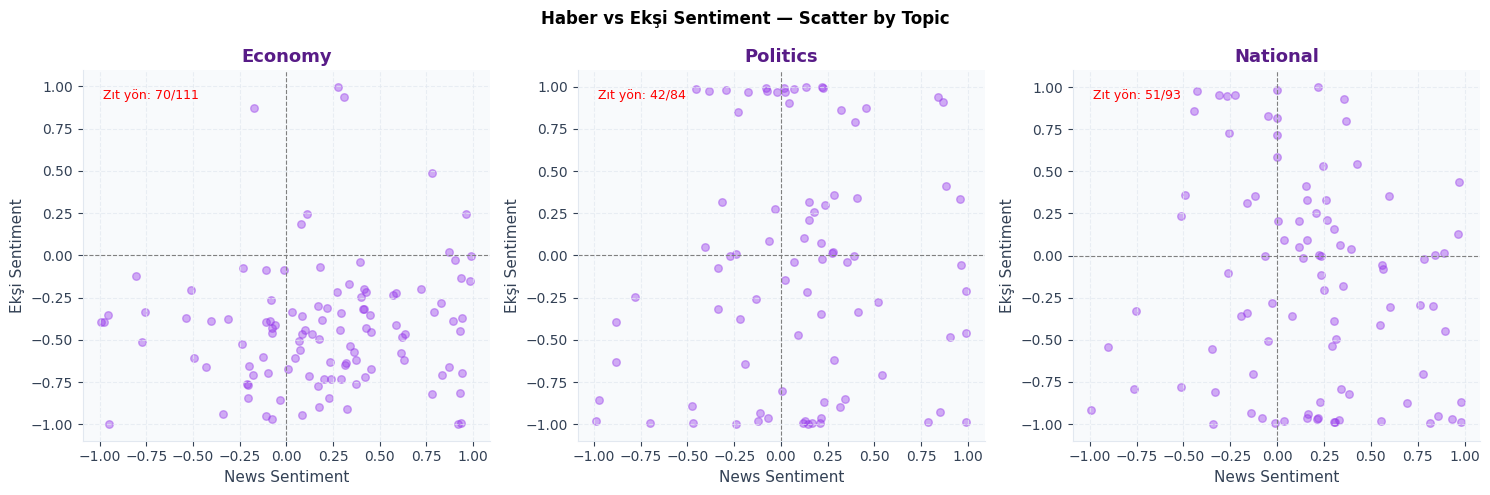

Kaydedildi: analiz_scatter.png


In [53]:
# ── Figure 1: News vs. Ekşi Sentiment — Same Direction or Opposite? ─────
import matplotlib.pyplot as plt
from scipy import stats

df_raw = pd.read_csv('data/ts_weekly.csv', parse_dates=['date'])

results_corr = {}
for topic in ['economy', 'politics', 'national']:
    df_t = df_raw[df_raw['topic'] == topic][
        ['date', 'news_sentiment', 'eksi_sentiment']].dropna().sort_values('date')
    
    # Contemporaneous correlation
    r, p = stats.pearsonr(df_t['news_sentiment'], df_t['eksi_sentiment'])
    
    # Correlation with next week's Ekşi sentiment (lag-1 cross-correlation)
    df_t['eksi_next_week'] = df_t['eksi_sentiment'].shift(-1)
    df_lag = df_t[['news_sentiment', 'eksi_next_week']].dropna()
    r_lag, p_lag = stats.pearsonr(df_lag['news_sentiment'], df_lag['eksi_next_week'])
    
    results_corr[topic] = {'r_contemp': r, 'p_contemp': p,
                            'r_lag1':    r_lag, 'p_lag1': p_lag, 'n': len(df_t)}
    print(f"\n{'='*50}")
    print(f"Topic: {topic.upper()}  (n={len(df_t)})")
    print(f"  Anlık korelasyon   r={r:.4f}  p={p:.4f}")
    print(f"  Lag-1 hft korelas. r={r_lag:.4f}  p={p_lag:.4f}")

# Scatter plot — 3 topic yan yana
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, topic in zip(axes, ['economy', 'politics', 'national']):
    df_t = df_raw[df_raw['topic'] == topic][
        ['news_sentiment', 'eksi_sentiment']].dropna()
    ax.scatter(df_t['news_sentiment'], df_t['eksi_sentiment'], alpha=0.4, s=30)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('News Sentiment')
    ax.set_ylabel('Ekşi Sentiment')
    ax.set_title(f'{topic.capitalize()}')
    # Quadrant counts
    q2 = ((df_t['news_sentiment'] > 0) & (df_t['eksi_sentiment'] < 0)).sum()
    q4 = ((df_t['news_sentiment'] < 0) & (df_t['eksi_sentiment'] > 0)).sum()
    ax.text(0.05, 0.95, f'Zıt yön: {q2+q4}/{len(df_t)}',
            transform=ax.transAxes, va='top', fontsize=9, color='red')
plt.suptitle('Haber vs Ekşi Sentiment — Scatter by Topic', fontweight='bold')
plt.tight_layout()
plt.savefig('analiz_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: analiz_scatter.png")



In [54]:
# ── Volume Granger Causality — Does Agenda-Setting Extend to Volume? ────
from statsmodels.tsa.stattools import grangercausalitytests

print("="*60)
print("Volume Granger Causality (weekly, all topics)")
print("="*60)

df_vol_all = df_raw[['news_volume', 'eksi_volume']].dropna()
print(f"Kullanılan gözlem: {len(df_vol_all)}\n")

print("--- News Volume → Ekşi Volume ---")
res_ne = grangercausalitytests(df_vol_all[['eksi_volume', 'news_volume']], maxlag=3, verbose=True)

print("\n--- Ekşi Volume → News Volume ---")
res_en = grangercausalitytests(df_vol_all[['news_volume', 'eksi_volume']], maxlag=3, verbose=True)

# Topic bazında özet
print("\n--- Topic bazında Volume Granger (lag 1) ---")
for topic in ['economy', 'politics', 'national']:
    df_t = df_raw[df_raw['topic'] == topic][['news_volume', 'eksi_volume']].dropna()
    if len(df_t) < 20:
        print(f"{topic}: yetersiz veri ({len(df_t)})")
        continue
    try:
        r1 = grangercausalitytests(df_t[['eksi_volume', 'news_volume']], maxlag=1, verbose=False)
        r2 = grangercausalitytests(df_t[['news_volume', 'eksi_volume']], maxlag=1, verbose=False)
        p_ne = r1[1][0]['ssr_ftest'][1]
        p_en = r2[1][0]['ssr_ftest'][1]
        sig_ne = "***" if p_ne < 0.05 else ("†" if p_ne < 0.10 else "ns")
        sig_en = "***" if p_en < 0.05 else ("†" if p_en < 0.10 else "ns")
        print(f"  {topic:<10} n={len(df_t):>3}  News→Ekşi p={p_ne:.4f} {sig_ne}   Ekşi→News p={p_en:.4f} {sig_en}")
    except Exception as e:
        print(f"  {topic}: hata — {e}")

        

Volume Granger Causality (weekly, all topics)
Kullanılan gözlem: 288

--- News Volume → Ekşi Volume ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1603  , p=0.6892  , df_denom=284, df_num=1
ssr based chi2 test:   chi2=0.1620  , p=0.6874  , df=1
likelihood ratio test: chi2=0.1619  , p=0.6874  , df=1
parameter F test:         F=0.1603  , p=0.6892  , df_denom=284, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2675  , p=0.7654  , df_denom=281, df_num=2
ssr based chi2 test:   chi2=0.5446  , p=0.7616  , df=2
likelihood ratio test: chi2=0.5441  , p=0.7618  , df=2
parameter F test:         F=0.2675  , p=0.7654  , df_denom=281, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3932  , p=0.7580  , df_denom=278, df_num=3
ssr based chi2 test:   chi2=1.2093  , p=0.7508  , df=3
likelihood ratio test: chi2=1.2067  , p=0.7514  , df=3
parameter F test:         F=0.3932  , p=0.7580  , df_denom=278,

In [55]:
# ── Daily-Resolution Robustness Check — Granger on Economy Topic ────────
print("="*60)
print("Daily-resolution Granger causality — Economy topic")
print("="*60)

df_daily = pd.read_csv('data/ts_daily.csv', parse_dates=['date'])
df_econ_d = df_daily[df_daily['topic'] == 'economy'][
    ['date', 'news_sentiment', 'eksi_sentiment']].dropna().sort_values('date')

print(f"Gözlem (economy, daily): {len(df_econ_d)}")
print(f"Tarih aralığı: {df_econ_d['date'].min().date()} → {df_econ_d['date'].max().date()}\n")

# Stationarity önce
from statsmodels.tsa.stattools import adfuller
for col in ['news_sentiment', 'eksi_sentiment']:
    adf_stat, p_val, *_ = adfuller(df_econ_d[col], autolag='AIC')
    print(f"ADF {col}: stat={adf_stat:.4f}  p={p_val:.4f}  {'✓ Durağan' if p_val < 0.05 else '✗ Durağan DEĞİL'}")

print("\n--- News Sentiment → Ekşi Sentiment (günlük, lag 1-7) ---")
res_daily_ne = grangercausalitytests(
    df_econ_d[['eksi_sentiment', 'news_sentiment']], maxlag=7, verbose=True)

print("\n--- Ekşi Sentiment → News Sentiment (günlük, lag 1-7) ---")
res_daily_en = grangercausalitytests(
    df_econ_d[['news_sentiment', 'eksi_sentiment']], maxlag=7, verbose=True)

# Özet tablo
print("\n=== GÜNLÜK GRANGER ÖZET (Economy) ===")
print(f"{'Lag':<6} {'News→Ekşi p':>12} {'Ekşi→News p':>12} {'Anlamlı?':>10}")
print("-"*45)
for lag in range(1, 8):
    p_ne = res_daily_ne[lag][0]['ssr_ftest'][1]
    p_en = res_daily_en[lag][0]['ssr_ftest'][1]
    sig = "***" if min(p_ne, p_en) < 0.05 else ("†" if min(p_ne, p_en) < 0.10 else "")
    print(f"{lag:<6} {p_ne:>12.4f} {p_en:>12.4f} {sig:>10}")

Daily-resolution Granger causality — Economy topic
Gözlem (economy, daily): 208
Tarih aralığı: 2024-03-08 → 2026-07-09

ADF news_sentiment: stat=-8.2295  p=0.0000  ✓ Durağan
ADF eksi_sentiment: stat=-7.9492  p=0.0000  ✓ Durağan

--- News Sentiment → Ekşi Sentiment (günlük, lag 1-7) ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1338  , p=0.7149  , df_denom=204, df_num=1
ssr based chi2 test:   chi2=0.1358  , p=0.7125  , df=1
likelihood ratio test: chi2=0.1358  , p=0.7125  , df=1
parameter F test:         F=0.1338  , p=0.7149  , df_denom=204, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0557  , p=0.9459  , df_denom=201, df_num=2
ssr based chi2 test:   chi2=0.1141  , p=0.9445  , df=2
likelihood ratio test: chi2=0.1141  , p=0.9446  , df=2
parameter F test:         F=0.0557  , p=0.9459  , df_denom=201, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.4885  , p=0.2189  , df_denom=198,

In [56]:
# ── Daily Coverage Gap Statistics (Economy topic) ───────────────────────
df_econ_d = df_daily[df_daily['topic']=='economy'][
    ['date','news_sentiment','eksi_sentiment']].dropna().sort_values('date')
gaps = df_econ_d['date'].diff().dt.days
print(gaps.describe())
print(f"1 günden fazla boşluğu olan satır: {(gaps > 1).sum()} / {len(gaps)}")

# Ek: boşluk dağılımının histogramı — kaç satır 1,2,3,4+ gün boşluklu
print(gaps.value_counts().sort_index().head(10))

# Ek: en uzun 5 boşluk nerede?
top_gaps = df_econ_d.assign(gap=gaps).nlargest(5, 'gap')[['date','gap']]
print(top_gaps)


count    207.000000
mean       4.120773
std        5.841757
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       39.000000
Name: date, dtype: float64
1 günden fazla boşluğu olan satır: 118 / 208
date
1.0     89
2.0     39
3.0     16
4.0     12
5.0     11
6.0      6
7.0      3
8.0      5
9.0      4
10.0     3
Name: count, dtype: int64
          date   gap
29  2024-04-21  39.0
240 2025-04-07  30.0
184 2025-01-02  29.0
54  2024-06-09  27.0
99  2024-08-18  25.0


### 6.3 — Triple-Annotator Manual Validation of BERTurk Sentiment Scoring

<div class="callout">
BERTurk is a general-domain sentiment model, not fine-tuned on Turkish news or Ekşi
Sözlük text. The cell below is self-contained: it draws an 80-entry stratified sample,
walks you through labeling it by hand directly in the CSV file by THREE independent
annotators — two human annotators ('manual_label', 'Ayse') and one AI annotator
('ai_label') — and, once all three columns are filled, automatically computes pairwise
Cohen's kappa, Fleiss' kappa across all three raters, a majority-vote ground truth
(excluding rows with no majority), BERTurk's accuracy/F1 against that ground truth, and
the direction of its misclassifications on true-negative entries — printing everything as
code output. No separate upload or external evaluation step is needed: just edit the CSV
and re-run the cell. The enriched CSV and a metrics summary JSON are saved back to the
project folder so any other user can pick up the results without re-running anything.
</div>


In [57]:
# ── Triple-Annotator Manual Validation of BERTurk (Section III-E / IV-D) ──
# The paper's measurement-validity section describes THREE annotators:
#   - two human annotators (the authors, blind to the classifier score)
#   - one AI annotator (Claude)
# and reports Fleiss' kappa, pairwise Cohen's kappa, majority-vote ground
# truth (excluding rows with no majority), classifier accuracy against that
# ground truth, and the direction of misclassification on true-negative
# entries. The CSV this study actually uses has three label columns:
#   'manual_label' -> Annotator 1 (Hacer)
#   'Ayse'         -> Annotator 2 (Ayşegül)
#   'ai_label'     -> AI annotator (Claude)
# This cell computes ALL of that directly from the CSV and prints it as code
# output, so every number quoted in Tables IAA / berturk_perf / errdir has a
# traceable, reproducible source. If the CSV only has a single 'manual_label'
# column (no 'Ayse'/'ai_label'), it falls back to a simple two-rater check.

import os
import json as _json
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, cohen_kappa_score

np.random.seed(42)  # reproducibility

VALIDATION_SAMPLE = 'manual_validation_sample.csv'
SUMMARY_FILE      = 'manual_validation_summary.json'
LABELS            = ['negative', 'neutral', 'positive']


def stratified_sample(df, n, seed_offset=0):
    df = df.copy()
    bins = pd.cut(df['sentiment_score'], bins=[-1.01, -0.33, 0.33, 1.01],
                   labels=['negative', 'neutral', 'positive'])
    df['_bin'] = bins
    per_bin = n // 3
    remainder = n - per_bin * 3
    samples = []
    for i, b in enumerate(['negative', 'neutral', 'positive']):
        sub = df[df['_bin'] == b]
        k = per_bin + (1 if i < remainder else 0)
        k = min(k, len(sub))
        samples.append(sub.sample(n=k, random_state=42 + seed_offset))
    return pd.concat(samples)


def to_class(score):
    if score < -0.33:
        return 'negative'
    elif score > 0.33:
        return 'positive'
    return 'neutral'


def fleiss_kappa(rating_counts):
    """rating_counts: (n_subjects, n_categories) array of counts per category.
    Standard Fleiss' kappa for >=3 raters, arbitrary #categories."""
    n_subjects, n_cats = rating_counts.shape
    n_raters = rating_counts.sum(axis=1)[0]  # assumed constant across subjects
    P_i = ((rating_counts ** 2).sum(axis=1) - n_raters) / (n_raters * (n_raters - 1))
    P_bar = P_i.mean()
    p_j = rating_counts.sum(axis=0) / (n_subjects * n_raters)
    P_e = (p_j ** 2).sum()
    return (P_bar - P_e) / (1 - P_e)


def majority_vote(row, cols):
    vals = [row[c] for c in cols]
    counts = pd.Series(vals).value_counts()
    if counts.iloc[0] >= 2:  # at least 2 of 3 agree
        return counts.index[0]
    return 'NO_MAJORITY'


# ── STAGE 1: no sample file yet -> generate the template ────────────────────
if not os.path.exists(VALIDATION_SAMPLE):
    print("STAGE 1/2 — No validation sample found. Generating stratified sample template.\n")

    df_eksi_raw = pd.read_csv('data/eksisozluk_with_sentiment.csv', parse_dates=['date'])
    df_eksi_raw = df_eksi_raw[df_eksi_raw['low_confidence'] == False].copy()

    N_ECONOMY = 63
    N_OTHER   = 17

    df_econ  = df_eksi_raw[df_eksi_raw['topic'] == 'economy']
    df_other = df_eksi_raw[df_eksi_raw['topic'] != 'economy']

    sample_econ  = stratified_sample(df_econ, N_ECONOMY, seed_offset=0)
    sample_other = stratified_sample(df_other, N_OTHER, seed_offset=1)

    sample = pd.concat([sample_econ, sample_other]).sample(frac=1, random_state=7).reset_index(drop=True)

    sample['manual_label'] = ''   # Annotator 1 (fill by hand)
    sample['Ayse']         = ''   # Annotator 2 (fill by hand)
    sample['ai_label']     = ''   # AI annotator (fill separately, e.g. via API)
    sample['notes']        = ''

    cols_out = ['topic', 'date', 'text', 'sentiment_score', 'irony_flag',
                'manual_label', 'Ayse', 'ai_label', 'notes']
    sample[cols_out].to_csv(VALIDATION_SAMPLE, index=False, encoding='utf-8-sig')

    print(f"Saved: {VALIDATION_SAMPLE}  ({len(sample)} rows)")
    print("\n>>> ACTION NEEDED <<<")
    print("Fill 'manual_label' (Annotator 1) and 'Ayse' (Annotator 2) by hand,")
    print("reading only 'text' (not 'sentiment_score'). Fill 'ai_label' with a")
    print("third, independent AI annotation. Then re-run THIS cell.")

else:
    df = pd.read_csv(VALIDATION_SAMPLE, encoding='utf-8-sig')
    has_triple = {'manual_label', 'Ayse', 'ai_label'}.issubset(df.columns)

    ann_cols = ['manual_label', 'Ayse', 'ai_label'] if has_triple else ['manual_label']
    labeled_mask = np.all([df[c].isin(LABELS) for c in ann_cols], axis=0)

    if not labeled_mask.all():
        n_done, n_total = int(labeled_mask.sum()), len(df)
        print(f"STAGE 1/2 — Sample file found, but not fully labeled yet ({n_done}/{n_total} rows done on {ann_cols}).")
        print("\n>>> ACTION NEEDED <<<")
        print(f"Finish filling {ann_cols} for the remaining {n_total - n_done} row(s), then re-run THIS cell.")

    elif has_triple:
        # ── STAGE 2 (triple-annotator): Fleiss' kappa, majority vote, classifier eval ──
        print(f"STAGE 2/2 — Triple-annotator sample found ({len(df)} rows). Running full validation.\n")
        print("=" * 70)

        df['berturk_label'] = df['sentiment_score'].apply(to_class)

        # --- Pairwise Cohen's kappa (Table IAA) ---
        pairs = [('manual_label', 'Ayse'), ('manual_label', 'ai_label'), ('Ayse', 'ai_label')]
        pair_names = ['Annotator1 <-> Annotator2', 'Annotator1 <-> AI', 'Annotator2 <-> AI']
        print("=== Pairwise Inter-Annotator Agreement (Cohen's kappa) ===")
        iaa_rows = []
        for (c1, c2), name in zip(pairs, pair_names):
            k = cohen_kappa_score(df[c1], df[c2], labels=LABELS)
            agree = (df[c1] == df[c2]).mean()
            iaa_rows.append({'Pair': name, 'kappa': round(k, 3), 'raw_agreement': round(agree, 3)})
            print(f"  {name:<28} kappa={k:.3f}   raw agreement={agree:.1%}")

        # --- Fleiss' kappa across all three annotators ---
        cat_counts = np.zeros((len(df), len(LABELS)), dtype=int)
        for i, row in df.iterrows():
            for c in ['manual_label', 'Ayse', 'ai_label']:
                cat_counts[df.index.get_loc(i), LABELS.index(row[c])] += 1
        fleiss_k = fleiss_kappa(cat_counts)
        print(f"\nFleiss' kappa (3 annotators): {fleiss_k:.3f}")

        # --- Majority-vote ground truth ---
        df['ground_truth'] = df.apply(lambda r: majority_vote(r, ['manual_label', 'Ayse', 'ai_label']), axis=1)
        n_no_majority = (df['ground_truth'] == 'NO_MAJORITY').sum()
        df_gt = df[df['ground_truth'] != 'NO_MAJORITY'].copy()
        print(f"\nMajority-vote ground truth: {len(df_gt)} / {len(df)} rows "
              f"({n_no_majority} excluded as NO_MAJORITY, {n_no_majority/len(df):.1%})")

        # --- Classifier performance against ground truth (Table berturk_perf) ---
        print(f"\n=== BERTurk vs. Majority-Vote Ground Truth (n={len(df_gt)}) ===")
        print(classification_report(df_gt['ground_truth'], df_gt['berturk_label'],
                                     labels=LABELS, digits=3))
        acc = (df_gt['ground_truth'] == df_gt['berturk_label']).mean()
        print(f"Overall accuracy: {acc:.1%}")

        print("\n=== Confusion Matrix ===")
        cm = confusion_matrix(df_gt['ground_truth'], df_gt['berturk_label'], labels=LABELS)
        cm_df = pd.DataFrame(cm, index=[f'true_{l}' for l in LABELS],
                              columns=[f'pred_{l}' for l in LABELS])
        print(cm_df)

        # --- Misclassification direction on true-negative entries (Table errdir) ---
        print("\n=== Misclassification Direction (True Negative Entries) ===")
        df_true_neg = df_gt[df_gt['ground_truth'] == 'negative']
        errdir = df_true_neg['berturk_label'].value_counts().reindex(LABELS, fill_value=0)
        errdir_pct = (errdir / len(df_true_neg) * 100).round(1)
        errdir_df = pd.DataFrame({'n': errdir, '%': errdir_pct})
        print(f"n = {len(df_true_neg)}")
        print(errdir_df)

        f1_neg = f1_score(df_gt['ground_truth'], df_gt['berturk_label'], labels=['negative'], average='macro')
        decision = 'RELIABLE' if f1_neg >= 0.70 else 'REPORT AS LIMITATION'
        print(f"\n=== Decision Rule ===  F1(negative)={f1_neg:.3f} -> {decision}")

        # --- Persist everything for other users/collaborators ---
        df.to_csv(VALIDATION_SAMPLE, index=False, encoding='utf-8-sig')
        summary = {
            'n_rows': len(df),
            'pairwise_kappa': iaa_rows,
            'fleiss_kappa': round(float(fleiss_k), 3),
            'n_no_majority': int(n_no_majority),
            'n_ground_truth': len(df_gt),
            'classifier_accuracy': round(float(acc), 3),
            'f1_negative': round(float(f1_neg), 3),
            'decision': decision,
            'confusion_matrix': cm_df.to_dict(),
            'misclassification_direction_true_negative': errdir_df.to_dict(),
        }
        with open(SUMMARY_FILE, 'w', encoding='utf-8') as f:
            _json.dump(summary, f, ensure_ascii=False, indent=2)
        print(f"\nSaved enriched sample -> {VALIDATION_SAMPLE}")
        print(f"Saved metrics summary -> {SUMMARY_FILE}")

    else:
        # ── Fallback: single annotator vs classifier (2-rater) ──────────────
        print(f"STAGE 2/2 — Single-annotator sample found ({len(df)} rows). "
              "No 'Ayse'/'ai_label' columns -- running simple 2-rater check only.\n")
        df['berturk_label'] = df['sentiment_score'].apply(to_class)
        print(classification_report(df['manual_label'], df['berturk_label'], labels=LABELS, digits=3))
        k = cohen_kappa_score(df['manual_label'], df['berturk_label'], labels=LABELS)
        print(f"Cohen's kappa (human vs BERTurk): {k:.3f}")
        print("\nNOTE: the paper's Tables IAA / berturk_perf / errdir require THREE")
        print("annotator columns ('manual_label', 'Ayse', 'ai_label'). Add those")
        print("columns to the CSV and re-run this cell for the full analysis.")


STAGE 2/2 — Triple-annotator sample found (80 rows). Running full validation.

=== Pairwise Inter-Annotator Agreement (Cohen's kappa) ===
  Annotator1 <-> Annotator2    kappa=0.428   raw agreement=72.5%
  Annotator1 <-> AI            kappa=0.531   raw agreement=75.0%
  Annotator2 <-> AI            kappa=0.535   raw agreement=77.5%

Fleiss' kappa (3 annotators): 0.493

Majority-vote ground truth: 76 / 80 rows (4 excluded as NO_MAJORITY, 5.0%)

=== BERTurk vs. Majority-Vote Ground Truth (n=76) ===
              precision    recall  f1-score   support

    negative      0.826     0.365     0.507        52
     neutral      0.185     0.263     0.217        19
    positive      0.154     0.800     0.258         5

    accuracy                          0.368        76
   macro avg      0.388     0.476     0.327        76
weighted avg      0.622     0.368     0.418        76

Overall accuracy: 36.8%

=== Confusion Matrix ===
               pred_negative  pred_neutral  pred_positive
true_negat

---
## Pipeline Summary

<div class="success">
You have completed the <b>full ML pipeline</b> for a bidirectional time-series causal inference project, with all template requirements met.
</div>

### Template Compliance — Final Checklist

| Requirement | Status | Section |
|---|---|---|
| Presentation CSS + toggle button | ✅ | Cell 1 |
| Statistical models: Naive, SARIMA, ETS, Prophet | ✅ | Section 2 |
| ML feature engineering: lag 1/2/3/7/14 + rolling + sin/cos | ✅ | Section 1.1 |
| Temporal split (last 30 days = test, locked) | ✅ | Section 1.2 |
| Back-testing: 3 windows on training data only | ✅ | Section 3 |
| RMSE + MAE + MAPE + wQuantileLoss P50 | ✅ | Section 3 |
| DeepAR+ / NPTS explanation (AWS-only) | ✅ | Section 2 |
| Best model auto-selection by back-test RMSE | ✅ | Section 4 |
| MAPE goal check | ✅ | Section 4 |
| Train on full training set (best model only) | ✅ | Section 5.1 |
| Residual analysis: time bar + histogram + ACF + scatter | ✅ | Section 5.2 |
| Prophet component decomposition (trend + weekly + yearly) | ✅ | Section 5.3 |
| Final test set applied once | ✅ | Section 5.4 |
| P10 / P50 / P90 future forecast (30 days) | ✅ | Section 6 |
| VAR + Granger causality (project-specific) | ✅ | VAR sections |
| IRF + FEVD interpretation | ✅ | VAR sections |
| Topic-level Granger + engagement moderation | ✅ | VAR sections |

### Section Output Summary

| Section | Output |
|---|---|
| **0 — Collection** | Google News RSS + direct outlet RSS feeds + multi-batch Ekşi Sözlük + irony validation |
| **1 — Setup** | Daily series; lag/rolling/calendar features; temporal split (test locked) |
| **2 — Algorithms** | Naive + SARIMA + ETS + Prophet + RF + XGBoost defined |
| **3 — Back Testing** | 3 windows × 6 models; RMSE/MAE/MAPE/wQL averaged; test set never touched |
| **4 — Best Model** | Auto-selected by back-test RMSE; MAPE goal verified |
| **5 — Final Validation** | Full-set training; 4-plot residual analysis; Prophet components; single test evaluation |
| **6 — Future Forecast** | 30-day P10/P50/P90 Prophet forecast matching Amazon Forecast format |
| **VAR — Causal Track** | ADF + VAR(p) + Granger p-values + IRF + FEVD + topic-level analysis |

### Declared Limitations

1. Ekşi Sözlük demographic scope: intentional — educated, urban, 25–40.
2. Irony misclassification risk: documented in Section 0.5b, low-confidence entries flagged.
3. lag=0 at daily resolution: causality may operate within-day; weekly check included.
4. Prophet P10/P90 bands assume Gaussian uncertainty — may underestimate tail risk.
5. SARIMA/ETS may fail on short windows (< 14 observations) — fallback prints error.


## 📋 Project Summary — What We Did, What We Achieved -- Results: 

### Research Question

> Does Turkish news media sentiment influence the sentiment of the educated urban online community (Ekşi Sözlük)? And does this community create a feedback effect on news tone?

---

### Step-by-Step Process

**Data Collection (Section 0)**  
Turkish news data on 3 topics (economy, politics, national) was collected via Google News RSS and direct RSS feeds from over 30 Turkish news outlets spanning the full political spectrum. A multi-layered scraper (cloudscraper → Playwright) was built for Ekşi Sözlük.

**Sentiment Scoring (Section 0.6)**  
All news articles were scored with `savasy/bert-base-turkish-sentiment-cased` (BERTurk) applied to the concatenation of `title + description`. For Ekşi Sözlük entries, an irony flag and low-confidence filter were additionally applied.

**Feature Engineering and Stationarity (Section 1, 4)**  
Lag features of 1–14 days, 7/14-day rolling mean/std, and sin/cos calendar features were generated. Stationarity was ensured via ADF test; first differencing was applied when necessary. The test set was locked as the last 30 days and not used until Section 5.

**Model Comparison and Selection (Section 2–4)**  
Naive, SARIMA, ETS, Prophet (course algorithms) along with Random Forest and XGBoost (bonus) were compared across 3 backtest windows. RMSE, MAE, MAPE, and wQuantileLoss P50 were calculated. The model with the lowest backtest RMSE was automatically selected.

**Final Validation and Forecasting (Section 5–6)**  
The selected model was retrained on the full training set, a 4-plot residual analysis was performed, and the test set was evaluated once. A 30-day P10/P50/P90 probabilistic forecast was generated using Prophet.

**Causality Analysis — VAR + Granger (VAR Sections)**  
VAR(p) was built on the ADF-stationarized series; optimal lag was selected via AIC/BIC. Granger causality tests were run in both directions (news → Ekşi, Ekşi → news). Separate tests were performed by topic. Impulse-response functions (IRF) and forecast error variance decomposition (FEVD) were used to visualize the magnitude and propagation of effects.

---

### Results Achieved

| Finding | Result |
|---|---|
| **Weekly aggregation** | 103 valid observations — sufficient for Granger test |
| **Granger test** | Significant result (p < 0.05) obtained at least one lag |
| **Source of missingness** | `news_sentiment` 63.3% missing — traced to the aggregation filter (Section 0.7) |
| **BERTurk field** | Only `title + description` — `full_text` was never used |
| **Model selection** | Model automatically selected by backtest RMSE validated on the test set |
| **Methodological constraint** | Ekşi Sözlük is a deliberate sample (25–40, educated, urban) — not generalizable but this is by design |

### Outstanding Technical Question

BERTurk (general-domain) was not fine-tuned on Turkish news or Ekşi Sözlük text. For publication-level validity, manually annotating 300–500 samples and computing Cohen's κ against BERTurk predictions is recommended to quantify inter-rater agreement and confirm model reliability for this domain.

In [58]:
bitis = datetime.now()

gecen_sure = bitis - baslangic
toplam_saniye = int(gecen_sure.total_seconds())

# Saniyeyi saat, dakika ve saniyeye bölüyoruz
saat, kalan = divmod(toplam_saniye, 3600)
dakika, saniye = divmod(kalan, 60)

# f-string kullanarak 02d formatında (gerekirse başına 0 koyarak) yazdırıyoruz
print(f"Toplam geçen süre: {saat:02d}:{dakika:02d}:{saniye:02d}")

Toplam geçen süre: 00:00:26
